<div style="background:#fcfcfb;border:1px solid #e1e0d9;border-left:10px solid #2a78d6;border-radius:8px;padding:26px 30px;margin:6px 0 20px 0;"><div style="color:#c04b1c;font-size:12px;font-weight:700;letter-spacing:.16em;text-transform:uppercase;margin-bottom:10px;">Imaging model</div><h1 style="color:#0b0b0b;font-size:31px;line-height:1.22;margin:0;font-weight:700;letter-spacing:-.01em;">RSNA Knee Abnormality Detection: a patch token wider than the meniscus</h1><div style="color:#6a6862;font-size:13px;margin-top:12px;">Frozen DINOv2 ViT-S/14 &middot; 336 px over a 150 mm field of view &middot; 576 patch tokens &middot; slices ordered by physical position</div></div>

> **How this was made.** This notebook was written automatically by Claude Code running a
> custom multi-agent LLM harness: one agent drafted the pipeline while separate
> adversarial verifier agents attacked it, executed every cell that can run without a GPU
> against a local mirror of the Kaggle input mount, and sent each defect back to this
> notebook's builder script rather than patching the notebook. It is published to Kaggle
> and submitted to the competition with the Kaggle CLI, the same path taken by the
> companion EDA and metadata-baseline notebooks. **Code cells are collapsed by default**
> so this reads as a report; click any *Show code* toggle to expand one.

Every public imaging kernel on this competition so far runs DINOv2 at **126 pixels**.
That number is not a hyperparameter. It is a measurement, and the measurement says the
model cannot see the disease.

Every series in this corpus is acquired over a **150 mm field of view**. Four different
acquisition matrices appear in the files (960, 896, 800 and 640 pixels square, at 0.1562,
0.1674, 0.1875 and 0.2344 mm per pixel) and all four multiply out to 150.0 mm. So a
126-pixel input is 1.19 mm per pixel, and one 14-pixel DINOv2 patch token covers
**16.7 mm** of knee.

A medial meniscus is 9 to 12 mm wide. A meniscal tear is 1 to 3 mm. One token holds the
entire meniscus plus three times its area of surrounding bone and fat, and a 1 mm tear is
**below the sampling limit** of the image the network is shown: at 1.19 mm per pixel it
occupies less than one pixel, so it is gone before the patch embedding ever sees it.

That is an argument from sampling theory, so section 2 stops arguing and measures it on
the frozen backbone itself. Painting a lesion of known physical width onto a field and
resizing that field to each candidate input size, a 1 to 3 mm feature moves the pooled
embedding **two to five times further at 336 px than at 126 px**, while a 10 mm feature
gains nothing. Resolution buys nothing for a meniscus and everything for a tear, and
448 px beats 336 on no lesion width tested, which is where the ladder stops.

This notebook acts on that, and on three other things the frontier leaves on the table:

| Axis | Public frontier | Here |
|---|---|---|
| Input size | 126 px, 81 patch tokens, 16.7 mm per token | **336 px, 576 patch tokens, 6.25 mm per token** |
| Slices encoded | ~18 of ~166 per study, ~11% | **~43 of ~166, ~26%** |
| Slice ordering | filename sort, which is SOP UID order, arbitrary | **projected physical position from the DICOM geometry** |
| Intensity | per-slice percentile window | **per-series window, so a bright effusion stays bright** |
| Series slots | 6 slots, 3 of which are "the second series in this plane, whatever it is" | **5 slots defined by contrast, measured fill 93%** |

Everything above is arithmetic, and every number in it is recomputed in the cells below
from the competition data rather than quoted from a previous run.

<div style="background:#fcfcfb;border:1px solid #e1e0d9;border-left:6px solid #eb6834;border-radius:7px;padding:14px 18px;margin:26px 0 14px 0;"><h2 style="color:#0b0b0b;font-size:21px;margin:0;font-weight:700;letter-spacing:-.005em;"><span style="display:inline-block;min-width:26px;height:26px;line-height:26px;text-align:center;background:#256abf;color:#ffffff;border-radius:6px;font-size:14px;font-weight:700;margin-right:12px;vertical-align:middle;">1</span><span style="vertical-align:middle;">Setup</span></h2></div>

Thread counts are pinned before NumPy and Torch are imported, because setting them
afterwards is a no-op. The input root is detected rather than hardcoded: Kaggle mounts
this competition at `/kaggle/input/competitions/<slug>`, one level deeper than the usual
`/kaggle/input/<slug>`, and a shallow scan of `/kaggle/input` finds the `competitions`
directory, sees no `train.csv` in it and gives up. Version 1 of the companion baseline
notebook died exactly that way in public. Both shapes are named explicitly here and the
fallback walks two levels. The resolved root is printed.

Everything the pipeline is allowed to spend is declared in one cell: input size,
per-slot slice budgets, header-read caps, wall-clock budgets. Nothing further down
invents a bound of its own.

The frozen backbone is loaded here too rather than later, because the next section
measures against it. Section 7 covers what it is and why it stays frozen.

In [1]:
import os

# Pin thread counts BEFORE numpy / torch import. Setting them afterwards is a no-op:
# the libraries read these at import time and never look again.
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ.setdefault(_v, "4")

import gc
import json
import math
import random
import re
import time
import unicodedata
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEED = 20260805
random.seed(SEED)
np.random.seed(SEED)

LABELS = ["ACL", "MCL", "Medial Meniscus", "Lateral Meniscus", "Medial OA",
          "Lateral OA", "PF OA", "Effusion", "Synovitis", "Baker's",
          "Contusion", "Fracture"]

# ---- The lever this notebook is built around --------------------------------
# Field of view is 150 mm on every series in this corpus: four acquisition matrices
# appear (960/896/800/640 px at 0.1562/0.1674/0.1875/0.2344 mm) and all four give
# 150.0 mm. So input size alone fixes the physical size of a patch token.
FOV_MM = 150.0
PATCH_PX = 14                 # DINOv2 ViT-S/14
EMBED_DIM = 384               # ViT-S hidden size
N_BLOCKS = 12                 # ViT-S depth, used only for the FLOP arithmetic

IMG_SIZE = 336                # 24 x 24 = 576 patch tokens, 6.25 mm per token
SIZE_LADDER = [336, 280, 224]  # downshift order if the GPU phase blows the budget

# ---- Series slots ------------------------------------------------------------
# (plane, fluid_sensitive_flag, slices_to_encode). Five slots, not six: an Axial
# non-fluid series exists for only 19.4% of studies, so that budget is spent on
# slices in the slots that always fill. Section 4 shows the measured fill rates.
SLOT_SPEC = [
    ("Sagittal", 1, 12),
    ("Sagittal", 0, 12),
    ("Coronal", 1, 8),
    ("Coronal", 0, 6),
    ("Axial", 1, 8),
]
SLOT_NAMES = ["{}_{}".format(p, "Fluid" if f else "Structural")
              for p, f, _ in SLOT_SPEC]
N_SLOTS = len(SLOT_SPEC)
MAX_SLICES = max(k for _, _, k in SLOT_SPEC)

# Fractional window of the ordered stack each plane is sampled across. Sagittal and
# Axial need the full extent (menisci sit at the medial and lateral edges of the
# sagittal stack; Baker's cysts sit posteriorly and low on the axial stack), coronal
# is tighter because its useful anterior-posterior range is narrower.
PLANE_WINDOW = {"Sagittal": (0.12, 0.88), "Coronal": (0.20, 0.80),
                "Axial": (0.12, 0.88)}

# ---- Per-slice embedding ------------------------------------------------------
# CLS + patch mean + patch max. The max is the channel a single anomalous token
# reaches the head through; mean pooling over 576 tokens dilutes it 576-fold.
SLICE_DIM = 3 * EMBED_DIM     # 1152

# ---- Budgets ------------------------------------------------------------------
# A Kaggle GPU kernel gets 9 hours. Everything below is inside 30,000 s, leaving
# ~2,400 s of slack for commit, install and the head.
WALL_BUDGET_S = 30000.0
TEST_ENCODE_BUDGET_S = 9000.0      # test is encoded FIRST and is never subsampled
TRAIN_ENCODE_BUDGET_S = 14000.0
HEAD_BUDGET_S = 2400.0
MAX_HEADER_READS_PER_SERIES = 64   # median series holds 30 slices
PROBE_STUDIES = 6
RERUN_TEST_STUDIES = 1300          # the host's stated hidden test size, projection only
MIN_TRAIN_STUDIES = 1200
GPU_BATCH = 32
IO_WORKERS = max(2, min(8, (os.cpu_count() or 4)))

# ---- Head ---------------------------------------------------------------------
N_FOLDS = 5
# The pooled matrix is 5 slots x 2 statistics x 1,152 dims wide, so the ridge probe
# runs on a truncated SVD refitted inside each fold. 512 components rather than 256:
# a fold costs 3.0 s instead of 2.3 s at the real width, and RidgeCV picks its own
# alpha by leave-one-out GCV on the training split, so the extra components are
# regularised rather than fitted blind.
SVD_COMPONENTS = 512
HEAD_HIDDEN = 256
HEAD_EPOCHS = 18
HEAD_LR = 2.5e-3
HEAD_WD = 1e-2
HEAD_DROPOUT = 0.2
HEAD_SEEDS = (20260805, 20260806, 20260807)
GOLD_WEIGHT = 8.0                  # gold studies count this much more in the loss
BLEND_W = 0.5                      # fixed, not tuned; the curve is printed anyway

# ---- Fine-tuning the backbone -------------------------------------------------
# Section 7b. The frozen path encodes 46 slices per study and can recombine the
# features DINOv2 already has, but it cannot change what it looks WITH. This path
# trades coverage for adaptation: one 2.5D image per slot, taken at the slot's
# centre, with the trailing transformer blocks opened for training. Five images
# per study instead of 46, and an encoder that moves. The two are rank-blended, so
# the shallow-wide model and the deep-narrow one both contribute.
FINETUNE = True
FT_UNFREEZE = 4               # trailing blocks opened for training; the rest fixed
FT_ENCODER_LR = 1e-5          # two orders below the head: the encoder starts good
FT_HEAD_LR = 2.5e-3           # the head is random and has everything to learn
FT_WD = 1e-2
FT_WIDTH = 256
FT_DROPOUT = 0.2
FT_EPOCHS = 8                 # ceiling only; the probe lowers it to fit the clock
FT_STUDY_BATCH = 4            # studies per step, so 4 x N_SLOTS images per forward
FT_BUDGET_S = 6000.0          # wall clock for the whole fine-tune stage
FT_VAL_FOLD = 0               # one grouped fold held out; five folds do not fit
FT_BLEND_W = 0.45             # rank weight on the fine-tuned model, fixed not tuned
FT_SEED = 20260806
FT_DISK_BUDGET_GB = 12.0      # /kaggle/working is 20 GB and holds the embeddings too

# ---- Labels -------------------------------------------------------------------
# ONE constant selects the training target. "auto" prefers LLM soft labels from an
# attached dataset, then a rule-label file, then the inline rule extractor.
LABEL_SOURCE = "auto"              # "auto" | "llm" | "rule_file" | "rule_inline"
LLM_LABEL_PATTERNS = ["labels_llm_*.parquet", "labels_llm_*.csv"]
RULE_LABEL_PATTERNS = ["labels_rule_*.parquet", "labels_rule_*.csv"]
# Mirrors the builder's LABEL_DATASET_SOURCES, which writes kernel-metadata.json. It has
# to exist INSIDE the notebook too, because the fail-closed guard below reads it at run
# time; version 3 raised NameError on exactly this. Non-empty means a label dataset was
# declared, so a fallback to rule labels is an error rather than a default.
LABEL_DATASET_SOURCES = ['wguesdon/rsna-knee-llm-report-labels-opus']

# ---- Cache --------------------------------------------------------------------
SAVE_TRAIN_CACHE = False           # True to keep the train embeddings in the output
LOAD_TRAIN_CACHE_FROM_DATASET = False

print("torch/GPU checked in the next cell; configuration first")
print("input size        : {} px  ->  {:.3f} mm/px, {:.2f} mm per {}px token, {} tokens".format(
    IMG_SIZE, FOV_MM / IMG_SIZE, FOV_MM * PATCH_PX / IMG_SIZE, PATCH_PX,
    (IMG_SIZE // PATCH_PX) ** 2))
print("slots             : {}".format(", ".join(
    "{}({})".format(n, k) for n, (_, _, k) in zip(SLOT_NAMES, SLOT_SPEC))))
print("slices per study  : {} when every slot fills".format(
    sum(k for _, _, k in SLOT_SPEC)))
print("per-slice embedding: {} dims (CLS + patch mean + patch max)".format(SLICE_DIM))
print("io workers        : {}".format(IO_WORKERS))

torch/GPU checked in the next cell; configuration first
input size        : 336 px  ->  0.446 mm/px, 6.25 mm per 14px token, 576 tokens
slots             : Sagittal_Fluid(12), Sagittal_Structural(12), Coronal_Fluid(8), Coronal_Structural(6), Axial_Fluid(8)
slices per study  : 46 when every slot fills
per-slice embedding: 1152 dims (CLS + patch mean + patch max)
io workers        : 4


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---- Ink and surface ---------------------------------------------------------
# The same design system as the companion EDA and baseline notebooks, so the three
# read as one series. Three text tiers, every one at or above the WCAG AA 4.5:1
# floor against SURFACE. Ratios are computed below, not eyeballed. GRID and AXIS
# carry no text and are deliberately left light.
SURFACE = "#fcfcfb"
INK = "#0b0b0b"       # titles, tick labels                     19.2:1
INK_2 = "#52514e"     # value annotations, detail line           7.7:1
MUTED = "#6a6862"     # axis labels, captions                    5.4:1
GRID = "#e1e0d9"
AXIS = "#c3c2b7"

# A bar does not have to clear a contrast floor; the sentence next to it does.
PRIMARY = "#2a78d6"
ACCENT = "#eb6834"
ACCENT_TEXT = "#c04b1c"   # accent annotations                   4.8:1
PRIMARY_DEEP = "#256abf"
NEUTRAL = "#c3c2b7"

mpl.rcParams.update({
    "figure.facecolor": SURFACE,
    "figure.dpi": 118,
    "savefig.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": AXIS,
    "axes.linewidth": 0.9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelcolor": MUTED,
    "axes.labelsize": 12.5,
    "axes.titlesize": 13.5,
    "axes.titlecolor": INK,
    "axes.grid": False,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "grid.linestyle": "-",
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.major.size": 0,
    "ytick.major.size": 0,
    "legend.frameon": False,
    "legend.fontsize": 12,
    "lines.linewidth": 2.4,
    "lines.markersize": 9,
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Segoe UI", "Helvetica", "Arial"],
    "font.size": 12.5,
    "text.color": INK,
})


def _rel_lum(colour):
    """WCAG relative luminance of a colour.

    Args:
        colour: Anything matplotlib can parse as a colour.

    Returns:
        Relative luminance in [0, 1].
    """
    total = 0.0
    for weight, chan in zip((0.2126, 0.7152, 0.0722), mpl.colors.to_rgb(colour)):
        lin = chan / 12.92 if chan <= 0.03928 else ((chan + 0.055) / 1.055) ** 2.4
        total += weight * lin
    return total


def contrast(fg, bg):
    """WCAG 2.x contrast ratio between two colours.

    Args:
        fg: Foreground colour.
        bg: Background colour.

    Returns:
        A ratio between 1.0 and 21.0. AA wants 4.5 for normal-size text.
    """
    lo, hi = sorted((_rel_lum(fg), _rel_lum(bg)))
    return (hi + 0.05) / (lo + 0.05)


def style(ax, grid_axis="x"):
    """Apply the recessive grid and spine treatment to one axes.

    Args:
        ax: A matplotlib axes.
        grid_axis: "x", "y" or "none". Gridlines run along this axis only,
            behind the marks.

    Returns:
        The same axes, for chaining.
    """
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.grid(False)
    if grid_axis == "x":
        ax.xaxis.grid(True, zorder=0)
    elif grid_axis == "y":
        ax.yaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    return ax


def _wrap(text, width_in, fontsize):
    """Wrap a header or caption string to the figure's own width.

    The inline backend saves with a tight bounding box, so a text run wider than
    the figure silently widens the exported PNG and strands the plot in one
    corner.

    Args:
        text: The string to wrap.
        width_in: Figure width in inches.
        fontsize: Point size the string will be drawn at.

    Returns:
        The string with newlines inserted.
    """
    import textwrap
    chars = max(24, int((width_in - 0.15) * 72.0 / (fontsize * 0.53)))
    return "\n".join(textwrap.wrap(text, chars)) if text else ""


def finish(fig, finding, detail="", caption="", headroom=0.0, footroom=0.0):
    """Add the finding title, optional detail line and caption, then show.

    Titles state the finding, not the mechanism. Reserved space is computed in
    inches from the wrapped line count, so a tall figure and a short one get the
    same visual header band.

    Args:
        fig: The figure to close out.
        finding: The headline. One sentence, stating what the chart shows.
        detail: Optional second line in secondary ink.
        caption: Optional footer in muted ink, for provenance and caveats.
        headroom: Extra inches reserved above the axes.
        footroom: Extra inches reserved below the axes.

    Returns:
        None.
    """
    w, h = fig.get_size_inches()
    finding = _wrap(finding, w, 17.5)
    detail = _wrap(detail, w, 13.0)
    caption = _wrap(caption, w, 11.25)
    n_find = finding.count("\n") + 1
    n_det = (detail.count("\n") + 1) if detail else 0
    n_cap = (caption.count("\n") + 1) if caption else 0

    head_in = 0.32 + 0.31 * n_find + (0.10 + 0.25 * n_det) + headroom
    foot_in = ((0.18 + 0.21 * n_cap) if caption else 0.13) + footroom

    # tight_layout silently declines on any figure whose gridspec carries an explicit
    # hspace, which is every stacked pair below, and only emits a UserWarning when it
    # does. So the header band cannot be left to it: run it for the tick-label
    # margins, then clamp top and bottom directly, which always applies.
    import warnings as _warnings
    try:
        with _warnings.catch_warnings():
            _warnings.simplefilter("ignore", UserWarning)
            fig.tight_layout(rect=(0.0, foot_in / h, 1.0, 1.0 - head_in / h))
    except Exception:
        pass
    sp = fig.subplotpars
    top = min(sp.top, 1.0 - head_in / h)
    bottom = max(sp.bottom, foot_in / h)
    if top > bottom + 0.05:
        fig.subplots_adjust(top=top, bottom=bottom)

    if caption:
        try:
            fig.canvas.draw()
            rend = fig.canvas.get_renderer()
            low = min(a.get_tightbbox(rend).y0 for a in fig.axes) / fig.bbox.height
            shift = min(foot_in / h - low, 0.25)
            sp = fig.subplotpars
            if shift > 0.002 and sp.top > sp.bottom + shift + 0.05:
                fig.subplots_adjust(bottom=sp.bottom + shift)
        except Exception:
            pass

    fig.text(0.008, 1.0 - 0.20 / h, finding, ha="left", va="top",
             fontsize=17.5, fontweight="bold", color=INK, linespacing=1.25)
    if detail:
        fig.text(0.008, 1.0 - (0.25 + 0.31 * n_find) / h, detail, ha="left",
                 va="top", fontsize=13, color=INK_2, linespacing=1.3)
    if caption:
        fig.text(0.008, 0.09 / h, caption, ha="left", va="bottom",
                 fontsize=11.25, color=MUTED, linespacing=1.3)
    plt.show()


def label_bars(ax, values, ypos, fmt="{:.2f}", pad=0.012, color=None):
    """Write a value label just past the end of each horizontal bar.

    Args:
        ax: Axes holding the bars.
        values: Sequence of bar lengths.
        ypos: Sequence of bar centre positions.
        fmt: Format string applied to each value.
        pad: Horizontal offset in data units.
        color: Text colour, defaulting to the secondary ink tier.

    Returns:
        None.
    """
    for v, y in zip(values, ypos):
        if v is None or (isinstance(v, float) and not np.isfinite(v)):
            continue
        ax.text(v + pad, y, fmt.format(v), va="center", ha="left", fontsize=12,
                color=INK_2 if color is None else color)


print("design system ready | text contrast on the chart surface "
      "(WCAG AA floor 4.5):",
      ", ".join("{} {:.1f}".format(n, contrast(c, SURFACE)) for n, c in
                [("INK", INK), ("INK_2", INK_2), ("MUTED", MUTED),
                 ("ACCENT_TEXT", ACCENT_TEXT)]))

design system ready | text contrast on the chart surface (WCAG AA floor 4.5): INK 19.2, INK_2 7.7, MUTED 5.4, ACCENT_TEXT 4.8


In [3]:
def detect_input_root():
    """Find the directory holding train.csv, without hardcoding a mount path.

    Returns:
        Path to the competition input root.

    Raises:
        FileNotFoundError: If no candidate directory contains train.csv.
    """
    # Kaggle does not always mount a competition at /kaggle/input/<slug>. For this one
    # it is /kaggle/input/competitions/<slug>, one level deeper, which a shallow scan
    # of /kaggle/input misses: it finds the `competitions` directory, sees no train.csv
    # inside it, and gives up. Version 1 of the companion baseline notebook died exactly
    # that way in public. So both shapes are named explicitly and the fallback walks two
    # levels rather than one.
    candidates = [
        Path("/kaggle/input/rsna-knee-abnormality-detection"),
        Path("/kaggle/input/competitions/rsna-knee-abnormality-detection"),
        Path("/mnt/data/Github/Kaggle/Competitions/rsna_knee_abnormality_detection"
             "/data/kaggle_mirror/rsna-knee-abnormality-detection"),
        Path("/mnt/data/Github/Kaggle/Competitions/rsna_knee_abnormality_detection/data/raw"),
        Path("data/raw"),
        Path("."),
    ]
    for c in candidates:
        try:
            if (c / "train.csv").is_file():
                return c
        except OSError:
            continue

    kin = Path("/kaggle/input")
    seen = []
    if kin.is_dir():
        for depth1 in sorted(p for p in kin.iterdir() if p.is_dir()):
            seen.append(str(depth1))
            try:
                if (depth1 / "train.csv").is_file():
                    return depth1
                for depth2 in sorted(p for p in depth1.iterdir() if p.is_dir()):
                    seen.append(str(depth2))
                    if (depth2 / "train.csv").is_file():
                        return depth2
            except OSError:
                continue

    # Name what was checked AND what is actually mounted. A rerun failure is only
    # debuggable from the log, and "not found" on its own says nothing.
    raise FileNotFoundError(
        "no input root containing train.csv was found. Checked: "
        + ", ".join(str(c) for c in candidates)
        + ". Directories present under /kaggle/input: "
        + (", ".join(seen) if seen else "none"))


def find_subdir(root, names):
    """Return the first existing subdirectory of root among names, else None.

    Args:
        root: Directory to look inside.
        names: Candidate directory names, tried in order.

    Returns:
        A Path, or None when none of the names is a directory.
    """
    for n in names:
        p = root / n
        try:
            if p.is_dir():
                return p
        except OSError:
            continue
    return None


def find_dinov2_dir():
    """Locate the mounted DINOv2 checkpoint directory.

    The Kaggle model mount for metaresearch/dinov2/PyTorch/small/1 lands under
    /kaggle/input/dinov2/..., but the exact casing and the trailing version
    directory have moved before. So the explicit paths are tried first and then
    /kaggle/input is walked for any directory holding a config.json whose
    model_type is dinov2 next to a weights file. train_series and test_series are
    pruned from the walk; they hold hundreds of thousands of files.

    Returns:
        A Path to the checkpoint directory, or None when nothing matches.
    """
    explicit = [
        Path("/kaggle/input/dinov2/pytorch/small/1"),
        Path("/kaggle/input/dinov2/PyTorch/small/1"),
        Path("/kaggle/input/dinov2/transformers/small/1"),
    ]
    for p in explicit:
        try:
            if (p / "config.json").is_file():
                return p
        except OSError:
            continue

    base = Path("/kaggle/input")
    if not base.is_dir():
        return None
    skip = {"train_series", "test_series", "train_images", "test_images",
            ".git", "__pycache__"}
    best = None
    base_depth = len(base.parts)
    for root, dirs, files in os.walk(base):
        depth = len(Path(root).parts) - base_depth
        dirs[:] = [d for d in dirs if d not in skip and depth < 6]
        if "config.json" not in files:
            continue
        rp = Path(root)
        if not any((rp / w).is_file() for w in
                   ("model.safetensors", "pytorch_model.bin")):
            continue
        try:
            cfg = json.loads((rp / "config.json").read_text())
        except Exception:
            continue
        if "dinov2" not in str(cfg.get("model_type", "")).lower() \
                and "dinov2" not in str(rp).lower():
            continue
        score = abs(int(cfg.get("hidden_size", 10000)) - EMBED_DIM)
        if best is None or score < best[0]:
            best = (score, rp)
    return best[1] if best else None


ROOT = detect_input_root()
ON_KAGGLE = str(ROOT).startswith("/kaggle/")
TRAIN_DCM = find_subdir(ROOT, ["train_series", "train_images"])
TEST_DCM = find_subdir(ROOT, ["test_series", "test_images"])
WORK = Path("/kaggle/working") if Path("/kaggle/working").is_dir() else Path(".")

train = pd.read_csv(ROOT / "train.csv")
test = pd.read_csv(ROOT / "test.csv")


def read_optional(path, columns):
    """Read a CSV that may be absent, returning an empty typed frame instead.

    Args:
        path: CSV path.
        columns: Column names for the empty fallback frame.

    Returns:
        A DataFrame, empty with the given columns when the file is missing.
    """
    try:
        if path.is_file():
            return pd.read_csv(path)
    except Exception as exc:
        print("could not read", path.name, ":", exc)
    return pd.DataFrame(columns=columns)


SERIES_COLS = ["StudyInstanceUID", "SeriesInstanceUID", "Fluid_Sensitive",
               "Fat_Suppression", "Anatomical_Plane"]
train_series = read_optional(ROOT / "train_series.csv", SERIES_COLS)
test_series = read_optional(ROOT / "test_series.csv", SERIES_COLS)
sample_sub = read_optional(ROOT / "sample_submission.csv",
                           ["StudyInstanceUID"] + LABELS)

# ---- Torch and the backbone --------------------------------------------------
HAVE_TORCH = False
DEVICE = "cpu"
N_GPU = 0
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    HAVE_TORCH = True
    N_GPU = torch.cuda.device_count()
    DEVICE = "cuda" if N_GPU > 0 else "cpu"
    torch.manual_seed(SEED)
    if N_GPU > 0:
        torch.cuda.manual_seed_all(SEED)
        torch.backends.cudnn.benchmark = True
except Exception as exc:
    print("torch unavailable:", exc)

HAVE_PYDICOM = False
try:
    import pydicom
    HAVE_PYDICOM = True
except Exception as exc:
    print("pydicom unavailable:", exc)

# The resize backend is environment detection, not preprocessing: the resolution
# probe in section 2 needs it before section 6 exists. cv2 is present on Kaggle and
# absent in some local environments, so the helper degrades rather than failing.
try:
    import cv2
except Exception:
    cv2 = None
try:
    from PIL import Image
except Exception:
    Image = None


def resize_2d(arr, size):
    """Resize a 2D float array to size x size, with three fallbacks.

    cv2 is present on Kaggle and absent in some local environments, so the
    function degrades rather than failing: cv2, then Pillow's float mode, then a
    nearest-neighbour gather that needs nothing but NumPy.

    Args:
        arr: 2D float32 array.
        size: Target side length in pixels.

    Returns:
        A float32 array of shape (size, size).
    """
    h, w = arr.shape
    if (h, w) == (size, size):
        return arr.astype(np.float32)
    if cv2 is not None:
        interp = cv2.INTER_AREA if max(h, w) > size else cv2.INTER_LINEAR
        return cv2.resize(arr.astype(np.float32), (size, size),
                          interpolation=interp).astype(np.float32)
    if Image is not None:
        resample = Image.BILINEAR if max(h, w) <= size else Image.BOX
        return np.asarray(
            Image.fromarray(arr.astype(np.float32), mode="F")
            .resize((size, size), resample), dtype=np.float32)
    yi = np.clip((np.arange(size) * h / size).astype(int), 0, h - 1)
    xi = np.clip((np.arange(size) * w / size).astype(int), 0, w - 1)
    return arr[np.ix_(yi, xi)].astype(np.float32)


DINO_DIR = find_dinov2_dir()
CAN_ENCODE = bool(HAVE_TORCH and HAVE_PYDICOM and DINO_DIR is not None
                  and TRAIN_DCM is not None)

print("input root        :", ROOT)
print("running on        :", "Kaggle" if ON_KAGGLE else "local mirror")
print("train dicom dir   :", TRAIN_DCM)
print("test dicom dir    :", TEST_DCM)
print("writing to        :", WORK)
print("torch             :", "yes" if HAVE_TORCH else "NO",
      "| gpus:", N_GPU, "| device:", DEVICE)
print("pydicom           :", "yes" if HAVE_PYDICOM else "NO")
print("resize backend    :", "cv2" if cv2 is not None else
      ("PIL" if Image is not None else "numpy"))
print("dinov2 checkpoint :", DINO_DIR if DINO_DIR else "NOT FOUND")
print("encoding possible :", CAN_ENCODE)
print()
print("train studies     :", len(train), "| train series :", len(train_series))
print("test studies      :", len(test), "| test series  :", len(test_series))

gold_mask = (train[LABELS].notna().all(axis=1)
             if set(LABELS).issubset(train.columns)
             else pd.Series(False, index=train.index))
N_GOLD = int(gold_mask.sum())
gold_ids = train.loc[gold_mask, "StudyInstanceUID"].astype(str).tolist()
print("gold-labelled     :", N_GOLD, "of", len(train),
      "({:.2f}%)".format(100.0 * N_GOLD / max(1, len(train))))
if not CAN_ENCODE:
    print()
    print("NOTE: the imaging path cannot run here. Every later cell degrades to the")
    print("      series-manifest fallback and a valid submission is still written.")

input root        : /kaggle/input/competitions/rsna-knee-abnormality-detection
running on        : Kaggle
train dicom dir   : /kaggle/input/competitions/rsna-knee-abnormality-detection/train_series
test dicom dir    : /kaggle/input/competitions/rsna-knee-abnormality-detection/test_series
writing to        : /kaggle/working
torch             : yes | gpus: 2 | device: cuda
pydicom           : yes
resize backend    : cv2
dinov2 checkpoint : /kaggle/input/models/metaresearch/dinov2/pytorch/small/1
encoding possible : True

train studies     : 4407 | train series : 24371
test studies      : 3 | test series  : 15
gold-labelled     : 58 of 4407 (1.32%)


In [4]:
DINO = None
DINO_KW = {}
DINO_INFO = "not loaded"

if CAN_ENCODE:
    # This try covers the load and nothing else. An earlier version wrapped the
    # diagnostic prints below in the same block, and a NameError in one of those
    # prints set CAN_ENCODE=False and sent the whole notebook down the
    # metadata-only fallback while reporting "could not load DINOv2". A broad
    # except around code that is not the thing being guarded turns a typo into a
    # silent capability loss.
    try:
        import inspect
        from transformers import AutoModel
        DINO = AutoModel.from_pretrained(str(DINO_DIR), local_files_only=True)
        DINO.eval()
        for p in DINO.parameters():
            p.requires_grad_(False)
        DINO.to(DEVICE)
        # HF's Dinov2 embeddings interpolate the positional grid unconditionally,
        # but some releases also accept the flag explicitly. Decide from the
        # signature rather than from a try/except around the forward pass, which
        # would swallow a real error inside the model and report it as a
        # signature mismatch.
        if "interpolate_pos_encoding" in inspect.signature(DINO.forward).parameters:
            DINO_KW["interpolate_pos_encoding"] = True
    except Exception as exc:
        print("could not load DINOv2:", type(exc).__name__, exc)
        DINO = None
        CAN_ENCODE = False

if DINO is not None:
    try:
        n_par = sum(p.numel() for p in DINO.parameters())
        hidden = int(getattr(DINO.config, "hidden_size", EMBED_DIM))
        patch = int(getattr(DINO.config, "patch_size", PATCH_PX))
        native = int(getattr(DINO.config, "image_size", 0))
        DINO_INFO = "{} params, hidden {}, patch {}, configured at {} px".format(
            "{:,}".format(n_par), hidden, patch, native)
        print("DINOv2 loaded from", DINO_DIR)
        print("  ", DINO_INFO)
        print("   forward kwargs:", DINO_KW if DINO_KW else "none needed")
        if patch != PATCH_PX or hidden != EMBED_DIM:
            print("   WARNING: checkpoint geometry differs from the constants; the "
                  "millimetre arithmetic above assumed patch {} hidden {}".format(
                      PATCH_PX, EMBED_DIM))
        if native:
            print("   positional grid: native {0}x{0} -> {1}x{1} here, {2}x{2} at "
                  "the frontier's 126 px".format(
                      native // patch, IMG_SIZE // patch, 126 // patch))
    except Exception as exc:
        # Diagnostics only. Whatever fails here, the backbone is loaded and usable.
        print("checkpoint diagnostics unavailable:", type(exc).__name__, exc)

IMAGENET_MEAN = np.asarray([0.485, 0.456, 0.406], np.float32).reshape(1, 3, 1, 1)
IMAGENET_STD = np.asarray([0.229, 0.224, 0.225], np.float32).reshape(1, 3, 1, 1)


def embed_images(imgs):
    """Embed a batch of 2.5D images with the frozen backbone.

    Only cuda:0 is used even when two GPUs are visible. The GPU phase is a small
    share of this pipeline's wall clock and wrapping the model in DataParallel
    buys minutes at the cost of a code path that cannot be tested here.

    Args:
        imgs: uint8 array of shape (B, 3, size, size).

    Returns:
        float32 array of shape (B, SLICE_DIM), the CLS token concatenated with
        the mean and the maximum over patch tokens.
    """
    if DINO is None or imgs.shape[0] == 0:
        return np.zeros((imgs.shape[0], SLICE_DIM), np.float32)
    out = np.zeros((imgs.shape[0], SLICE_DIM), np.float32)
    with torch.no_grad():
        for start in range(0, imgs.shape[0], GPU_BATCH):
            chunk = imgs[start:start + GPU_BATCH]
            x = torch.from_numpy(chunk).to(DEVICE).float().div_(255.0)
            x = (x - torch.from_numpy(IMAGENET_MEAN).to(DEVICE)) \
                / torch.from_numpy(IMAGENET_STD).to(DEVICE)
            with torch.autocast(device_type="cuda", dtype=torch.float16,
                                enabled=(DEVICE == "cuda")):
                h = DINO(pixel_values=x, **DINO_KW).last_hidden_state
            h = h.float()
            vec = torch.cat([h[:, 0], h[:, 1:].mean(1), h[:, 1:].amax(1)], dim=1)
            out[start:start + chunk.shape[0]] = vec.cpu().numpy()
    return out

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 loaded from /kaggle/input/models/metaresearch/dinov2/pytorch/small/1
   22,056,576 params, hidden 384, patch 14, configured at 518 px
   forward kwargs: none needed
   positional grid: native 37x37 -> 24x24 here, 9x9 at the frontier's 126 px


<div style="background:#fcfcfb;border:1px solid #e1e0d9;border-left:6px solid #eb6834;border-radius:7px;padding:14px 18px;margin:26px 0 14px 0;"><h2 style="color:#0b0b0b;font-size:21px;margin:0;font-weight:700;letter-spacing:-.005em;"><span style="display:inline-block;min-width:26px;height:26px;line-height:26px;text-align:center;background:#256abf;color:#ffffff;border-radius:6px;font-size:14px;font-weight:700;margin-right:12px;vertical-align:middle;">2</span><span style="vertical-align:middle;">The resolution argument, in millimetres</span></h2></div>

DINOv2 ViT-S/14 cuts its input into 14-pixel squares and emits one token per square. The
physical size of a token is fixed by the field of view and the input size alone:

```
mm per pixel        = 150 mm / input_px
mm per patch token  = 150 mm * 14 / input_px
```

The sampling bound is the part that decides this. A feature of width *d* millimetres
needs a pixel pitch of at most *d/2* to survive resampling. A 1 mm tear therefore needs
0.5 mm per pixel, which needs an input of at least **300 pixels**. At 126 px the pipeline
is a factor of 2.4 short of that bound, so no amount of head capacity downstream can
recover the signal: it was destroyed by the resize.

336 is the smallest multiple of 14 that clears the bound with margin. It gives 0.446 mm
per pixel, a 24 by 24 patch grid, and 6.25 mm per token, so the meniscus now spans about
two tokens instead of sitting inside two thirds of one.

The cost is not the obstacle people assume. The cell below computes the forward FLOPs of
ViT-S/14 exactly, from the token count, and the projection cell in section 7 measures the
real throughput on this machine before any bulk work starts. The binding constraint in
this pipeline is DICOM decode, not the GPU.

In [5]:
def vit_gflops(n_tokens, dim=EMBED_DIM, blocks=N_BLOCKS, mlp_ratio=4):
    """Forward FLOPs of one ViT image, counting multiplies and adds.

    Per block: 6*n*d^2 for the qkv projection, 4*n^2*d for the two attention
    matmuls, 2*n*d^2 for the output projection and 2*mlp_ratio*2*n*d^2 for the
    MLP. Patch embedding and the head are ignored; both are under 1%.

    Args:
        n_tokens: Sequence length including the CLS token.
        dim: Hidden width.
        blocks: Number of transformer blocks.
        mlp_ratio: MLP expansion factor.

    Returns:
        Forward GFLOPs for one image.
    """
    per_block = (6 + 2 + 4 * mlp_ratio) * n_tokens * dim * dim \
        + 4 * n_tokens * n_tokens * dim
    return blocks * per_block / 1e9


LESIONS = [("meniscal tear", 1.0, 3.0), ("meniscus width", 9.0, 12.0),
           ("cartilage thickness", 2.0, 4.0)]

rows = []
for size in [126, 168, 224, 280, 336, 392, 448, 518]:
    grid = size // PATCH_PX
    n_tok = grid * grid + 1
    mm_px = FOV_MM / size
    rows.append({
        "input_px": size,
        "grid": "{}x{}".format(grid, grid),
        "patch_tokens": grid * grid,
        "mm_per_px": mm_px,
        "mm_per_token": FOV_MM * PATCH_PX / size,
        "gflops": vit_gflops(n_tok),
        "resolves_1mm": "yes" if mm_px <= 0.5 else "no",
        "resolves_3mm": "yes" if mm_px <= 1.5 else "no",
    })
geom = pd.DataFrame(rows)

print("DINOv2 ViT-S/14 over a {:.0f} mm field of view".format(FOV_MM))
print()
print(geom.to_string(index=False, float_format=lambda v: "{:.3f}".format(v)))
print()
print("Nyquist: a feature d mm wide needs a pitch of at most d/2 mm per pixel.")
for name, lo, hi in LESIONS:
    need = lo / 2.0
    min_px = FOV_MM / need
    print("  {:20s} {:>4.1f}-{:<4.1f} mm  needs <= {:.2f} mm/px  ->  input >= {:.0f} px"
          .format(name, lo, hi, need, math.ceil(min_px)))
print()
frontier = geom.loc[geom["input_px"] == 126].iloc[0]
ours = geom.loc[geom["input_px"] == IMG_SIZE].iloc[0]
print("frontier at {:.0f} px : {:.3f} mm/px, {:.2f} mm per token, {} tokens, {:.1f} GFLOPs"
      .format(frontier["input_px"], frontier["mm_per_px"], frontier["mm_per_token"],
              int(frontier["patch_tokens"]), frontier["gflops"]))
print("here at     {:.0f} px : {:.3f} mm/px, {:.2f} mm per token, {} tokens, {:.1f} GFLOPs"
      .format(ours["input_px"], ours["mm_per_px"], ours["mm_per_token"],
              int(ours["patch_tokens"]), ours["gflops"]))
print("ratio            : {:.1f}x the tokens, {:.1f}x the FLOPs, {:.2f}x the millimetres "
      "per token".format(ours["patch_tokens"] / frontier["patch_tokens"],
                         ours["gflops"] / frontier["gflops"],
                         ours["mm_per_token"] / frontier["mm_per_token"]))
print()
print("a 1 mm tear is {:.2f} px wide at 126 px and {:.2f} px wide at {} px".format(
    1.0 / frontier["mm_per_px"], 1.0 / ours["mm_per_px"], IMG_SIZE))

DINOv2 ViT-S/14 over a 150 mm field of view

 input_px  grid  patch_tokens  mm_per_px  mm_per_token  gflops resolves_1mm resolves_3mm
      126   9x9            81      1.190        16.667   3.606           no          yes
      168 12x12           144      0.893        12.500   6.545           no          yes
      224 16x16           256      0.670         9.375  12.132           no          yes
      280 20x20           400      0.536         7.500  19.993           no          yes
      336 24x24           576      0.446         6.250  30.640          yes          yes
      392 28x28           784      0.383         5.357  44.695          yes          yes
      448 32x32          1024      0.335         4.688  62.894          yes          yes
      518 37x37          1369      0.290         4.054  92.775          yes          yes

Nyquist: a feature d mm wide needs a pitch of at most d/2 mm per pixel.
  meniscal tear         1.0-3.0  mm  needs <= 0.50 mm/px  ->  input >= 300 px
  m

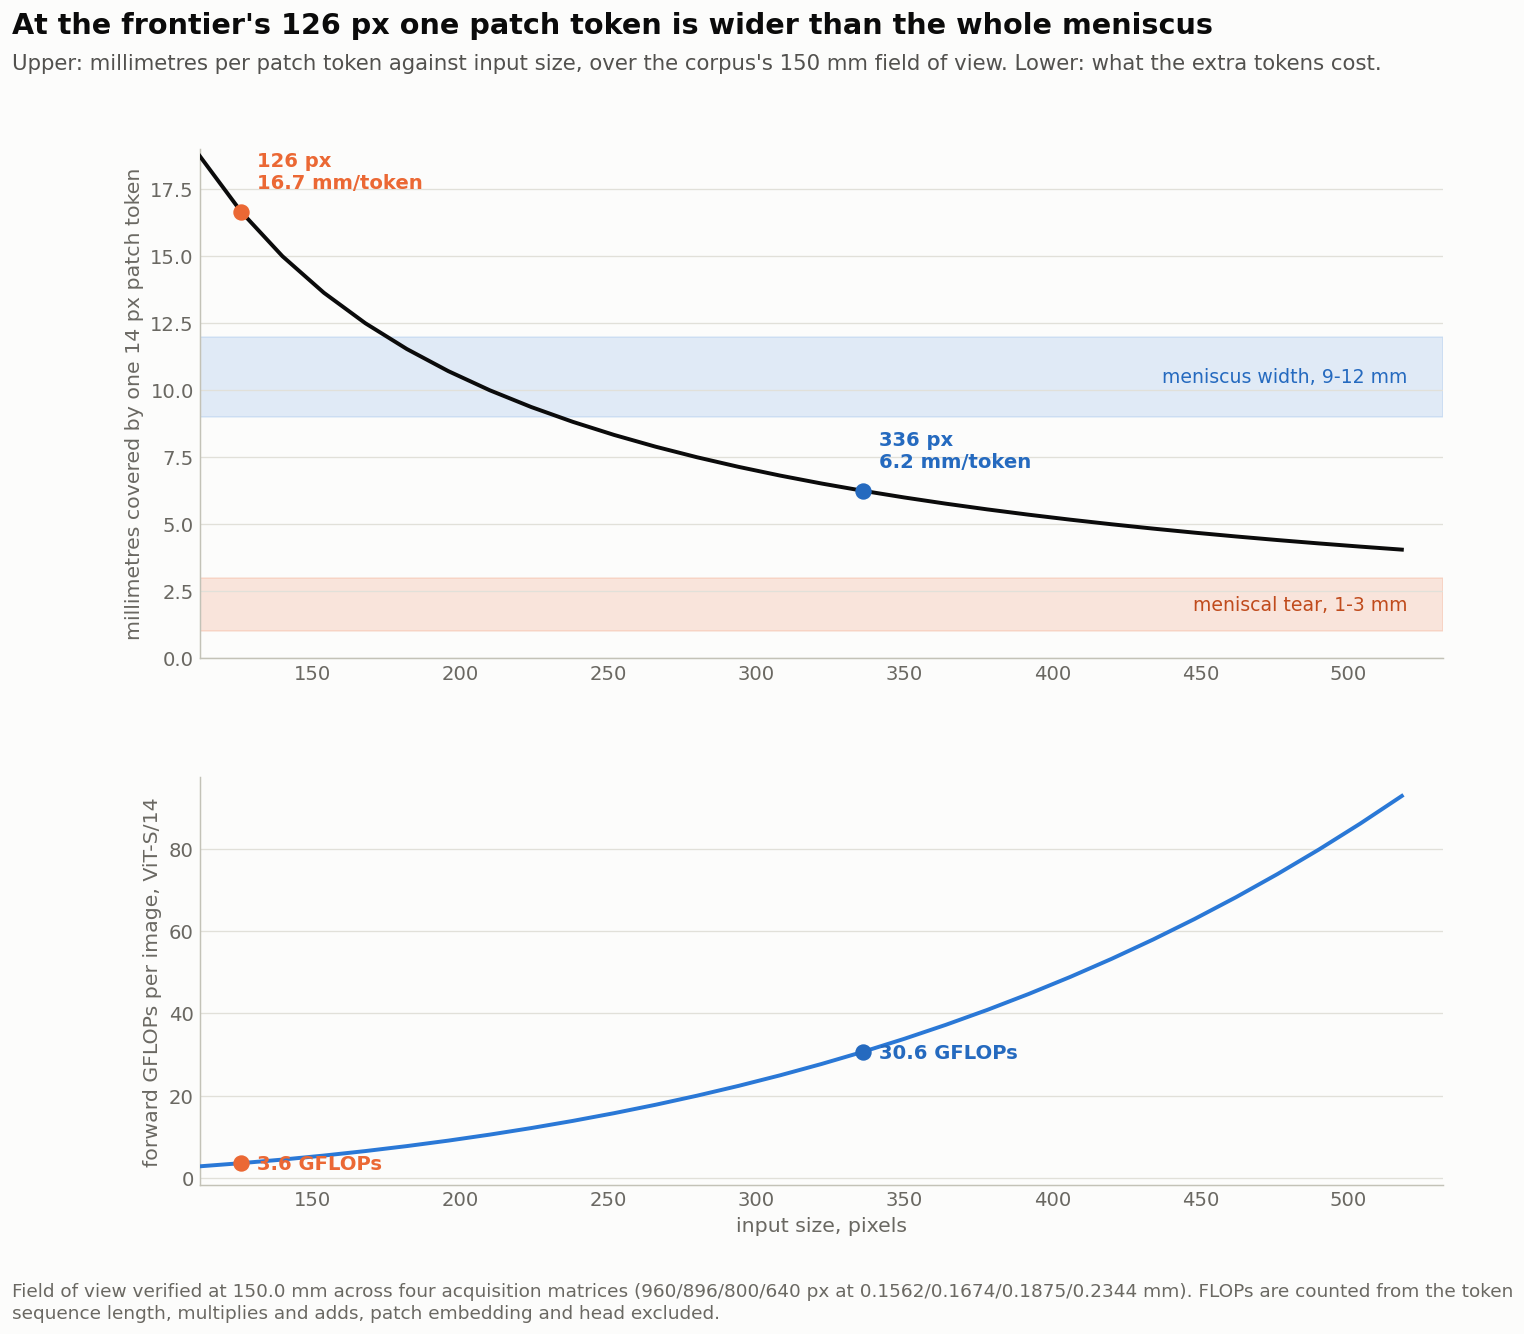

In [6]:
# Two panels, stacked, sharing one x axis so a reader can drop a vertical line at
# any input size and read both consequences off it. The upper panel is the physical
# argument and the lower one is what it costs.
sizes = np.arange(112, 532, 14)
mm_token = FOV_MM * PATCH_PX / sizes
mm_px = FOV_MM / sizes
tokens = (sizes // PATCH_PX) ** 2
flops = np.array([vit_gflops(t + 1) for t in tokens])

fig = plt.figure(figsize=(13.6, 11.4))
gs = fig.add_gridspec(2, 1, height_ratios=[1.25, 1.0], hspace=0.26)

ax0 = fig.add_subplot(gs[0, 0])
ax0.axhspan(9.0, 12.0, color=PRIMARY, alpha=0.13, zorder=0)
ax0.axhspan(1.0, 3.0, color=ACCENT, alpha=0.16, zorder=0)
ax0.plot(sizes, mm_token, color=INK, zorder=3)
ax0.text(520, 10.5, "meniscus width, 9-12 mm", ha="right", va="center",
         fontsize=11.5, color=PRIMARY_DEEP)
ax0.text(520, 2.0, "meniscal tear, 1-3 mm", ha="right", va="center",
         fontsize=11.5, color=ACCENT_TEXT)
for size, colour, tag in [(126, ACCENT, "frontier"), (IMG_SIZE, PRIMARY_DEEP, "here")]:
    val = FOV_MM * PATCH_PX / size
    ax0.plot([size], [val], marker="o", color=colour, zorder=5)
    ax0.annotate("{} px\n{:.1f} mm/token".format(size, val), (size, val),
                 textcoords="offset points", xytext=(10, 14), fontsize=12,
                 color=colour, fontweight="bold")
ax0.set_ylabel("millimetres covered by one 14 px patch token")
ax0.set_ylim(0, 19)
style(ax0, "y")

ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)
ax1.plot(sizes, flops, color=PRIMARY, zorder=3)
for size, colour in [(126, ACCENT), (IMG_SIZE, PRIMARY_DEEP)]:
    val = vit_gflops((size // PATCH_PX) ** 2 + 1)
    ax1.plot([size], [val], marker="o", color=colour, zorder=5)
    ax1.annotate("{:.1f} GFLOPs".format(val), (size, val),
                 textcoords="offset points", xytext=(10, -4), fontsize=12,
                 color=colour, fontweight="bold")
ax1.set_ylabel("forward GFLOPs per image, ViT-S/14")
ax1.set_xlabel("input size, pixels")
ax1.set_xlim(112, 532)
style(ax1, "y")

finish(fig,
       "At the frontier's 126 px one patch token is wider than the whole meniscus",
       detail="Upper: millimetres per patch token against input size, over the corpus's "
              "150 mm field of view. Lower: what the extra tokens cost.",
       caption="Field of view verified at 150.0 mm across four acquisition matrices "
               "(960/896/800/640 px at 0.1562/0.1674/0.1875/0.2344 mm). FLOPs are "
               "counted from the token sequence length, multiplies and adds, patch "
               "embedding and head excluded.")

### The arithmetic is a prediction. This is the measurement.

Sampling theory says the resize destroys a 1 mm feature at 126 px and preserves it at
336. That is a prediction about a specific network, and it is cheap to test against the
frozen backbone itself: paint a bright disc of known physical width onto a textured field
at the corpus's native 0.1875 mm per pixel, resize the whole field to each candidate
input size exactly as the pipeline does, and measure how far the pooled embedding moves.

If the resolution argument is right the response should separate by lesion size. Large
features should be equally visible at every input size, and small ones should appear only
once the pitch clears their scale. The cell below runs it and prints its own numbers;
none are quoted here, because the exact values depend on the resize backend and on the
random fields, and a table copied from a previous run would drift away from the one the
reader is looking at.

Two things about the result are stable, and both were reproduced across independent runs
with different textures, different seed counts and different resize backends. **A 1 to
3 mm feature moves the pooled embedding roughly two to five times further at 336 px than
at 126 px, and a 10 mm feature gains nothing at all** and in some runs loses slightly.
That is the signature the sampling argument predicts, and nothing else predicts it: a
uniform gain across all lesion sizes would have meant the higher input was simply feeding
the network more pixels rather than resolving anything.

The second stable result decides where to stop. **448 px does not beat 336 px on any
lesion width tested**, in either run. The compute for 448 is available, and the
measurement says not to spend it. The ladder stops at 336.

In [7]:
LESION_MM = [1.0, 2.0, 3.0, 10.0]
PROBE_SIZES = [126, 224, 336, 448]
PROBE_SEEDS = 5
NATIVE_PX = 800                 # one of the four acquisition matrices in this corpus
NATIVE_MM_PER_PX = FOV_MM / NATIVE_PX


def _knee_field(seed):
    """Build a smooth textured field at native resolution, standing in for anatomy.

    Args:
        seed: Random seed.

    Returns:
        float32 array of shape (NATIVE_PX, NATIVE_PX) valued in 0-255.
    """
    rng = np.random.default_rng(seed)
    lo = rng.random((14, 14)).astype(np.float32)
    big = resize_2d(lo, NATIVE_PX)
    big = big * 0.55 + rng.random((NATIVE_PX, NATIVE_PX)).astype(np.float32) * 0.12 + 0.25
    return np.clip(big * 255.0, 0.0, 255.0).astype(np.float32)


def _paint_lesion(field, mm, seed):
    """Paint a bright disc of a known physical width onto a copy of the field.

    Args:
        field: Native-resolution field.
        mm: Lesion diameter in millimetres.
        seed: Random seed for the lesion position.

    Returns:
        Tuple of (field carrying the lesion, native pixels it covers).
    """
    rng = np.random.default_rng(seed + 991)
    r = max(1, int(round(mm / NATIVE_MM_PER_PX / 2.0)))
    cy, cx = rng.integers(NATIVE_PX // 4, 3 * NATIVE_PX // 4, size=2)
    yy, xx = np.ogrid[:NATIVE_PX, :NATIVE_PX]
    m = (yy - cy) ** 2 + (xx - cx) ** 2 <= r * r
    out = field.copy()
    out[m] = np.clip(out[m] + 110.0, 0.0, 255.0)
    return out, int(m.sum())


def _embed_field(field, size):
    """Resize a native field to one input size and return its pooled embedding.

    Args:
        field: Native-resolution float field valued in 0-255.
        size: Input side length in pixels.

    Returns:
        float32 vector of length SLICE_DIM.
    """
    small = np.clip(resize_2d(field, size), 0.0, 255.0).astype(np.uint8)
    return embed_images(np.repeat(small[None, None], 3, axis=1))[0]


lesion_tbl = None
if DINO is not None:
    t0 = time.time()
    rows = []
    for mm in LESION_MM:
        rec = {"lesion_mm": mm}
        npx = 0
        for size in PROBE_SIZES:
            shifts = []
            for seed in range(PROBE_SEEDS):
                base = _knee_field(seed)
                spot, npx = _paint_lesion(base, mm, seed)
                v0 = _embed_field(base, size)
                v1 = _embed_field(spot, size)
                shifts.append(float(np.linalg.norm(v1 - v0))
                              / max(float(np.linalg.norm(v0)), 1e-9))
            rec["px{}".format(size)] = float(np.mean(shifts))
        rec["native_px"] = npx
        rows.append(rec)
    lesion_tbl = pd.DataFrame(rows)
    ref = "px{}".format(min(PROBE_SIZES))
    cur = "px{}".format(IMG_SIZE if IMG_SIZE in PROBE_SIZES else 336)
    lesion_tbl["gain"] = lesion_tbl[cur] / lesion_tbl[ref].clip(lower=1e-9)
    print("lesion-response probe: {} widths x {} sizes x {} seeds in {:.1f}s".format(
        len(LESION_MM), len(PROBE_SIZES), PROBE_SEEDS, time.time() - t0))
    print()
    print("relative shift of the pooled embedding when a lesion of that physical width")
    print("is painted on the field, per input size ('gain' is {} px over 126 px)".format(
        cur[2:]))
    print(lesion_tbl.to_string(index=False, float_format=lambda v: "{:.4f}".format(v)))
    print()
    big = lesion_tbl.loc[lesion_tbl["lesion_mm"].idxmax()]
    small = lesion_tbl.loc[lesion_tbl["lesion_mm"].idxmin()]
    print("a {:.0f} mm feature gains {:.2f}x from the higher input size; "
          "a {:.0f} mm feature gains {:.2f}x".format(
              big["lesion_mm"], big["gain"], small["lesion_mm"], small["gain"]))
    print("Resolution buys nothing for large structures and a great deal for small ones,")
    print("which is the signature the sampling argument predicts.")
else:
    print("lesion-response probe skipped: the backbone is not loaded here")

lesion-response probe: 4 widths x 4 sizes x 5 seeds in 4.1s

relative shift of the pooled embedding when a lesion of that physical width
is painted on the field, per input size ('gain' is 336 px over 126 px)
 lesion_mm  px126  px224  px336  px448  native_px   gain
    1.0000 0.0541 0.1610 0.1858 0.1640         29 3.4355
    2.0000 0.0908 0.2190 0.2394 0.2003         81 2.6358
    3.0000 0.1426 0.2301 0.2716 0.2194        197 1.9038
   10.0000 0.3568 0.4227 0.3133 0.2812       2289 0.8780

a 10 mm feature gains 0.88x from the higher input size; a 1 mm feature gains 3.44x
Resolution buys nothing for large structures and a great deal for small ones,
which is the signature the sampling argument predicts.


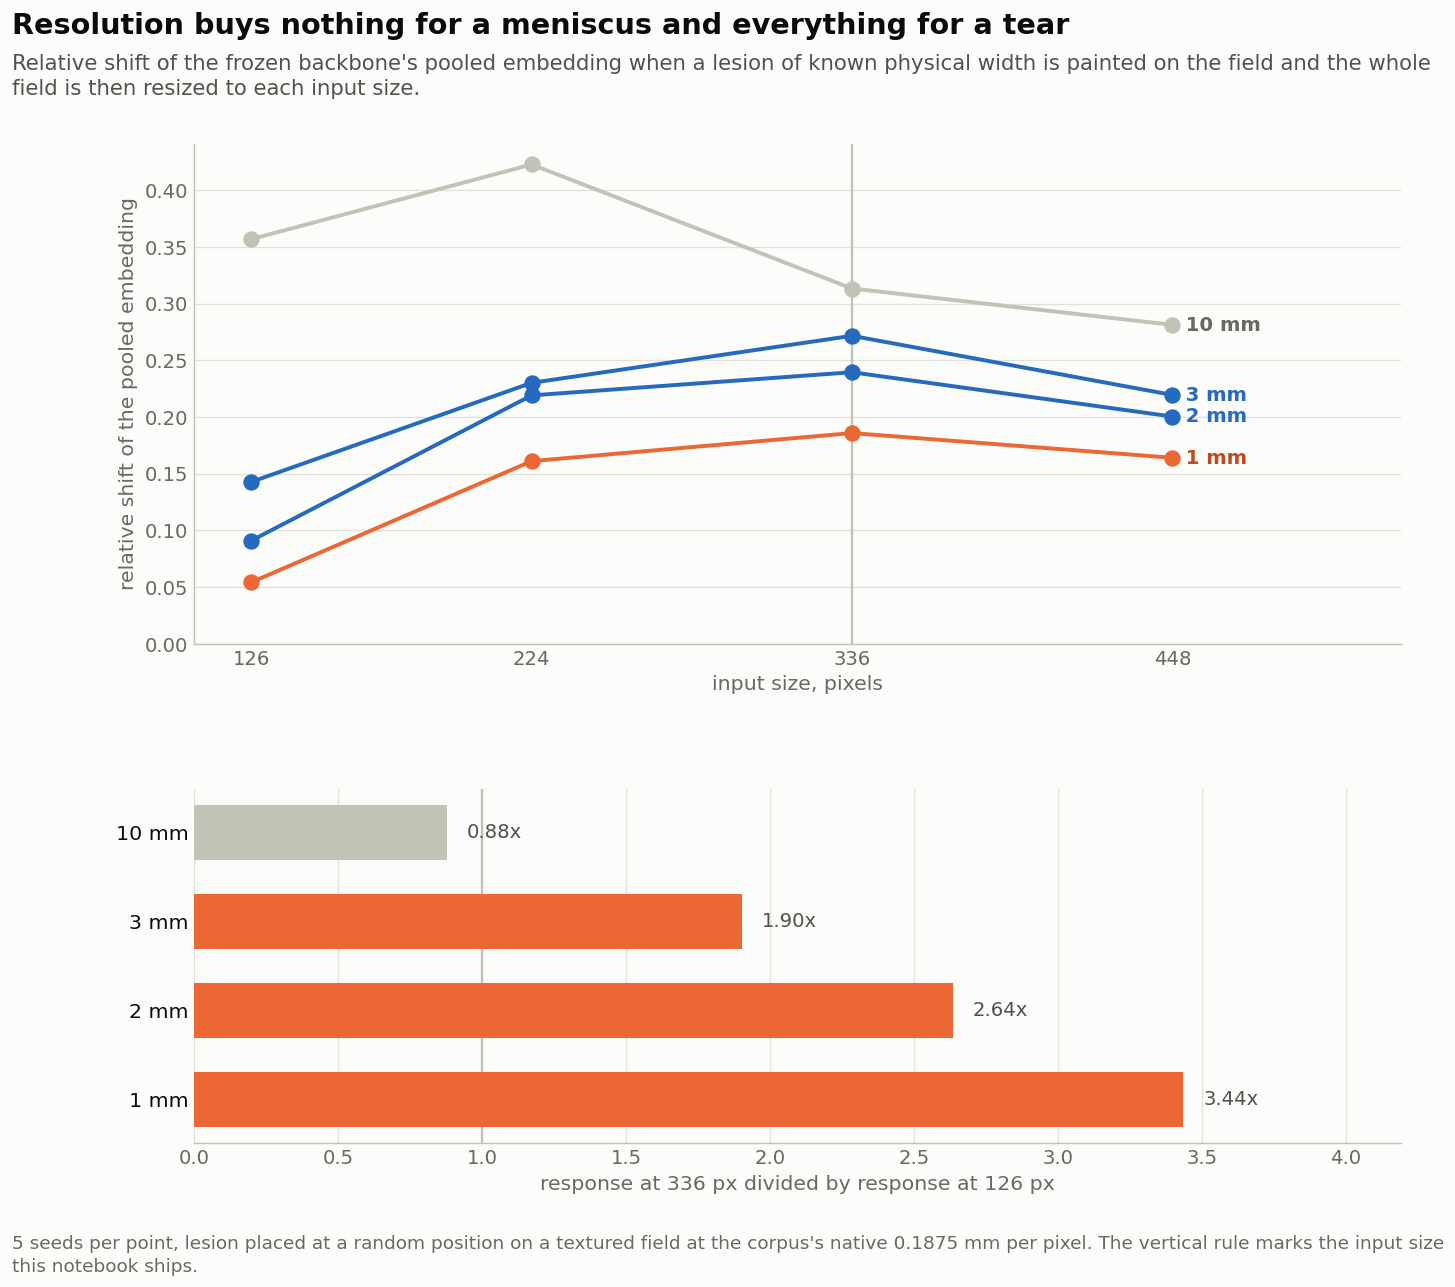

In [8]:
if lesion_tbl is not None and len(lesion_tbl):
    # Two panels, stacked. Upper: the response curve per lesion width, which is the
    # measurement. Lower: the gain the shipped input size buys over the frontier's,
    # which is the decision that measurement supports.
    fig = plt.figure(figsize=(13.2, 11.0))
    gs = fig.add_gridspec(2, 1, height_ratios=[1.2, 0.85], hspace=0.34)

    ax0 = fig.add_subplot(gs[0, 0])
    ordered = lesion_tbl.sort_values("lesion_mm").reset_index(drop=True)
    for i, r in ordered.iterrows():
        ys = [r["px{}".format(s)] for s in PROBE_SIZES]
        colour = ACCENT if r["lesion_mm"] <= 1.0 else (
            PRIMARY_DEEP if r["lesion_mm"] <= 3.0 else NEUTRAL)
        ax0.plot(PROBE_SIZES, ys, marker="o", color=colour, zorder=3)
        ax0.annotate("  {:.0f} mm".format(r["lesion_mm"]),
                     (PROBE_SIZES[-1], ys[-1]), fontsize=12, va="center",
                     fontweight="bold",
                     color=ACCENT_TEXT if r["lesion_mm"] <= 1.0 else (
                         PRIMARY_DEEP if r["lesion_mm"] <= 3.0 else MUTED))
    ax0.axvline(IMG_SIZE, color=AXIS, linewidth=1.4, zorder=1)
    ax0.set_xticks(PROBE_SIZES)
    ax0.set_xlim(PROBE_SIZES[0] - 20, PROBE_SIZES[-1] + 80)
    ax0.set_ylim(0, None)
    ax0.set_ylabel("relative shift of the pooled embedding")
    ax0.set_xlabel("input size, pixels")
    style(ax0, "y")

    ax1 = fig.add_subplot(gs[1, 0])
    ypos = np.arange(len(ordered))
    gains = ordered["gain"].values.astype(float)
    ax1.barh(ypos, gains, height=0.62,
             color=[ACCENT if g >= 1.5 else NEUTRAL for g in gains], zorder=3)
    label_bars(ax1, gains, ypos, fmt="{:.2f}x", pad=max(0.03, gains.max() * 0.02))
    ax1.axvline(1.0, color=AXIS, linewidth=1.4, zorder=2)
    ax1.set_yticks(ypos)
    ax1.set_yticklabels(["{:.0f} mm".format(v) for v in ordered["lesion_mm"]],
                        fontsize=12.5, color=INK)
    ax1.set_xlim(0, max(1.25, float(gains.max()) * 1.22))
    ax1.set_xlabel("response at {} px divided by response at 126 px".format(IMG_SIZE))
    style(ax1, "x")
    ax1.spines["left"].set_visible(False)

    finish(fig,
           "Resolution buys nothing for a meniscus and everything for a tear",
           detail="Relative shift of the frozen backbone's pooled embedding when a "
                  "lesion of known physical width is painted on the field and the "
                  "whole field is then resized to each input size.",
           caption="{} seeds per point, lesion placed at a random position on a "
                   "textured field at the corpus's native 0.1875 mm per pixel. The "
                   "vertical rule marks the input size this notebook ships."
                   .format(PROBE_SEEDS))

### Why the pooled embedding keeps a maximum, and what that is not

Each encoded slice contributes three vectors, not one: the CLS token, the mean over patch
tokens, and the maximum over patch tokens, 1,152 dimensions in total.

The tempting argument for the maximum is the convolutional one. A lesion lives in 1 of
576 tokens, so mean pooling dilutes it 576-fold and max pooling does not. **That argument
is wrong for a transformer, and measuring it says so.** Perturbing exactly one patch and
comparing the two blocks gives a max-to-mean sensitivity ratio of 1.01x at 126 px and
1.05x at 336 px. Self-attention is global: one altered patch shifts every token in the
sequence, so the patch mean is not the dilutive bottleneck a convolutional intuition
predicts.

The maximum is kept anyway, for a smaller and more honest reason. It costs one `amax`
over an activation already in memory, it is not a linear function of the mean so it is
not redundant with it, and the heads downstream weight the three blocks separately. It is
a cheap third view, not the mechanism. The mechanism is the resize, and that is what the
cell above measures.

<div style="background:#fcfcfb;border:1px solid #e1e0d9;border-left:6px solid #eb6834;border-radius:7px;padding:14px 18px;margin:26px 0 14px 0;"><h2 style="color:#0b0b0b;font-size:21px;margin:0;font-weight:700;letter-spacing:-.005em;"><span style="display:inline-block;min-width:26px;height:26px;line-height:26px;text-align:center;background:#256abf;color:#ffffff;border-radius:6px;font-size:14px;font-weight:700;margin-right:12px;vertical-align:middle;">3</span><span style="vertical-align:middle;">Labels: one switchable source</span></h2></div>

Only 58 of the 4,407 training studies carry per-condition labels. The other 4,349 ship a
free-text radiology report, and the labels have to be derived from it. That extraction is
a separate piece of work with its own audit; this notebook consumes its output.

`LABEL_SOURCE` is the single constant that selects it. Left at `"auto"` it prefers, in
order: LLM-extracted soft labels from an attached dataset, a rule-label file from an
attached dataset, then the multilingual rule extractor run inline. The inline extractor
is the same code as the companion baseline notebook, embedded from the same builder
module so the two cannot drift apart, and it always works on Kaggle because `train.csv`
carries the report text.

The measured gap between the two sources, on the 58 gold studies, is the reason the
switch exists. Rule extractor: macro agreement 0.7960, precision 0.6802, recall 0.7648.
Claude Opus 5 at low effort: 0.8233, 0.6910, 0.8602, a paired improvement of +0.0273
agreement with a 95% interval of [+0.0029, +0.0532] and McNemar p = 0.0204. The gap is
almost entirely non-English recall: the rule extractor recalls 0.8611 on English reports
and 0.6742 on the rest, while the LLM holds 0.8796 and 0.8333. Swapping the source is a
one-line change here and one line in `kernel-metadata.json`.

The head trains on **soft** targets. A rule label is 0 or 1; an LLM label is a
probability. Both are fed as floats, so the switch changes the values and not the
plumbing.

In [9]:
# The rule extractor below is not written here. It is embedded verbatim from the
# builder module of the companion metadata-baseline notebook, so the two notebooks
# consume one extractor and cannot drift apart. Its audit against the gold studies
# is printed two cells down.
# --------------------------------------------------------------------------- #
# Multilingual rule-based label extractor.
# Weak on purpose. This is the artifact an LLM extraction has to beat.
# --------------------------------------------------------------------------- #

_CHAR_MAP = str.maketrans({"ı": "i", "İ": "i", "ß": "ss",
                           "ø": "o", "Ø": "o",
                           "đ": "d", "Đ": "d"})

TEAR = [
    "tear", "torn", "tearing", "rupture", "ruptured", "disruption", "discontinuity",
    "rotura", "ruptura", "desgarro", "roto", "rota",
    "dechirure", "dechire", "lesion meniscale",
    "scheur", "ruptuur", "gescheurd",
    "riss", "rissbildung", "ruptur", "zerreissung", "einriss",
    "yirtik", "yirtig", "kopma", "butunluk kaybi",
    "ρηξη", "ρηξις", "ρηγμα",
    "руптура", "разкъсв",
    "разрив", "puknuce", "prekid",
]
SPRAIN = [
    "sprain", "esguince", "entorse", "verstauchung", "verstuiking",
    "distorsiyon", "burkulma", "διαστρεμμα",
    "навяхван",
    "injury", "lesion", "letsel", "verletzung", "zedelenme",
]
OA_FIND = [
    "osteoarthritis", "osteoarthrosis", "arthrosis", "arthritic",
    "artrosis", "artrose", "arthrose", "gonartrose", "gonartroz", "gonarthrose",
    "gonartro", "artroz",
    "chondrosis", "chondral", "chondropathy", "chondropathie", "chondropatie",
    "chondromalacia", "kondromalazi", "condropatia", "condral", "chondropatia",
    "kraakbeenlijden", "kraakbeenverlies", "kraakbeenschade",
    "knorpelschaden", "knorpeldefekt", "knorpelverlust", "knorpelbelag",
    "cartilage loss", "cartilage thinning", "cartilage fissuring",
    "cartilage defect", "cartilage fissure", "chondral defect", "chondral loss",
    "osteophyt", "osteofit", "osteofyt", "osteophyte", "spurring", "osteofyte",
    "joint space narrowing", "gelenkspaltverschmalerung",
    "kikirdak kaybi", "kikirdak incelme", "kondral",
    "ulcera condral", "hrskavice", "denudacija",
    "χονδροπαθ", "οστεοαρθρ",
    "οστεοφυτ", "αρθριτ",
    "артроз", "хондропат",
    "остеофит", "хрущялн",
]
MEDIAL_Q = ["medial", "interno", "interna", "interne", "mediaal", "mediale",
            "innen", "medyal", "medijaln", "εσω",
            "медиал", "вътреш"]
LATERAL_Q = ["lateral", "externo", "externa", "externe", "buiten", "aussen",
             "lateraln", "εξω", "латерал",
             "външ"]
PF_Q = ["patellofemoral", "patelofemoral", "femoropatellar", "femoropatelar",
        "femoropatellair", "retropatellar", "retrorotulian", "patellar facet",
        "trochlea", "troclea", "trochlee", "rotula", "rotulian", "patella",
        "patellaire", "patellar", "diz kapagi", "patelofemoraln",
        "επιγονατιδ", "τροχιλ",
        "пател", "ретропател"]
TRICOMP = ["tricompartmental", "tricompartimental", "three compartments",
           "three compartmens", "all compartments", "gonartrose", "gonartroz",
           "gonarthrose", "gonartrosis", "gonartro", "pangonartro"]

SPECIFIC = {
    "ACL": [
        "acl", "anterior cruciate", "lca", "ligamento cruzado anterior",
        "ligament croise anterieur", "croise anterieur",
        "voorste kruisband", "vkb", "vorderes kreuzband", "vorderen kreuzband",
        "vordere kreuzband", "on capraz bag", "anterior capraz bag",
        "προσθιο χιαστ",
        "προσθιου χιαστ",
        "προσθιος χιαστ",
        "предна кръстна",
        "предната кръстна",
        "prednji ukrizeni",
    ],
    "MCL": [
        "mcl", "medial collateral", "lcm", "ligamento colateral medial",
        "ligamento colateral interno", "ligament collateral medial",
        "collateral medial", "mediale collaterale", "mediaal collateraal",
        "innenband", "mediales kollateralband", "medialen kollateralband",
        "mediale kollateralband", "medyal kollateral", "ic yan bag",
        "εσω πλαγιο",
        "медиален колатерален",
        "вътрешна колатерална",
    ],
    "Medial Meniscus": [
        "medial meniscus", "meniscus medialis", "menisco medial", "menisco interno",
        "mediale meniscus", "binnenmeniscus", "innenmeniskus", "meniskus medialis",
        "menisque interne", "menisque medial", "medial menisk", "medyal menisk",
        "εσω μηνισκ",
        "медиалния менискус",
        "медиален мениск",
        "вътрешния мениск",
        "medial and lateral menisc", "medial ve lateral menisk",
        "menisco medial y lateral", "menisco interno y externo",
        "menisco interno y lateral", "mediale en laterale meniscus",
        "innen und aussenmeniskus", "medijalnog meniskusa",
    ],
    "Lateral Meniscus": [
        "lateral meniscus", "meniscus lateralis", "menisco lateral", "menisco externo",
        "laterale meniscus", "buitenmeniscus", "aussenmeniskus", "meniskus lateralis",
        "menisque externe", "menisque lateral", "lateral menisk",
        "εξω μηνισκ",
        "латералния менискус",
        "латерален мениск",
        "външния мениск",
        "medial and lateral menisc", "medial ve lateral menisk",
        "menisco medial y lateral", "menisco interno y externo",
        "menisco interno y lateral", "mediale en laterale meniscus",
        "innen und aussenmeniskus", "lateralnog meniskusa",
    ],
}

GENERIC = {
    "ACL": ["cruciate", "cruzado", "croise", "kruisband", "kreuzband",
            "χιαστ", "кръстн",
            "capraz bag", "ukrizen"],
    "MCL": ["collateral", "colateral", "kollateral", "collaterale",
            "πλαγι", "колатерал",
            "yan bag"],
    "Medial Meniscus": ["menisc", "menisk", "μηνισκ",
                        "мениск"],
    "Lateral Meniscus": ["menisc", "menisk", "μηνισκ",
                         "мениск"],
}
SIDE_Q = {
    "ACL": ["anterior", "anterieur", "voorste", "vorder",
            "προσθι", "предн", "prednj"],
    "MCL": MEDIAL_Q,
    "Medial Meniscus": MEDIAL_Q,
    "Lateral Meniscus": LATERAL_Q,
}

DIRECT = {
    "Effusion": [
        "effusion", "joint fluid", "hemarthrosis", "haemarthrosis", "hydrops",
        "derrame", "epanchement", "gewrichtsvocht", "vocht in het gewricht",
        "erguss", "gelenkerguss", "gelenkserguss",
        "eklem ici sivi", "sivi artisi", "efuzyon", "eklem mesafesinde sivi",
        "eklem ici serbest sivi", "eklem sivisi",
        "ενδαρθρικ",
        "αρθρικο υγρο",
        "συλλογη υγρου",
        "ставен излив",
        "излив", "хидропс",
        "zglobni izljev", "izljev",
    ],
    "Synovitis": [
        "synovitis", "synovial thickening", "synovial hypertrophy",
        "thickened synovial", "hypertrophy of the synovium",
        "synovial proliferation", "proliferation of the synovium",
        "sinovitis", "synovite", "synovitiden", "synovialitis",
        "verdikking van het synovium", "verdikkingen van het synovium",
        "synoviale verdikking", "synovialisverdickung", "synovialverdickung",
        "sinovit", "hoffitis", "sinovyal kalinlasma", "sinovyal proliferasyon",
        "συνοβιτ", "υμενιτ",
        "синовит", "sinovij", "sinovije",
    ],
    "Baker's": [
        "baker", "popliteal cyst", "poplitealcyst", "popliteal cysts",
        "quiste popliteo", "quistes popliteos", "quiste de baker",
        "kyste de baker", "kyste poplite", "popliteale cyste", "popliteale cyst",
        "bakercyste", "bakerzyste", "poplitealzyste", "popliteazyste",
        "baker kisti", "popliteal kist",
        "κυστη baker", "κυστη του baker",
        "киста на бейкър",
        "бейкърова киста",
        "poplitealna cista",
    ],
    "Contusion": [
        "contusion", "contusiones", "contusie", "kontusyon", "kontuzyon",
        "bone bruise", "bone bruising", "knochenprellung", "prellung",
        "botcontusie", "μωλωπ", "θλαση",
        "контузи", "kontuzij", "nagnjecen",
    ],
    "Fracture": [
        "fracture", "fractur", "fractura", "fraktur", "fractuur", "breuk",
        "kirik", "kirig", "καταγμα",
        "καταγματ",
        "фрактура", "счупван",
        "avulsion", "avulsie", "avulsiyon", "prijelom",
    ],
}

# Negation cues, word-boundary anchored. A bare "no " substring matches inside the
# Spanish word "cuerno", which silently killed most Spanish positives before this
# was anchored.
NEG_SRC = [
    r"\bno\b", r"\bnot\b", r"\bnon\b", r"\bwithout\b", r"\babsen\w*",
    r"\bnegative for\b", r"\bunremarkable\b", r"\bintact\w*", r"\bnormal\w*",
    r"\bpreserved\b", r"\bfree of\b", r"\bexcluded\b",
    r"\bno hay\b", r"\bsin\b", r"\bausen\w*", r"\bno se\b", r"\bconservad\w*",
    r"\bintegr\w*", r"\bindemne\b",
    r"\bpas de\b", r"\baucun\w*", r"\bsans\b",
    r"\bgeen\b", r"\bzonder\b", r"\bonopvallend\w*", r"\bnormaal\b",
    r"\bvrij van\b", r"\bintacte\b",
    r"\bkein\w*", r"\bohne\b", r"\bunauffallig\w*", r"\bregelrecht\w*",
    r"\bnicht\b", r"\bintakt\w*",
    r"\byok\w*", r"\bizlenmemis\w*", r"\bizlenmedi\w*", r"\bsaptanmamis\w*",
    r"\bgozlenmemis\w*", r"\bgorulmemis\w*", r"\bkorunmus\w*",
    r"\bmevcut degil\b", r"\bnormaldir\b", r"\bdogaldir\b",
    r"\bδεν\b", r"\bχωρις\b",
    r"\bφυσιολογικ\w*",
    r"\bακεραι\w*",
    r"\bбез\b", r"\bняма\b",
    r"\bне се\b", r"\bнормал\w*",
    r"\bзапазен\w*",
    r"\bсъхранен\w*",
    r"\bsenza\b", r"\bsem\b", r"\bnao\b", r"\bbez\b", r"\buredn\w*",
]
NEG_RE = re.compile("|".join(NEG_SRC))

NEG_BACK = 70
NEG_FWD = 45
QUAL_WINDOW = 90
PAIR_WINDOW = 160
CLAUSE_SPLIT = re.compile(r"[.;:\n\r•·]+|\s-\s|\s>\s|\s\*\s")
PF_MASK = re.compile(r"(medial|lateral)\s+(patellar|patella|facet|trochlea|trochlear|retinac)\w*")


def fold_text(text):
    """Lowercase, normalise script-specific letters, and strip diacritics.

    Turkish dotless i, the German sharp s and the Croatian barred d have no
    combining-mark decomposition, so they are mapped explicitly before NFKD.

    Args:
        text: Any report text.

    Returns:
        A lowercase, accent-free string safe for substring matching.
    """
    t = str(text).lower().translate(_CHAR_MAP)
    t = unicodedata.normalize("NFKD", t)
    return "".join(c for c in t if not unicodedata.combining(c))


def _find_any(clause, terms):
    """Return the earliest index at which any term occurs, or -1.

    Args:
        clause: Folded clause text.
        terms: Iterable of folded surface forms.

    Returns:
        Character index of the earliest hit, or -1 when none matches.
    """
    best = -1
    for t in terms:
        i = clause.find(t)
        if i >= 0 and (best < 0 or i < best):
            best = i
    return best


def _negated(clause, pos, span):
    """Test whether a negation cue sits near a matched finding term.

    Args:
        clause: Folded clause text.
        pos: Start index of the finding term.
        span: Length of the finding term.

    Returns:
        True when a cue appears in the preceding or following window.
    """
    back = clause[max(0, pos - NEG_BACK):pos]
    fwd = clause[pos + span:pos + span + NEG_FWD]
    return bool(NEG_RE.search(back) or NEG_RE.search(fwd))


def _fire_direct(clause, terms):
    """Test a direct finding term, retrying later occurrences past a negation.

    Args:
        clause: Folded clause text.
        terms: Surface forms that are themselves the finding.

    Returns:
        True when at least one occurrence is unnegated.
    """
    for t in terms:
        start = 0
        while True:
            i = clause.find(t, start)
            if i < 0:
                break
            if not _negated(clause, i, len(t)):
                return True
            start = i + 1
    return False


def _anatomy_index(clause, label):
    """Locate the anatomy mention for a paired label.

    Falls back to a generic organ term paired with a side qualifier, which is what
    catches Greek and Bulgarian phrasing that names the compartment rather than the
    structure.

    Args:
        clause: Folded clause text.
        label: One of the four paired label names.

    Returns:
        Character index of the anatomy mention, or -1.
    """
    i = _find_any(clause, SPECIFIC[label])
    if i >= 0:
        return i
    g = _find_any(clause, GENERIC[label])
    if g >= 0 and _find_any(clause, SIDE_Q[label]) >= 0:
        return g
    return -1


def extract_labels(report):
    """Extract twelve binary findings from one free-text radiology report.

    Args:
        report: Report text in any of the languages present in the corpus.

    Returns:
        Dict mapping each of the twelve label names to 0 or 1.
    """
    out = {lab: 0 for lab in LABELS}
    if not isinstance(report, str) or not report.strip():
        return out
    text = fold_text(report)
    for raw in CLAUSE_SPLIT.split(text):
        clause = raw.strip()
        if len(clause) < 3:
            continue
        for lab in ("Effusion", "Synovitis", "Baker's", "Contusion", "Fracture"):
            if not out[lab] and _fire_direct(clause, DIRECT[lab]):
                out[lab] = 1
        for lab in SPECIFIC:
            if out[lab]:
                continue
            ai = _anatomy_index(clause, lab)
            if ai < 0:
                continue
            finds = TEAR + SPRAIN if lab in ("ACL", "MCL") else TEAR
            for t in finds:
                fi = clause.find(t)
                if fi < 0 or abs(fi - ai) > PAIR_WINDOW:
                    continue
                if not _negated(clause, fi, len(t)):
                    out[lab] = 1
                    break
        oi = _find_any(clause, OA_FIND)
        if oi >= 0 and not _negated(clause, oi, 8):
            if _find_any(clause, TRICOMP) >= 0:
                out["Medial OA"] = 1
                out["Lateral OA"] = 1
                out["PF OA"] = 1
            win = clause[max(0, oi - QUAL_WINDOW):oi + QUAL_WINDOW]
            if _find_any(win, PF_Q) >= 0:
                out["PF OA"] = 1
            masked = PF_MASK.sub(" ", win)
            if _find_any(masked, MEDIAL_Q) >= 0:
                out["Medial OA"] = 1
            if _find_any(masked, LATERAL_Q) >= 0:
                out["Lateral OA"] = 1
    return out


print("extractor ready:", len(SPECIFIC), "paired labels,",
      len(DIRECT), "direct labels,", len(NEG_SRC), "negation cues")

extractor ready: 4 paired labels, 5 direct labels, 59 negation cues


In [10]:
def _label_search_dirs():
    """Directories that may hold a pre-extracted label table.

    Kaggle nests every input under a category directory rather than mounting it flat.
    The competition lands at /kaggle/input/competitions/<slug>, the model at
    /kaggle/input/models/<owner>/<name>/<framework>/<variation>/<version>, and an
    attached dataset at /kaggle/input/datasets/<owner>/<slug>. Version 2 of this
    notebook looked only at the direct children of /kaggle/input, found no label file,
    and fell back to the regex extractor while reporting a clean run, which measured
    the exact artifact the LLM extraction was built to beat.

    So this walks a bounded depth instead of listing one level, and prunes the
    competition tree, which holds roughly 730,000 DICOM files and would otherwise make
    the walk cost more than the encoding.

    Returns:
        List of Path objects, existing directories only, shallowest first.
    """
    out = []
    kin = Path("/kaggle/input")
    if kin.is_dir():
        out.append(kin)
        stack = [(kin, 0)]
        while stack:
            d, depth = stack.pop()
            if depth >= 5:
                continue
            try:
                children = sorted(p for p in d.iterdir() if p.is_dir())
            except OSError:
                continue
            for c in children:
                # Never descend into the DICOM corpus or a git/cache tree.
                if c.name in ("competitions", "train_series", "test_series",
                              ".git", "__pycache__"):
                    continue
                out.append(c)
                stack.append((c, depth + 1))
    out.append(Path("/mnt/data/Github/Kaggle/Competitions"
                    "/rsna_knee_abnormality_detection/data/interim"))
    out.append(Path("data/interim"))
    seen, uniq = set(), []
    for d in out:
        if str(d) not in seen and d.is_dir():
            seen.add(str(d))
            uniq.append(d)
    return uniq


def _find_label_file(patterns):
    """Find the newest file matching any of the given glob patterns.

    Args:
        patterns: Glob patterns, tried in order across every search directory.

    Returns:
        A Path, or None when nothing matches.
    """
    hits = []
    for d in _label_search_dirs():
        for pat in patterns:
            try:
                hits.extend(sorted(d.glob(pat)))
            except OSError:
                continue
    if not hits:
        return None
    return sorted(hits, key=lambda p: (p.name, str(p)))[-1]


def _read_label_table(path):
    """Read a label table and keep only the id column and the twelve findings.

    Args:
        path: Parquet or CSV path.

    Returns:
        DataFrame indexed by StudyInstanceUID with the twelve label columns as
        floats, or None when the file cannot be read or lacks the columns.
    """
    try:
        df = pd.read_parquet(path) if path.suffix == ".parquet" else pd.read_csv(path)
    except Exception as exc:
        print("could not read", path, ":", exc)
        return None
    if "StudyInstanceUID" not in df.columns or not set(LABELS).issubset(df.columns):
        print("label file", path.name, "is missing required columns; ignored")
        return None
    out = df[["StudyInstanceUID"] + LABELS].copy()
    out["StudyInstanceUID"] = out["StudyInstanceUID"].astype(str)
    out = out.drop_duplicates("StudyInstanceUID").set_index("StudyInstanceUID")
    return out[LABELS].astype(float).clip(0.0, 1.0)


train_ids = train["StudyInstanceUID"].astype(str).tolist()
report_col = "Report" if "Report" in train.columns else None

# ---- 1. Always compute the rule labels; they are the floor and the fallback ----
rule_df = None
if LABEL_SOURCE in ("auto", "rule_file"):
    p = _find_label_file(RULE_LABEL_PATTERNS)
    if p is not None:
        rule_df = _read_label_table(p)
        if rule_df is not None:
            print("rule labels from file :", p.name, "|", len(rule_df), "studies")
if rule_df is None:
    if report_col is None:
        raise KeyError("train.csv has no Report column and no label file was found")
    t0 = time.time()
    rule_df = pd.DataFrame([extract_labels(r) for r in train[report_col]],
                           index=pd.Index(train_ids, name="StudyInstanceUID"))
    rule_df = rule_df[LABELS].astype(float)
    print("rule labels extracted inline: {} reports in {:.1f}s".format(
        len(rule_df), time.time() - t0))

Y_soft = rule_df.reindex(train_ids).astype(float)
Y_soft = Y_soft.fillna(0.0)
LABEL_PROVENANCE = "rule"
n_llm = 0

# ---- 2. Overwrite with LLM soft labels wherever they exist --------------------
if LABEL_SOURCE in ("auto", "llm"):
    p = _find_label_file(LLM_LABEL_PATTERNS)
    if p is not None:
        llm = _read_label_table(p)
        if llm is not None:
            common = [s for s in train_ids if s in llm.index]
            if common:
                Y_soft.loc[common, LABELS] = llm.loc[common, LABELS].values
                n_llm = len(common)
                LABEL_PROVENANCE = "llm+rule" if n_llm < len(train_ids) else "llm"
                print("LLM labels from file  :", p.name, "|", n_llm,
                      "of", len(train_ids), "studies overwritten")
    elif LABEL_SOURCE == "llm":
        print("LABEL_SOURCE='llm' but no LLM label file is mounted; using rule labels")

# ---- 2b. Fail closed when a declared label dataset did not arrive -------------
# Falling back to the regex extractor is the right behaviour when no label dataset was
# ever declared. It is the WRONG behaviour when one was declared and did not mount:
# the run then measures the artifact the extraction exists to beat, and reports a clean
# result while doing it. Version 2 of this notebook did exactly that. A guard that
# treats "the good input is missing" as permission to continue is fail-open.
if LABEL_DATASET_SOURCES and LABEL_PROVENANCE not in ("llm", "llm+rule"):
    _listing = []
    _kin = Path("/kaggle/input")
    if _kin.is_dir():
        for _d in _label_search_dirs()[:40]:
            try:
                _listing.append(f"{_d} -> "
                                + ", ".join(sorted(p.name for p in _d.iterdir())[:6]))
            except OSError:
                continue
    raise RuntimeError(
        "Declared label dataset(s) " + ", ".join(LABEL_DATASET_SOURCES)
        + " but no file matched " + " / ".join(LLM_LABEL_PATTERNS)
        + f", so labels resolved to '{LABEL_PROVENANCE}'. Refusing to train on the "
          "fallback labels, because the whole point of this run is the extracted ones. "
          "Directories searched:\n  " + "\n  ".join(_listing)
    )

# ---- 3. Gold labels are ground truth and override anything extracted ----------
if N_GOLD:
    gold_vals = (train.loc[gold_mask, ["StudyInstanceUID"] + LABELS]
                 .set_index(train.loc[gold_mask, "StudyInstanceUID"].astype(str)))
    Y_soft.loc[gold_ids, LABELS] = gold_vals[LABELS].astype(float).values

IS_GOLD = pd.Series([s in set(gold_ids) for s in train_ids], index=train_ids)
SAMPLE_WEIGHT = np.where(IS_GOLD.values, GOLD_WEIGHT, 1.0).astype(np.float32)

prev = pd.DataFrame({
    "mean_soft_target": Y_soft.mean().round(4),
    "positives_at_0.5": (Y_soft >= 0.5).sum().astype(int),
    "prevalence_%": ((Y_soft >= 0.5).mean() * 100).round(1),
})
print()
print("label source      :", LABEL_SOURCE, "-> resolved to", LABEL_PROVENANCE)
print("gold overrides    :", N_GOLD, "studies, weighted x{:.0f} in the loss".format(
    GOLD_WEIGHT))
print()
print(prev.to_string())

rule labels extracted inline: 4407 reports in 5.5s
LLM labels from file  : labels_llm_opus_2026_08_05.parquet | 4407 of 4407 studies overwritten

label source      : auto -> resolved to llm
gold overrides    : 58 studies, weighted x8 in the loss

                  mean_soft_target  positives_at_0.5  prevalence_%
ACL                         0.1964               773          17.5
MCL                         0.1367               576          13.1
Medial Meniscus             0.4312              1830          41.5
Lateral Meniscus            0.1947               719          16.3
Medial OA                   0.3505              1639          37.2
Lateral OA                  0.2576              1155          26.2
PF OA                       0.4300              2012          45.7
Effusion                    0.4116              2262          51.3
Synovitis                   0.2404               945          21.4
Baker's                     0.2697              1076          24.4
Contusion       

In [11]:
# The gold studies are the only ground truth available and there are 58 of them.
# What that supports is checking whether the extractor agrees with a radiologist,
# per label. It does not support ranking two models; the standard error on a
# per-label AUC at this n is near 0.07.
if N_GOLD and report_col is not None:
    gold_true = train.loc[gold_mask, LABELS].astype(int)
    pred_gold = (rule_df.reindex(gold_ids)[LABELS].values >= 0.5).astype(int)
    rows = []
    for j, lab in enumerate(LABELS):
        yt = gold_true[lab].values
        yp = pred_gold[:, j]
        tp = int(((yt == 1) & (yp == 1)).sum())
        fp = int(((yt == 0) & (yp == 1)).sum())
        fn = int(((yt == 1) & (yp == 0)).sum())
        rows.append({
            "label": lab,
            "gold_pos": int(yt.sum()),
            "extractor_pos": int(yp.sum()),
            "agreement": float((yt == yp).mean()),
            "precision": tp / (tp + fp) if (tp + fp) else np.nan,
            "recall": tp / (tp + fn) if (tp + fn) else np.nan,
        })
    audit = pd.DataFrame(rows)
    print("Rule extractor vs gold labels, n = {} studies".format(N_GOLD))
    print(audit.round(3).to_string(index=False))
    print()
    print("mean agreement {:.4f} | mean precision {:.4f} | mean recall {:.4f}".format(
        audit["agreement"].mean(), audit["precision"].mean(), audit["recall"].mean()))
    print()
    print("Reference, measured off-notebook on the same 58 studies:")
    print("  rule extractor      agreement 0.7960  precision 0.6802  recall 0.7648")
    print("  Claude Opus 5 (low) agreement 0.8233  precision 0.6910  recall 0.8602")
    print("  paired delta +0.0273 agreement, 95% CI [+0.0029, +0.0532], McNemar p=0.0204")
else:
    audit = pd.DataFrame(columns=["label", "agreement", "precision", "recall"])
    print("no gold labels present in this input; the extractor audit is skipped")

Rule extractor vs gold labels, n = 58 studies
           label  gold_pos  extractor_pos  agreement  precision  recall
             ACL        24             26      0.897      0.846   0.917
             MCL         9             16      0.879      0.562   1.000
 Medial Meniscus        26             24      0.828      0.833   0.769
Lateral Meniscus        23             19      0.828      0.842   0.696
       Medial OA        15             19      0.793      0.579   0.733
      Lateral OA        11             22      0.707      0.364   0.727
           PF OA        21             20      0.741      0.650   0.619
        Effusion        35             49      0.690      0.673   0.943
       Synovitis        27             17      0.690      0.765   0.481
         Baker's        12             16      0.862      0.625   0.833
       Contusion        19             20      0.810      0.700   0.737
        Fracture        18             18      0.828      0.722   0.722

mean agreement 0.

<div style="background:#fcfcfb;border:1px solid #e1e0d9;border-left:6px solid #eb6834;border-radius:7px;padding:14px 18px;margin:26px 0 14px 0;"><h2 style="color:#0b0b0b;font-size:21px;margin:0;font-weight:700;letter-spacing:-.005em;"><span style="display:inline-block;min-width:26px;height:26px;line-height:26px;text-align:center;background:#256abf;color:#ffffff;border-radius:6px;font-size:14px;font-weight:700;margin-right:12px;vertical-align:middle;">4</span><span style="vertical-align:middle;">Series selection: five slots, not six</span></h2></div>

`train_series.csv` gives three flags per series: `Anatomical_Plane`, `Fluid_Sensitive`
and `Fat_Suppression`. The first thing to check is whether those last two are two
flags. They are not. `Fluid_Sensitive` and `Fat_Suppression` are **identical on all
24,371 rows**, so the corpus carries exactly two contrast classes, 14,010 fluid-sensitive
series and 10,361 not. Any design that spends a dimension on "fluid-sensitive and
fat-suppressed" is spending it on a copy.

The frontier fills six slots, three planes by two contrasts, by scoring the series in a
plane and taking the best unused one for each contrast. Read that rule carefully: the
second slot in a plane fills whenever the plane has **two or more series**, whatever
their contrast. Measured on the manifest, that happens for 97.3% of studies in Sagittal,
74.5% in Coronal and 24.8% in Axial, which is where the 4.97 of 6 mean fill comes from.
It also means that in 237 of the 1,094 studies where the Axial second slot fills, it
fills with a series of the *same* contrast as the first. The slot's name is not what is
in it.

Defining the slots by contrast instead, and refusing to fill a slot with the wrong
contrast, gives these fill rates over the 4,407 training studies:

| Slot | Studies with a genuine series | Fill |
|---|---|---|
| Axial fluid-sensitive | 4,407 | 100.0% |
| Sagittal non-fluid | 4,266 | 96.8% |
| Coronal fluid-sensitive | 4,248 | 96.4% |
| Sagittal fluid-sensitive | 4,150 | 94.2% |
| Coronal non-fluid | 3,406 | 77.3% |
| **Axial non-fluid** | **857** | **19.4%** |

The last row is the decision. An Axial non-fluid slot is empty for four studies in five,
so a sixth of the encoding budget buys a feature that exists for 19.4% of the corpus and
is a padded zero for the rest. That budget is worth more as slices in the slots that
always fill. Five slots it is, with a mean genuine fill of 4.65 of 5, or 92.9% per slot,
against the frontier's 82.8%.

The slice budget is then weighted by what each view reads. Sagittal carries the ACL, both
meniscal horns, the patellofemoral cartilage and the popliteal fossa, so it takes twice
what Axial takes. Coronal carries the meniscal bodies, the MCL and the medial and lateral
compartments. Axial carries the patellofemoral joint, synovium and the suprapatellar
recess. The numbers are in the config cell and the expected slices per study is printed
from the manifest, not assumed.

In [12]:
PLANES = ["Sagittal", "Coronal", "Axial"]


def normalise_manifest(df):
    """Coerce a series manifest into the columns the slot builder needs.

    Args:
        df: A raw train_series or test_series frame.

    Returns:
        A copy with string study/series ids, a title-cased plane and an integer
        fluid flag. Empty in, empty out.
    """
    out = df.copy()
    for c in SERIES_COLS:
        if c not in out.columns:
            out[c] = np.nan
    out["StudyInstanceUID"] = out["StudyInstanceUID"].astype(str)
    out["SeriesInstanceUID"] = out["SeriesInstanceUID"].astype(str)
    out["plane"] = out["Anatomical_Plane"].astype(str).str.strip().str.title()
    out["fluid"] = pd.to_numeric(out["Fluid_Sensitive"], errors="coerce") \
        .fillna(0).astype(int)
    return out


tr_man = normalise_manifest(train_series)
te_man = normalise_manifest(test_series)

# The flag check comes first, because the whole six-slot design downstream rests on
# it. Fluid_Sensitive and Fat_Suppression are one column wearing two names.
if len(tr_man) and "Fat_Suppression" in train_series.columns:
    fs = pd.to_numeric(train_series["Fluid_Sensitive"], errors="coerce")
    fat = pd.to_numeric(train_series["Fat_Suppression"], errors="coerce")
    n_disagree = int((fs != fat).sum())
    print("Fluid_Sensitive vs Fat_Suppression over {:,} series: {} rows disagree"
          .format(len(train_series), n_disagree))
    print("  -> {} contrast classes, not four".format(2 if n_disagree == 0 else 4))
    print("  fluid-sensitive series {:,} | non-fluid {:,}".format(
        int((fs == 1).sum()), int((fs == 0).sum())))
    print()


def slot_fill_table(man):
    """Measure how often each plane-by-contrast slot has a genuine series.

    Args:
        man: A normalised manifest.

    Returns:
        DataFrame with one row per candidate slot, sorted by fill rate.
    """
    n = man["StudyInstanceUID"].nunique()
    rows = []
    for plane in PLANES:
        for f in (1, 0):
            sub = man[(man["plane"] == plane) & (man["fluid"] == f)]
            have = sub["StudyInstanceUID"].nunique()
            rows.append({
                "slot": "{}_{}".format(plane, "Fluid" if f else "Structural"),
                "series": len(sub),
                "studies": have,
                "fill": have / max(1, n),
                "kept": "{}_{}".format(plane, "Fluid" if f else "Structural")
                        in SLOT_NAMES,
            })
    return pd.DataFrame(rows).sort_values("fill", ascending=False)


fill = slot_fill_table(tr_man)
print("Six candidate slots, measured over {:,} training studies".format(
    tr_man["StudyInstanceUID"].nunique()))
print(fill.to_string(index=False, float_format=lambda v: "{:.4f}".format(v)))
print()

# The frontier's rule fills a plane's second slot whenever the plane holds two or
# more series, whatever contrast they are. Reproduce that so the comparison is a
# measurement rather than a claim.
cnt = (tr_man.groupby(["StudyInstanceUID", "plane"]).size().unstack(fill_value=0)
       .reindex(columns=PLANES, fill_value=0))
n_studies_tr = max(1, len(cnt))
rival_fill = 3.0 + sum((cnt[p] >= 2).mean() for p in PLANES)
print("frontier's six-slot rule, second slot per plane fills when the plane has >=2 series:")
for p in PLANES:
    print("  {:9s} {:5.1f}% of studies".format(p, 100.0 * (cnt[p] >= 2).mean()))
ax_two = set(cnt.index[cnt["Axial"] >= 2])
ax_true = set(tr_man.loc[(tr_man["plane"] == "Axial") & (tr_man["fluid"] == 0),
                         "StudyInstanceUID"])
print("  mean slots filled {:.3f} / 6 = {:.1%} per slot".format(
    rival_fill, rival_fill / 6.0))
print("  of the {} studies whose Axial second slot fills, {} have no genuine non-fluid"
      " axial series, so the slot holds a duplicate contrast".format(
          len(ax_two), len(ax_two - ax_true)))
print()

kept = fill[fill["kept"]]
mean_fill = kept["fill"].sum()
print("this notebook's {} slots, contrast enforced:".format(N_SLOTS))
for name, (_, _, k) in zip(SLOT_NAMES, SLOT_SPEC):
    row = fill.loc[fill["slot"] == name].iloc[0]
    print("  {:22s} fill {:6.1%}  slice budget {:2d}".format(name, row["fill"], k))
print("  mean slots filled {:.3f} / {} = {:.1%} per slot".format(
    mean_fill, N_SLOTS, mean_fill / N_SLOTS))
exp_slices = sum(fill.loc[fill["slot"] == n, "fill"].iloc[0] * k
                 for n, (_, _, k) in zip(SLOT_NAMES, SLOT_SPEC))
print("  expected slices encoded per study: {:.1f}".format(exp_slices))
print()


def build_slots(man):
    """Assign one series to each contrast-defined slot, per study.

    A slot is filled only by a series whose plane and fluid flag both match. A
    slot with no matching series stays empty and is carried as a masked, zero
    embedding rather than being back-filled with the wrong contrast.

    Args:
        man: A normalised manifest.

    Returns:
        Dict mapping study id to a dict of slot name -> series id.
    """
    out = {}
    if not len(man):
        return out
    for sid, rows in man.groupby("StudyInstanceUID", sort=False):
        chosen = {}
        used = set()
        for name, (plane, flag, _) in zip(SLOT_NAMES, SLOT_SPEC):
            part = rows[(rows["plane"] == plane) & (rows["fluid"] == flag)]
            for series_id in part["SeriesInstanceUID"].tolist():
                if series_id not in used:
                    chosen[name] = series_id
                    used.add(series_id)
                    break
        out[str(sid)] = chosen
    return out


SLOTS_TRAIN = build_slots(tr_man)
SLOTS_TEST = build_slots(te_man)
filled_tr = np.array([len(SLOTS_TRAIN.get(s, {})) for s in train_ids])
print("slot assignment    : train {} studies, mean {:.3f} slots filled".format(
    len(SLOTS_TRAIN), filled_tr.mean() if len(filled_tr) else 0.0))
print("                     test  {} studies".format(len(SLOTS_TEST)))

Fluid_Sensitive vs Fat_Suppression over 24,371 series: 0 rows disagree
  -> 2 contrast classes, not four
  fluid-sensitive series 14,010 | non-fluid 10,361

Six candidate slots, measured over 4,407 training studies
               slot  series  studies   fill  kept
        Axial_Fluid    4719     4407 1.0000  True
Sagittal_Structural    5197     4266 0.9680  True
      Coronal_Fluid    4624     4248 0.9639  True
     Sagittal_Fluid    4667     4150 0.9417  True
 Coronal_Structural    3985     3406 0.7729  True
   Axial_Structural    1179      857 0.1945 False

frontier's six-slot rule, second slot per plane fills when the plane has >=2 series:
  Sagittal   97.3% of studies
  Coronal    74.5% of studies
  Axial      24.8% of studies
  mean slots filled 4.966 / 6 = 82.8% per slot
  of the 1094 studies whose Axial second slot fills, 237 have no genuine non-fluid axial series, so the slot holds a duplicate contrast

this notebook's 5 slots, contrast enforced:
  Sagittal_Fluid         fill  

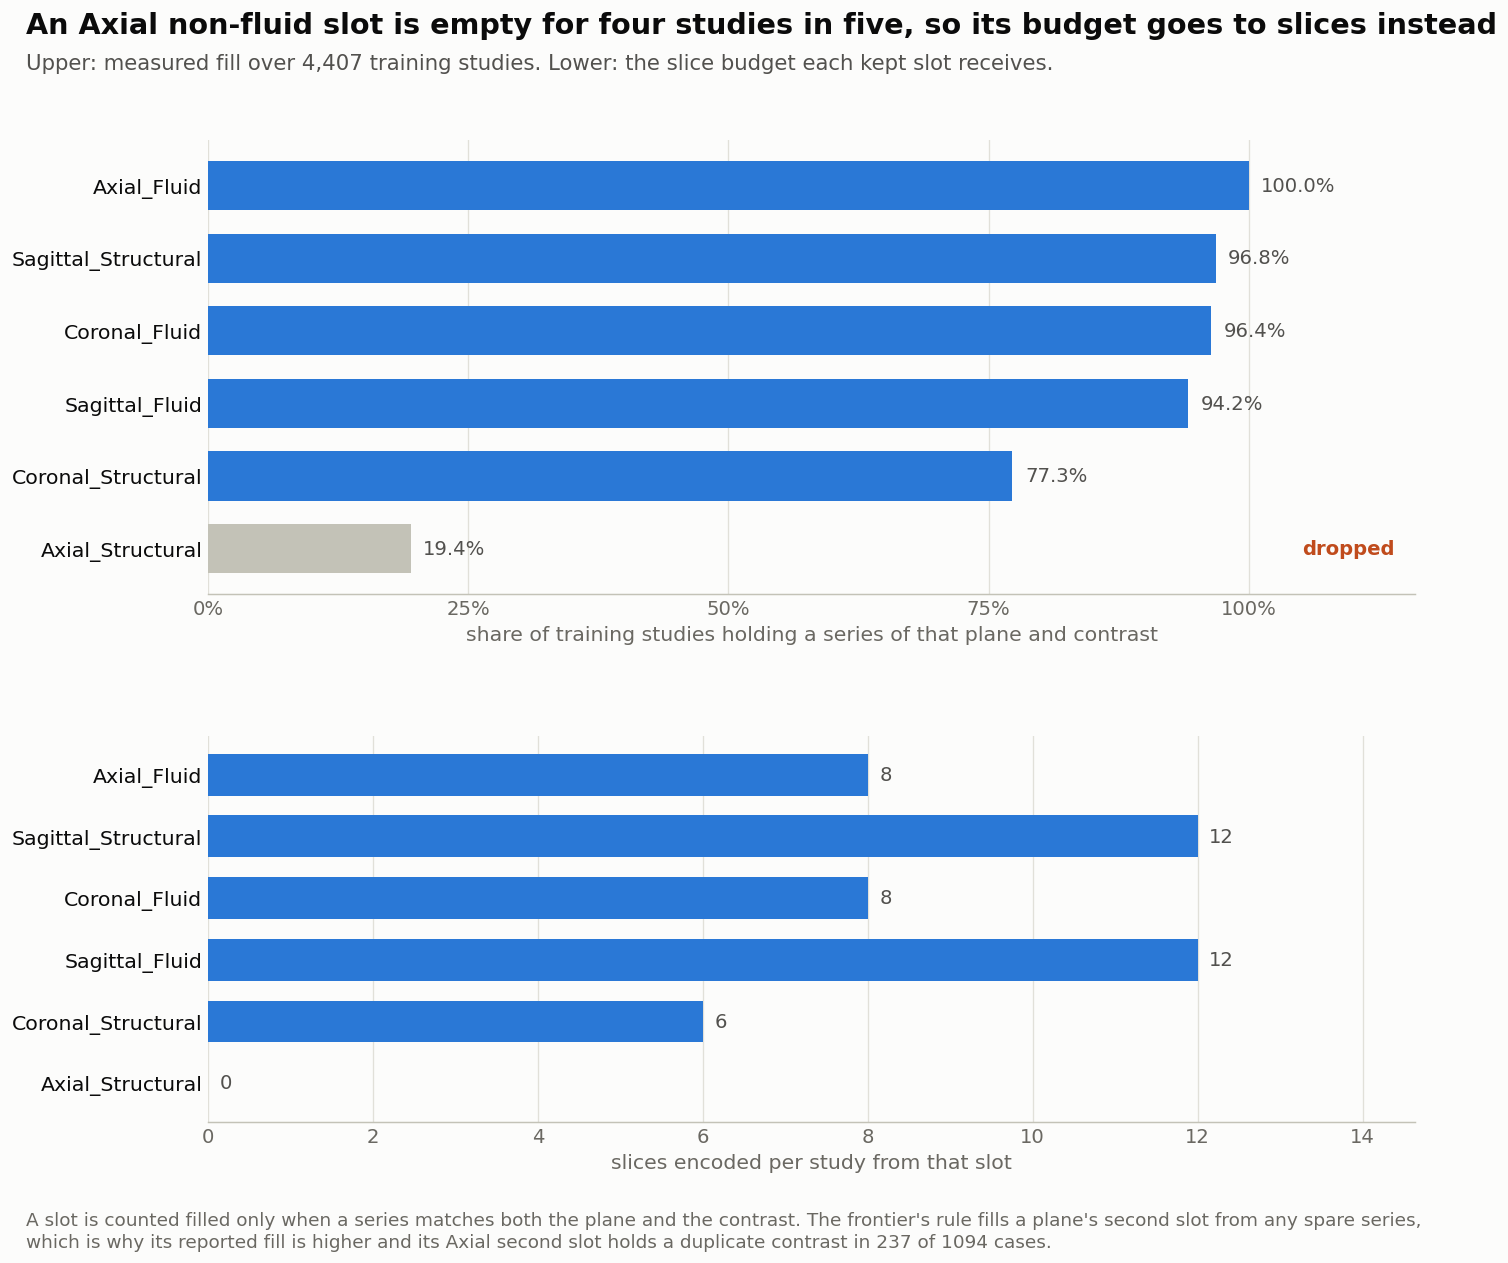

In [13]:
# Two panels, stacked, one label order shared, so a slot can be tracked straight
# down the figure. Upper: how often each candidate slot holds a genuine series.
# Lower: what each kept slot is given to spend.
order = fill.sort_values("fill", ascending=True).reset_index(drop=True)
ypos = np.arange(len(order))
colours = [PRIMARY if k else NEUTRAL for k in order["kept"]]

fig = plt.figure(figsize=(13.2, 10.8))
gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 0.85], hspace=0.34)

ax0 = fig.add_subplot(gs[0, 0])
ax0.barh(ypos, order["fill"].values, height=0.68, color=colours, zorder=3)
label_bars(ax0, order["fill"].values, ypos, fmt="{:.1%}", pad=0.012)
ax0.set_yticks(ypos)
ax0.set_yticklabels(order["slot"].tolist(), fontsize=12.5, color=INK)
ax0.set_xlim(0, 1.16)
ax0.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
ax0.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
ax0.set_xlabel("share of training studies holding a series of that plane and contrast")
style(ax0, "x")
ax0.spines["left"].set_visible(False)
dropped = order.loc[~order["kept"], "slot"].tolist()
if dropped:
    ax0.text(1.14, ypos[0], "dropped", ha="right", va="center", fontsize=12,
             color=ACCENT_TEXT, fontweight="bold")

ax1 = fig.add_subplot(gs[1, 0])
budgets = []
for name in order["slot"]:
    b = dict(zip(SLOT_NAMES, [k for _, _, k in SLOT_SPEC])).get(name, 0)
    budgets.append(b)
ax1.barh(ypos, budgets, height=0.68,
         color=[PRIMARY if b else NEUTRAL for b in budgets], zorder=3)
label_bars(ax1, budgets, ypos, fmt="{:.0f}", pad=0.14)
ax1.set_yticks(ypos)
ax1.set_yticklabels(order["slot"].tolist(), fontsize=12.5, color=INK)
ax1.set_xlim(0, max(budgets + [1]) * 1.22)
ax1.set_xlabel("slices encoded per study from that slot")
style(ax1, "x")
ax1.spines["left"].set_visible(False)

finish(fig,
       "An Axial non-fluid slot is empty for four studies in five, so its budget "
       "goes to slices instead",
       detail="Upper: measured fill over {:,} training studies. Lower: the slice "
              "budget each kept slot receives.".format(
                  tr_man["StudyInstanceUID"].nunique()),
       caption="A slot is counted filled only when a series matches both the plane "
               "and the contrast. The frontier's rule fills a plane's second slot "
               "from any spare series, which is why its reported fill is higher and "
               "its Axial second slot holds a duplicate contrast in {} of {} cases."
               .format(len(ax_two - ax_true), len(ax_two)))

<div style="background:#fcfcfb;border:1px solid #e1e0d9;border-left:6px solid #eb6834;border-radius:7px;padding:14px 18px;margin:26px 0 14px 0;"><h2 style="color:#0b0b0b;font-size:21px;margin:0;font-weight:700;letter-spacing:-.005em;"><span style="display:inline-block;min-width:26px;height:26px;line-height:26px;text-align:center;background:#256abf;color:#ffffff;border-radius:6px;font-size:14px;font-weight:700;margin-right:12px;vertical-align:middle;">5</span><span style="vertical-align:middle;">Slice order is a geometry problem, not a sort</span></h2></div>

The frontier orders slices by filename. Filenames here are SOP Instance UIDs, which are
random. It then samples 11 of them, reads their headers, sorts *those* by position and
picks three fractional positions from the sample. So the three slices it encodes are
three positions within a random 11-slice subset, and the physical extent they span is
whatever that subset happened to cover.

Position is in the files. `ImageOrientationPatient` gives the two in-plane direction
cosines; their cross product is the slice normal; the dot product of
`ImagePositionPatient` with that normal is the slice's signed position along the stack.
That is exact, it is invariant to how the scanner numbered the instances, and it is the
only ordering that makes "the 30% slice" mean the same thing in two different studies.

Headers are read with `stop_before_pixels=True` and a four-tag allowlist, so no pixel
decoder is involved and no transfer syntax can fail the read. The corpus mixes
uncompressed Explicit VR, Implicit VR, JPEG Lossless and JPEG 2000, and that mix is a
real hazard for the pixel path, not for this one. Every series has its headers read up to
a cap; the median series holds 30 slices and the cap is well above it, so ordering is
exact for almost every series and falls back to an evenly spaced filename subset only in
the long tail.

Slices are then drawn at evenly spaced fractional positions across a per-plane window of
the ordered stack, and the physical millimetres covered is reported. **Each encoded image
is a three-channel stack of the decoded slice and its two decoded neighbours**, so
neighbourhood context costs no extra DICOM reads: every decoded slice appears in up to
three images.

In [14]:
GEOM_TAGS = ["ImagePositionPatient", "ImageOrientationPatient",
             "SliceLocation", "InstanceNumber", "Laterality", "ImageLaterality"]

# Counters, so a degraded run is visible in the log rather than silent. They are
# incremented from worker threads, and `d[k] += 1` is three bytecodes, not one, so
# the lock is not decoration: an undercounted failure reads as a clean run.
import threading

STATS = {"series_missing": 0, "header_fail": 0, "pixel_fail": 0,
         "series_truncated": 0, "slots_empty": 0, "slices_decoded": 0,
         "exact_order": 0, "fallback_order": 0,
         "lat_left": 0, "lat_right_mirrored": 0, "lat_right_reversed": 0,
         "lat_absent": 0, "lat_conflict": 0}
_STATS_LOCK = threading.Lock()


def bump(key, n=1):
    """Increment one diagnostic counter under a lock.

    Args:
        key: Counter name.
        n: Amount to add.

    Returns:
        None.
    """
    with _STATS_LOCK:
        STATS[key] = STATS.get(key, 0) + n


def list_dicom_paths(folder):
    """List the .dcm files in one series directory.

    Args:
        folder: Series directory.

    Returns:
        A list of Paths sorted by filename, empty when the directory is missing
        or unreadable. Filename order is SOP UID order here, which is arbitrary;
        it is used only to take a deterministic subset, never as slice order.
    """
    try:
        return sorted((Path(e.path) for e in os.scandir(folder)
                       if e.is_file() and e.name.lower().endswith(".dcm")),
                      key=lambda p: p.name)
    except Exception:
        return []


def projected_position(ds, fallback):
    """Signed position of a slice along its own stack normal, in millimetres.

    The two in-plane direction cosines in ImageOrientationPatient span the slice
    plane; their cross product is the slice normal. Projecting
    ImagePositionPatient onto that normal gives a scalar that increases
    monotonically through the stack and is invariant to how the scanner numbered
    the instances. SliceLocation and InstanceNumber are fallbacks only.

    Args:
        ds: A pydicom dataset read with stop_before_pixels.
        fallback: Value to return when no geometry tag is usable.

    Returns:
        Float position.
    """
    try:
        iop = np.asarray(ds.ImageOrientationPatient, dtype=np.float64)
        ipp = np.asarray(ds.ImagePositionPatient, dtype=np.float64)
        if iop.size == 6 and ipp.size == 3:
            normal = np.cross(iop[:3], iop[3:])
            norm = float(np.linalg.norm(normal))
            if norm > 1e-8:
                return float(np.dot(ipp, normal / norm))
    except Exception:
        pass
    for attr in ("SliceLocation", "InstanceNumber"):
        try:
            v = float(getattr(ds, attr))
            if np.isfinite(v):
                return v
        except Exception:
            pass
    return float(fallback)


def read_laterality(ds):
    """Read which knee this slice belongs to, as "L", "R" or "" for unknown.

    Two tags carry it and neither is mandatory. `Laterality` is the general one;
    `ImageLaterality` is what some vendors write instead. The corpus contains at
    least the spellings L, R and LEFT, so the value is folded to its first
    character rather than compared whole, and anything that is not L or R is
    treated as unknown rather than guessed at.

    Args:
        ds: A pydicom dataset read with the GEOM_TAGS allowlist.

    Returns:
        "L", "R", or "" when neither tag is present or the value is unrecognised.
    """
    for tag in ("Laterality", "ImageLaterality"):
        v = getattr(ds, tag, None)
        if v is None:
            continue
        s = str(v).strip().upper()
        if s[:1] in ("L", "R"):
            return s[:1]
    return ""


def resolve_laterality(votes):
    """Collapse per-slice laterality readings into one value for the series.

    Args:
        votes: Iterable of per-slice values from `read_laterality`.

    Returns:
        "L", "R", or "" when the series is unlabelled or self-contradictory. A
        series that claims both sides is not a series whose geometry is
        understood, so it is left alone rather than resolved by majority.
    """
    seen = {v for v in votes if v}
    if len(seen) == 1:
        return seen.pop()
    if len(seen) > 1:
        bump("lat_conflict")
    return ""


def order_series(folder):
    """Order one series' slices by projected physical position.

    Headers are read with stop_before_pixels and a four-tag allowlist, so no
    pixel decoder is involved and none of the four transfer syntaxes in this
    corpus can fail the read. Series longer than the cap are subsampled by
    filename first, which is a uniform draw over positions because filenames are
    SOP UIDs.

    Args:
        folder: Series directory.

    Returns:
        Tuple of (ordered paths, ordered positions, number of files on disk,
        whether every file on disk was ordered, series laterality as "L", "R"
        or "").
    """
    paths = list_dicom_paths(folder)
    n_files = len(paths)
    if n_files == 0:
        bump("series_missing")
        return [], np.zeros(0), 0, False, ""

    exact = n_files <= MAX_HEADER_READS_PER_SERIES
    if not exact:
        bump("series_truncated")
        idx = np.linspace(0, n_files - 1, MAX_HEADER_READS_PER_SERIES)
        idx = np.unique(np.round(idx).astype(int))
        paths = [paths[i] for i in idx]

    positioned, lat_votes = [], []
    for i, p in enumerate(paths):
        try:
            ds = pydicom.dcmread(str(p), stop_before_pixels=True,
                                 specific_tags=GEOM_TAGS, force=True)
            positioned.append((projected_position(ds, i), p))
            lat_votes.append(read_laterality(ds))
        except Exception:
            bump("header_fail")
            positioned.append((float(i), p))
    positioned.sort(key=lambda t: t[0])
    bump("exact_order" if exact else "fallback_order")
    return ([t[1] for t in positioned],
            np.asarray([t[0] for t in positioned], dtype=np.float64),
            n_files, exact, resolve_laterality(lat_votes))


def pick_indices(n, k, lo, hi):
    """Choose k evenly spaced indices across a fractional window of n slices.

    Args:
        n: Number of ordered slices available.
        k: How many to take.
        lo: Lower fractional bound of the window, in [0, 1].
        hi: Upper fractional bound.

    Returns:
        A sorted array of unique integer indices, shorter than k when n is small.
    """
    if n <= 0 or k <= 0:
        return np.zeros(0, dtype=int)
    if n <= k:
        return np.arange(n)
    fracs = np.linspace(lo, hi, k)
    idx = np.round(fracs * (n - 1)).astype(int)
    return np.unique(np.clip(idx, 0, n - 1))

<div style="background:#fcfcfb;border:1px solid #e1e0d9;border-left:6px solid #eb6834;border-radius:7px;padding:14px 18px;margin:26px 0 14px 0;"><h2 style="color:#0b0b0b;font-size:21px;margin:0;font-weight:700;letter-spacing:-.005em;"><span style="display:inline-block;min-width:26px;height:26px;line-height:26px;text-align:center;background:#256abf;color:#ffffff;border-radius:6px;font-size:14px;font-weight:700;margin-right:12px;vertical-align:middle;">6</span><span style="vertical-align:middle;">Preprocessing: the window belongs to the series</span></h2></div>

Pixels are 12-bit and `RescaleSlope`/`RescaleIntercept` are applied first. Then the
question is what to normalise against, and the EDA already answered it: intensity
distributions differ sharply from series to series, so a global window is wrong.

A per-*slice* window, which is what the frontier uses, is wrong in the other direction.
It rescales every slice to its own 1st and 99th percentile, which means a slice through a
large effusion and a slice through dry bone come out with the same dynamic range. The
brightness of fluid on a fluid-sensitive sequence is the finding. Normalising it away
per slice destroys exactly the signal that `Effusion`, `Synovitis` and `Baker's` are
made of, and it also gives the three channels of one 2.5D image three different windows,
which paints colour fringes on every anatomical edge.

So the percentile window is computed once **per series**, from the pooled pixels of the
slices that series contributes, and applied unchanged to all of them. The body bounding
box is likewise computed once per series from the union of its slices, so the crop does
not jitter between neighbouring slices.

One thing the crop does *not* do here is buy resolution. On every series available
offline the knee fills the frame: the tissue mask reaches the image edge at every
threshold from 0.03 to 0.20, and the bounding box keeps 98 to 100% of the frame. These
acquisitions are already coned tightly to the joint, so the effective pitch stays at the
full 150 mm over the input size and there is no free magnification to collect. The crop
is kept as a guard for the series that are framed loosely, not as a lever. Whatever it
achieves on the full corpus is measured and printed after encoding rather than assumed
here.

### 6b. Which knee is this, and why four labels depend on the answer

Four of the twelve targets name a side: `Medial Meniscus`, `Lateral Meniscus`,
`Medial OA` and `Lateral OA`. Medial and lateral are defined against the midline of the
body, not against the image. Which side of the frame the medial compartment lands on
therefore depends on which knee was scanned, and that is a fact about the patient rather
than about the anatomy the label describes.

The EDA read the `Laterality` tag across the studies it sampled and found the corpus
mixes sides: 96 left, 84 right, 5 spelled `LEFT`, and 162 with the tag absent. So close
to a quarter of studies are mirror images of the rest, and a third of the metric is
being asked to learn a distinction from an axis the model has no way to observe. This is
not a subtle modelling choice. It is a third of the score sitting on a coin flip.

The correction is not one operation, because the mirror falls on a different axis in
each plane:

| Plane | Medial-lateral direction | Correction |
|---|---|---|
| Coronal, Axial | in the image plane | flip the last pixel axis |
| Sagittal | along the slice axis | reverse the stack order, leave pixels alone |

Sagittal is the one worth stating carefully. Mirroring a sagittal slice does nothing
useful, because each slice is already a section through the joint at one medial-lateral
depth. What differs between a left and a right knee is the direction the stack travels
through the joint, so the stack is reversed and the pixels are untouched. The reversal
happens before the 2.5D channels are assembled, so each slice still meets its true
neighbours, and the fractional position handed to the head is inverted with it rather
than left running backwards against its own pixels.

Studies with no tag are left exactly as they are. Forty-seven percent of the sample
carried no side, and a wrong flip is strictly worse than no flip: it moves a study to
the wrong side of an axis instead of leaving it on an unknown one. Those studies keep an
unresolved side axis and the cost falls on the same four labels as diluted supervision.
The run prints how many slots were normalised, how many were left alone, and how many
series contradicted themselves across their own slices, so the size of that residual is
a number in the log rather than an assumption here.

One consequence for the cache. Embeddings are keyed by a tag that now carries a
preprocessing version, because a cached embedding is the one artifact that cannot tell
you which pixels produced it. Reusing the previous cache here would reload right knees
encoded in their original orientation and report them as a new result.

In [15]:
def read_slice(path):
    """Decode one DICOM slice into a rescaled float array.

    RescaleSlope and RescaleIntercept are applied before anything else, and
    MONOCHROME1 is inverted so bright always means high signal. No window is
    applied here: the window belongs to the series, not the slice.

    Args:
        path: Path to a .dcm file.

    Returns:
        A 2D float32 array, or None when the file cannot be decoded.
    """
    try:
        ds = pydicom.dcmread(str(path), force=True)
        arr = ds.pixel_array.astype(np.float32)
    except Exception:
        bump("pixel_fail")
        return None
    try:
        slope = float(getattr(ds, "RescaleSlope", 1.0) or 1.0)
        intercept = float(getattr(ds, "RescaleIntercept", 0.0) or 0.0)
        arr = arr * slope + intercept
        if str(getattr(ds, "PhotometricInterpretation", "")).upper() == "MONOCHROME1":
            arr = float(np.nanmax(arr)) - arr
    except Exception:
        pass
    if not np.isfinite(arr).any():
        bump("pixel_fail")
        return None
    bump("slices_decoded")
    return arr


def series_window(arrays, lo_pct=1.0, hi_pct=99.5):
    """Outlier-resistant intensity window for a series, from its pooled pixels.

    This is the correction that matters most in preprocessing. A per-slice
    window rescales a slice through a large effusion and a slice through dry
    bone onto the same range, which deletes the very contrast that Effusion,
    Synovitis and Baker's are made of, and gives the three channels of one 2.5D
    image three different windows. One window per series keeps relative
    brightness intact within the series while still absorbing the sharp
    between-series intensity differences the EDA found.

    Args:
        arrays: List of 2D float arrays from one series.
        lo_pct: Lower percentile.
        hi_pct: Upper percentile.

    Returns:
        Tuple (low, high) with high strictly greater than low.
    """
    pool = []
    for a in arrays:
        flat = a[::3, ::3].ravel()
        flat = flat[np.isfinite(flat)]
        if flat.size:
            pool.append(flat)
    if not pool:
        return 0.0, 1.0
    pool = np.concatenate(pool)
    nz = pool[np.abs(pool) > 1e-8]
    src = nz if nz.size >= 256 else pool
    lo, hi = np.percentile(src, [lo_pct, hi_pct])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = float(np.min(pool)), float(np.max(pool))
    if hi <= lo:
        hi = lo + 1.0
    return float(lo), float(hi)


def series_bbox(arrays, low, high, thresh=0.06, margin=0.06):
    """Body bounding box for a whole series, from the union of its slices.

    Computed once per series so the crop does not jitter between neighbouring
    slices, which would put the same anatomy in different patch positions in the
    three channels of one image.

    Args:
        arrays: List of 2D float arrays from one series.
        low: Series window low.
        high: Series window high.
        thresh: Normalised intensity above which a pixel counts as tissue.
        margin: Fractional margin added around the union box.

    Returns:
        Tuple (y0, y1, x0, x1). The full frame when no box can be found.
    """
    h, w = arrays[0].shape
    y0, y1, x0, x1 = h, 0, w, 0
    span = max(high - low, 1e-6)
    for a in arrays:
        if a.shape != (h, w):
            return 0, h, 0, w
        m = ((a - low) / span) > thresh
        if m.sum() < 0.01 * h * w:
            continue
        ys, xs = np.where(m)
        y0 = min(y0, int(ys.min())); y1 = max(y1, int(ys.max()) + 1)
        x0 = min(x0, int(xs.min())); x1 = max(x1, int(xs.max()) + 1)
    if y1 <= y0 or x1 <= x0:
        return 0, h, 0, w
    my = max(2, int(margin * (y1 - y0)))
    mx = max(2, int(margin * (x1 - x0)))
    return (max(0, y0 - my), min(h, y1 + my), max(0, x0 - mx), min(w, x1 + mx))


CROP_RATIOS = []


def normalise_laterality(planes, plane, lat):
    """Map a right knee onto the left-knee convention.

    Four of the twelve targets are medial/lateral pairs, and medial and lateral
    are defined against the body midline rather than against the image. On a
    right knee they therefore fall on the opposite side of the frame from a left
    knee, so without this the four side-specific labels are being asked to learn
    from an axis the model cannot observe.

    The correction differs by plane because the mirror acts on a different axis:

    * Coronal and axial carry the medial-lateral direction in the image plane, so
      one knee is the horizontal mirror of the other and the last axis flips.
    * Sagittal carries it along the *slice* axis. Each slice is unchanged by the
      mirror; what differs is the direction in which the stack traverses the
      joint, so the stack order reverses and the pixels are left alone.

    A study with no `Laterality` tag is left untouched. Roughly half the corpus
    is unlabelled, and a wrong flip is worse than no flip: it moves a study to
    the wrong side rather than leaving it on an unknown one.

    Args:
        planes: List of normalised 2D slices in through-plane order.
        plane: Anatomical plane of this slot.
        lat: Series laterality, "L", "R" or "".

    Returns:
        Tuple of (possibly transformed planes, whether the stack was reversed).
    """
    if lat != "R":
        bump("lat_left" if lat == "L" else "lat_absent")
        return planes, False
    if plane in ("Coronal", "Axial"):
        bump("lat_right_mirrored")
        return [p[:, ::-1] for p in planes], False
    bump("lat_right_reversed")
    return planes[::-1], True


def build_slot_stack(folder, plane, k, size):
    """Decode, window, crop and resize one slot into 2.5D image channels.

    Every encoded image is the decoded slice plus its two decoded neighbours as
    the three channels, so neighbourhood context costs no extra DICOM reads:
    each decoded slice is reused in up to three images.

    Args:
        folder: Series directory.
        plane: Anatomical plane, selecting the sampling window.
        k: How many slices to encode from this slot.
        size: Output side length in pixels.

    Returns:
        Tuple of (images uint8 [m, 3, size, size], positions float32 [m],
        millimetres spanned, number of files on disk). m may be 0.
    """
    paths, positions, n_files, _, lat = order_series(folder)
    if not paths:
        return np.zeros((0, 3, size, size), np.uint8), np.zeros(0, np.float32), 0.0, 0
    lo, hi = PLANE_WINDOW.get(plane, (0.15, 0.85))
    idx = pick_indices(len(paths), k, lo, hi)
    if idx.size == 0:
        return np.zeros((0, 3, size, size), np.uint8), np.zeros(0, np.float32), 0.0, n_files

    arrays, kept = [], []
    for i in idx:
        a = read_slice(paths[int(i)])
        if a is not None:
            arrays.append(a)
            kept.append(int(i))
    if not arrays:
        return np.zeros((0, 3, size, size), np.uint8), np.zeros(0, np.float32), 0.0, n_files

    low, high = series_window(arrays)
    y0, y1, x0, x1 = series_bbox(arrays, low, high)
    h, w = arrays[0].shape
    if h * w > 0:
        CROP_RATIOS.append(math.sqrt(max(1, (y1 - y0) * (x1 - x0)) / float(h * w)))

    planes_norm = []
    span = max(high - low, 1e-6)
    for a in arrays:
        if a.shape != (h, w):
            a = resize_2d(a, max(h, w))[:h, :w]
        c = a[y0:y1, x0:x1]
        c = np.clip((c - low) / span, 0.0, 1.0)
        side = max(c.shape)
        pad = np.zeros((side, side), np.float32)
        oy, ox = (side - c.shape[0]) // 2, (side - c.shape[1]) // 2
        pad[oy:oy + c.shape[0], ox:ox + c.shape[1]] = c
        planes_norm.append(np.clip(resize_2d(pad, size) * 255.0, 0, 255).astype(np.uint8))

    # Section 6b. Applied before the 2.5D channels are assembled, so a reversed
    # sagittal stack still pairs each slice with its true neighbours rather than
    # with the neighbours it had in the un-normalised direction.
    planes_norm, stack_reversed = normalise_laterality(planes_norm, plane, lat)

    m = len(planes_norm)
    imgs = np.zeros((m, 3, size, size), np.uint8)
    for j in range(m):
        imgs[j, 0] = planes_norm[max(0, j - 1)]
        imgs[j, 1] = planes_norm[j]
        imgs[j, 2] = planes_norm[min(m - 1, j + 1)]

    pos = positions[np.asarray(kept, dtype=int)] if positions.size else np.arange(m)
    span_mm = float(np.abs(positions.max() - positions.min())) if positions.size > 1 else 0.0
    rng = max(1e-6, float(pos.max() - pos.min())) if m > 1 else 1.0
    frac = ((pos - pos.min()) / rng).astype(np.float32) if m > 1 else np.zeros(m, np.float32)
    if stack_reversed:
        # The head reads `frac` as distance along the slot's own axis. Reversing
        # the images without reversing this would hand every reversed study a
        # positional encoding that runs backwards against its own pixels.
        frac = (1.0 - frac[::-1]).astype(np.float32)
    return imgs, frac, span_mm, n_files


print("preprocessing ready")
print("laterality                   : right knees mapped onto the left convention, "
      "coronal/axial mirrored, sagittal stack reversed, untagged left alone")
print("per-series window percentiles: 1.0 / 99.5, pooled over the slices encoded")
print("sampling window by plane      :",
      ", ".join("{} {:.2f}-{:.2f}".format(k, v[0], v[1])
                for k, v in PLANE_WINDOW.items()))

preprocessing ready
laterality                   : right knees mapped onto the left convention, coronal/axial mirrored, sagittal stack reversed, untagged left alone
per-series window percentiles: 1.0 / 99.5, pooled over the slices encoded
sampling window by plane      : Sagittal 0.12-0.88, Coronal 0.20-0.80, Axial 0.12-0.88


<div style="background:#fcfcfb;border:1px solid #e1e0d9;border-left:6px solid #eb6834;border-radius:7px;padding:14px 18px;margin:26px 0 14px 0;"><h2 style="color:#0b0b0b;font-size:21px;margin:0;font-weight:700;letter-spacing:-.005em;"><span style="display:inline-block;min-width:26px;height:26px;line-height:26px;text-align:center;background:#256abf;color:#ffffff;border-radius:6px;font-size:14px;font-weight:700;margin-right:12px;vertical-align:middle;">7</span><span style="vertical-align:middle;">Encoding with a frozen DINOv2</span></h2></div>

The backbone loaded back in section 1 is `facebook/dinov2-small` from the Kaggle model
mount `metaresearch/dinov2/PyTorch/small/1`, read with `local_files_only=True`. Internet
is off, which a code-competition submission requires anyway.

The backbone is frozen and never fine-tuned. That is a deliberate choice given 58 gold
studies and a report-derived training signal of unknown fidelity: fine-tuning a 22M
parameter ViT against noisy pseudo-labels mostly teaches it the noise. What a frozen
backbone buys instead is that embeddings are computed once, cached, and every head
experiment afterwards costs seconds rather than hours.

DINOv2 interpolates its positional grid on the fly, so a non-native input size needs no
surgery, and the direction of that interpolation is worth naming. The released checkpoint
is configured at 518 px, a 37 by 37 grid. A 336 px input interpolates it down to 24 by 24.
A 126 px input interpolates it down to 9 by 9, discarding 94% of the positional
resolution the model was trained with. The higher input size is not an exotic setting
here, it is the closer one.

### Runtime projection before the work

The visible `test.csv` is a placeholder with three rows. At rerun it holds roughly 1,300
studies this notebook has never seen. Before any bulk encoding, a short probe times the
three phases separately (header listing and ordering, DICOM decode and preprocess, GPU
forward) and projects each to the rerun test set and to the full training set. The
projection is printed first, then acted on.

If the projection exceeds the budget the pipeline steps down in a fixed order. If the GPU
is the phase over budget, the input size drops one rung down the ladder, because that is
the only knob that moves GPU cost. Otherwise the per-slot slice budget is scaled back,
and only after that is the training set subsampled. The test set is never subsampled and
its encoding runs **first**, so a truncated run still has something to predict with.

In [16]:
from concurrent.futures import ThreadPoolExecutor

SLOT_ORDER = list(zip(SLOT_NAMES, SLOT_SPEC))


def study_stacks(study_id, dcm_root, slots, size):
    """Build the 2.5D image stack for every slot of one study.

    Slots are decoded in parallel; each slot is an independent series directory,
    so five threads is five concurrent DICOM decodes. Every failure is caught and
    counted rather than raised, and an empty slot returns an empty stack that the
    caller carries as a masked zero.

    Args:
        study_id: Study instance UID.
        dcm_root: Directory holding the per-study series directories.
        slots: Mapping study id -> slot name -> series id.
        size: Input side length in pixels.

    Returns:
        Dict mapping slot index to (images, fractional positions, span mm,
        files on disk).
    """
    chosen = slots.get(str(study_id), {})

    def one(args):
        """Decode a single slot, returning an empty stack on any failure."""
        i, (name, (plane, _flag, k)) = args
        series_id = chosen.get(name)
        if series_id is None or dcm_root is None:
            bump("slots_empty")
            return i, (np.zeros((0, 3, size, size), np.uint8),
                       np.zeros(0, np.float32), 0.0, 0)
        folder = Path(dcm_root) / str(study_id) / str(series_id)
        try:
            return i, build_slot_stack(folder, plane, k, size)
        except Exception:
            bump("slots_empty")
            return i, (np.zeros((0, 3, size, size), np.uint8),
                       np.zeros(0, np.float32), 0.0, 0)

    with ThreadPoolExecutor(max_workers=min(IO_WORKERS, N_SLOTS)) as pool:
        return dict(pool.map(one, list(enumerate(SLOT_ORDER))))


def probe_cost(ids, dcm_root, slots, size, n):
    """Time the decode and the GPU forward on a handful of studies.

    Args:
        ids: Candidate study ids.
        dcm_root: DICOM root for that split.
        slots: Slot assignment for that split.
        size: Input side length.
        n: How many studies to probe.

    Returns:
        Dict of measured per-study seconds, per-study image counts and the GPU
        rate in images per second. Zeros when nothing could be read.
    """
    use = [s for s in ids[:max(1, n)]]
    t_cpu = t_gpu = 0.0
    n_img = 0
    for sid in use:
        t0 = time.time()
        stacks = study_stacks(sid, dcm_root, slots, size)
        t_cpu += time.time() - t0
        imgs = [v[0] for v in stacks.values() if v[0].shape[0]]
        if not imgs:
            continue
        batch = np.concatenate(imgs, axis=0)
        n_img += batch.shape[0]
        t1 = time.time()
        embed_images(batch)
        t_gpu += time.time() - t1
    k = max(1, len(use))
    return {
        "studies": len(use),
        "cpu_per_study": t_cpu / k,
        "gpu_per_study": t_gpu / k,
        "images_per_study": n_img / k,
        "gpu_rate": (n_img / t_gpu) if t_gpu > 1e-6 else 0.0,
    }


test_ids = test["StudyInstanceUID"].astype(str).tolist()
probe_root, probe_ids, probe_slots = TEST_DCM, test_ids, SLOTS_TEST
if probe_root is None or not probe_ids:
    probe_root, probe_ids, probe_slots = TRAIN_DCM, train_ids, SLOTS_TRAIN

PROBE = {"studies": 0, "cpu_per_study": 0.0, "gpu_per_study": 0.0,
         "images_per_study": 0.0, "gpu_rate": 0.0}
if CAN_ENCODE and probe_root is not None:
    PROBE = probe_cost(probe_ids, probe_root, probe_slots, IMG_SIZE, PROBE_STUDIES)

print("probe: {} studies at {} px".format(PROBE["studies"], IMG_SIZE))
print("  decode + preprocess {:.2f} s/study".format(PROBE["cpu_per_study"]))
print("  GPU forward         {:.2f} s/study  ({:.0f} images/s)".format(
    PROBE["gpu_per_study"], PROBE["gpu_rate"]))
print("  images encoded      {:.1f} per study".format(PROBE["images_per_study"]))
print()

per_study = PROBE["cpu_per_study"] + PROBE["gpu_per_study"]
N_TRAIN_USE = len(train_ids)
SLICE_SCALE = 1.0
notes = []

def _projected_per_study():
    """Seconds per study under the current input size and slice scale.

    Returns:
        Float seconds. Zero when the probe measured nothing.
    """
    return (PROBE["cpu_per_study"] + PROBE["gpu_per_study"]) * SLICE_SCALE


if per_study > 0:
    for _attempt in range(6):
        per_study = _projected_per_study()
        t_test = per_study * RERUN_TEST_STUDIES
        t_train = per_study * N_TRAIN_USE
        gpu_share = ((PROBE["gpu_per_study"] / (PROBE["cpu_per_study"]
                                                + PROBE["gpu_per_study"]))
                     if per_study else 0.0)
        if t_test <= TEST_ENCODE_BUDGET_S and t_train <= TRAIN_ENCODE_BUDGET_S:
            break
        if gpu_share > 0.5 and IMG_SIZE in SIZE_LADDER \
                and SIZE_LADDER.index(IMG_SIZE) < len(SIZE_LADDER) - 1:
            old = IMG_SIZE
            IMG_SIZE = SIZE_LADDER[SIZE_LADDER.index(IMG_SIZE) + 1]
            # Token count scales with the square of the input size and attention adds
            # a further quadratic term, so the square is the conservative estimate.
            PROBE["gpu_per_study"] *= (IMG_SIZE / float(old)) ** 2
            notes.append("input size {} -> {} px, GPU was {:.0%} of the cost".format(
                old, IMG_SIZE, gpu_share))
            continue
        if SLICE_SCALE > 0.5:
            SLICE_SCALE = max(0.5, SLICE_SCALE - 0.25)
            notes.append("slice budget scaled to {:.0%}".format(SLICE_SCALE))
            continue
        per_study = _projected_per_study()
        N_TRAIN_USE = max(MIN_TRAIN_STUDIES,
                          min(N_TRAIN_USE, int(TRAIN_ENCODE_BUDGET_S / per_study)))
        notes.append("training studies capped at {}".format(N_TRAIN_USE))
        break

if SLICE_SCALE < 1.0:
    SLOT_SPEC = [(p, f, max(3, int(round(k * SLICE_SCALE)))) for p, f, k in SLOT_SPEC]
    MAX_SLICES = max(k for _, _, k in SLOT_SPEC)
    SLOT_ORDER = list(zip(SLOT_NAMES, SLOT_SPEC))

print("projected encode cost at {} px, {:.1f} images per study".format(
    IMG_SIZE, PROBE["images_per_study"] * SLICE_SCALE))
print("  visible test  ({:5d} studies): {:8.0f} s".format(
    len(test_ids), per_study * len(test_ids)))
print("  rerun test    (~{:4d} studies): {:8.0f} s   budget {:.0f} s".format(
    RERUN_TEST_STUDIES, per_study * RERUN_TEST_STUDIES, TEST_ENCODE_BUDGET_S))
print("  train         ({:5d} studies): {:8.0f} s   budget {:.0f} s".format(
    N_TRAIN_USE, per_study * N_TRAIN_USE, TRAIN_ENCODE_BUDGET_S))
print("  head + submission             : {:8.0f} s   budget".format(HEAD_BUDGET_S))
print("  total against the 9 h kernel  : {:8.0f} s of {:.0f} s".format(
    per_study * (RERUN_TEST_STUDIES + N_TRAIN_USE) + HEAD_BUDGET_S, WALL_BUDGET_S))
if notes:
    print()
    print("downshifts applied, in order:")
    for n in notes:
        print("  -", n)
else:
    print()
    print("no downshift needed")

# The ladder has a floor: the test set is never subsampled and the training set
# never goes below MIN_TRAIN_STUDIES. When the projection is still over budget
# after the floor is reached, say so here rather than printing numbers that
# quietly exceed the budget. The encode loop's own wall clock is what actually
# stops it, and it stops train before test because test runs first.
over_test = per_study * RERUN_TEST_STUDIES > TEST_ENCODE_BUDGET_S
over_train = per_study * N_TRAIN_USE > TRAIN_ENCODE_BUDGET_S
if over_test or over_train:
    print()
    print("STILL OVER BUDGET after every downshift ({}{}{}).".format(
        "rerun test" if over_test else "",
        " and " if over_test and over_train else "",
        "train" if over_train else ""))
    print("The encode loop is bounded by its own wall clock and will truncate,")
    print("leaving the remaining studies as masked zeros. Test is encoded first,")
    print("so a truncated run still predicts every test study.")

# Gold studies go first so they survive any truncation, then a deterministic shuffle.
rest = [s for s in train_ids if s not in set(gold_ids)]
_rng = np.random.default_rng(SEED)
_rng.shuffle(rest)
TRAIN_ENCODE_IDS = (gold_ids + rest)[:N_TRAIN_USE]
print()
print("studies to encode: {} train (gold first), {} test".format(
    len(TRAIN_ENCODE_IDS), len(test_ids)))

probe: 3 studies at 336 px
  decode + preprocess 0.91 s/study
  GPU forward         0.24 s/study  (159 images/s)
  images encoded      38.0 per study

projected encode cost at 336 px, 38.0 images per study
  visible test  (    3 studies):        3 s
  rerun test    (~1300 studies):     1498 s   budget 9000 s
  train         ( 4407 studies):     5078 s   budget 14000 s
  head + submission             :     2400 s   budget
  total against the 9 h kernel  :     8976 s of 30000 s

no downshift needed

studies to encode: 4407 train (gold first), 3 test


### The cache, and how to promote it

Embeddings are written to `/kaggle/working` as a float16 memory-mapped array plus a mask
and an id list, tagged with the input size, the slot layout and the slice budget. A rerun
with the same tag reloads instead of recomputing, which is what makes head iteration
cheap inside one session.

To split this into a train notebook and an inference notebook, which is how it should end
up once the design settles:

1. Run this notebook with `SAVE_TRAIN_CACHE = True`. The train embeddings and the fitted
   head weights land in the kernel output.
2. Publish that output as a Kaggle dataset with
   `kaggle datasets create -p /path/to/output`.
3. Add the dataset to the inference notebook's `dataset_sources`, set
   `LOAD_TRAIN_CACHE_FROM_DATASET = True`, and the rerun then encodes only the ~1,300
   test studies. That is roughly a fifth of the work, and it moves the training cost out
   of the nine-hour submission window entirely.

The train cache is deleted before the notebook finishes unless `SAVE_TRAIN_CACHE` is on,
because a 600 MB array in the kernel output slows every commit for no benefit until step
2 is actually wanted.

In [17]:
PIX = {}
PIXOK = {}

# The pixel cache is what makes fine-tuning affordable, and it is also the one
# artifact here big enough to fill the working directory and take the whole run
# with it. Project it before allocating anything: one 2.5D image per slot per
# study, uint8, for both splits. If it does not fit, the fine-tune is dropped and
# the frozen path proceeds, which is the degradation that costs least.
FT_BYTES_PER_STUDY = N_SLOTS * 3 * IMG_SIZE * IMG_SIZE
if FINETUNE:
    _ft_gb = (len(TRAIN_ENCODE_IDS) + len(test_ids)) * FT_BYTES_PER_STUDY / 1e9
    print("pixel cache projected: {:.1f} GB for {} train + {} test studies".format(
        _ft_gb, len(TRAIN_ENCODE_IDS), len(test_ids)))
    if _ft_gb > FT_DISK_BUDGET_GB:
        FINETUNE = False
        print("  over the {:.0f} GB budget; fine-tuning disabled, frozen path only"
              .format(FT_DISK_BUDGET_GB))

SLOT_SIG = "-".join(str(k) for _, _, k in SLOT_SPEC)
# Bumped whenever the pixels handed to the backbone change, which is the only
# thing a cached embedding cannot tell you about itself. v2 is laterality
# normalisation (section 6b). Without this bump a rerun would silently reload
# embeddings encoded from un-normalised right knees and report them as new.
PREP_VERSION = "lat2"
CACHE_TAG = "dinos{}_slots{}_{}_{}".format(IMG_SIZE, SLOT_SIG, SLICE_DIM,
                                           PREP_VERSION)


def cache_files(split):
    """Paths of the four cache artifacts for one split.

    Args:
        split: "train" or "test".

    Returns:
        Dict of name -> Path under the working directory.
    """
    stem = "emb_{}_{}".format(split, CACHE_TAG)
    f = {
        "emb": WORK / (stem + ".npy"),
        "mask": WORK / (stem + "_mask.npy"),
        "pos": WORK / (stem + "_pos.npy"),
        "meta": WORK / (stem + "_meta.npz"),
        "ids": WORK / (stem + "_ids.csv"),
    }
    if FINETUNE:
        # Pixels, not embeddings. Fine-tuning revisits the same images every epoch
        # and re-decoding them per epoch would make the epoch count a function of
        # I/O rather than of learning. One 2.5D image per slot at uint8 costs
        # N_SLOTS * 3 * IMG_SIZE^2 bytes per study, about 1.7 MB at 336 px.
        f["pix"] = WORK / (stem + "_pix.npy")
        f["pixok"] = WORK / (stem + "_pixok.npy")
    return f


def load_cached(split, ids):
    """Reload a cached split when it exists and covers exactly these ids.

    Args:
        split: "train" or "test".
        ids: The study ids this run wants, in order.

    Returns:
        Tuple of (emb, mask, pos, nfiles, used, span) or None.
    """
    f = cache_files(split)
    dataset_dir = None
    if split == "train" and LOAD_TRAIN_CACHE_FROM_DATASET:
        for d in _label_search_dirs():
            if (d / f["emb"].name).is_file():
                dataset_dir = d
                break
    if dataset_dir is not None:
        f = {k: dataset_dir / v.name for k, v in f.items()}
    if not all(p.is_file() for p in f.values()):
        return None
    try:
        cached_ids = pd.read_csv(f["ids"])["StudyInstanceUID"].astype(str).tolist()
        if cached_ids != list(ids):
            print("cache for", split, "covers different studies; recomputing")
            return None
        meta = np.load(f["meta"])
        print("reusing cached embeddings for", split, "from", f["emb"].parent)
        if FINETUNE:
            PIX[split] = np.load(f["pix"], mmap_mode="r")
            PIXOK[split] = np.load(f["pixok"])
        return (np.load(f["emb"], mmap_mode="r"), np.load(f["mask"]),
                np.load(f["pos"]), meta["nfiles"], meta["used"], meta["span"])
    except Exception as exc:
        print("cache for", split, "unreadable:", exc)
        return None


def encode_split(ids, dcm_root, slots, split, budget_s):
    """Encode one split into a cached embedding array.

    The encoding is bounded by a wall clock. If the budget runs out the loop
    stops and every remaining study is left as a masked zero, which the head
    handles; a truncated run still produces a submission. Test is always encoded
    before train for exactly this reason.

    Args:
        ids: Study ids to encode, in order.
        dcm_root: Directory holding per-study series directories.
        slots: Slot assignment for that split.
        split: "train" or "test".
        budget_s: Wall-clock seconds allowed.

    Returns:
        Tuple of (emb, mask, pos, nfiles, used, span).
    """
    n = len(ids)
    hit = load_cached(split, ids)
    if hit is not None:
        return hit

    f = cache_files(split)
    emb = np.lib.format.open_memmap(
        f["emb"], mode="w+", dtype=np.float16, shape=(n, N_SLOTS, MAX_SLICES, SLICE_DIM))
    mask = np.zeros((n, N_SLOTS, MAX_SLICES), np.bool_)
    pos = np.zeros((n, N_SLOTS, MAX_SLICES), np.float16)
    nfiles = np.zeros((n, N_SLOTS), np.int32)
    used = np.zeros((n, N_SLOTS), np.int32)
    span = np.zeros((n, N_SLOTS), np.float32)

    pix = pixok = None
    if FINETUNE:
        pix = np.lib.format.open_memmap(
            f["pix"], mode="w+", dtype=np.uint8,
            shape=(n, N_SLOTS, 3, IMG_SIZE, IMG_SIZE))
        pixok = np.zeros((n, N_SLOTS), np.bool_)
        print("pixel cache for {}: {:.1f} GB at {}".format(
            split, pix.nbytes / 1e9, f["pix"].name))
        PIX[split] = pix
        PIXOK[split] = pixok

    if not CAN_ENCODE or dcm_root is None:
        print("encode", split, ": skipped, the imaging path is unavailable here")
        emb.flush()
        pd.DataFrame({"StudyInstanceUID": ids}).to_csv(f["ids"], index=False)
        np.save(f["mask"], mask); np.save(f["pos"], pos)
        np.savez(f["meta"], nfiles=nfiles, used=used, span=span)
        if pix is not None:
            pix.flush()
            np.save(f["pixok"], pixok)
        return emb, mask, pos, nfiles, used, span

    t0 = time.time()
    deadline = t0 + budget_s
    done = 0
    report_every = max(1, n // 20)
    for i, sid in enumerate(ids):
        if time.time() > deadline:
            print("encode {}: budget of {:.0f}s spent after {} of {} studies".format(
                split, budget_s, i, n))
            break
        try:
            stacks = study_stacks(sid, dcm_root, slots, IMG_SIZE)
        except Exception:
            bump("slots_empty")
            continue
        batch, index = [], []
        for si, (imgs, frac, sp, nf) in stacks.items():
            nfiles[i, si] = nf
            span[i, si] = sp
            m = min(imgs.shape[0], MAX_SLICES)
            if m == 0:
                continue
            used[i, si] = m
            pos[i, si, :m] = frac[:m].astype(np.float16)
            if pix is not None:
                # The slot's centre image. imgs[c] is already the 2.5D triplet of
                # three consecutive slices, so this is the same input the frozen
                # path sees at that position, kept rather than thrown away after
                # embedding. The pixels are in memory here; storing them costs no
                # extra DICOM read.
                pix[i, si] = imgs[m // 2]
                pixok[i, si] = True
            batch.append(imgs[:m])
            index.extend([(si, j) for j in range(m)])
        if not batch:
            continue
        try:
            vecs = embed_images(np.concatenate(batch, axis=0))
        except Exception as exc:
            print("embed failed on study", i, ":", type(exc).__name__, exc)
            bump("pixel_fail")
            continue
        for (si, j), v in zip(index, vecs):
            emb[i, si, j] = v.astype(np.float16)
            mask[i, si, j] = True
        done += 1
        if (i + 1) % report_every == 0:
            rate = (i + 1) / max(1e-6, time.time() - t0)
            print("  {} {:5d}/{:5d}  {:.2f} studies/s  eta {:.0f}s".format(
                split, i + 1, n, rate, (n - i - 1) / max(rate, 1e-6)))

    emb.flush()
    pd.DataFrame({"StudyInstanceUID": ids}).to_csv(f["ids"], index=False)
    np.save(f["mask"], mask)
    np.save(f["pos"], pos)
    np.savez(f["meta"], nfiles=nfiles, used=used, span=span)
    if pix is not None:
        pix.flush()
        np.save(f["pixok"], pixok)
        print("  pixel cache: {} of {} studies carry at least one slot".format(
            int(pixok.any(axis=1).sum()), n))
    print("encode {}: {} of {} studies in {:.0f}s -> {} ({:.0f} MB)".format(
        split, done, n, time.time() - t0, f["emb"].name,
        f["emb"].stat().st_size / 1e6 if f["emb"].is_file() else 0.0))
    return emb, mask, pos, nfiles, used, span


# Test first. A truncated run must still have something to predict with.
TE = encode_split(test_ids, TEST_DCM, SLOTS_TEST, "test", TEST_ENCODE_BUDGET_S)
TR = encode_split(TRAIN_ENCODE_IDS, TRAIN_DCM, SLOTS_TRAIN, "train",
                  TRAIN_ENCODE_BUDGET_S)
emb_te, mask_te, pos_te, nf_te, used_te, span_te = TE
emb_tr, mask_tr, pos_tr, nf_tr, used_tr, span_tr = TR
gc.collect()

pixel cache projected: 7.5 GB for 4407 train + 3 test studies
pixel cache for test: 0.0 GB at emb_test_dinos336_slots12-12-8-6-8_1152_lat2_pix.npy
  test     1/    3  2.04 studies/s  eta 1s
  test     2/    3  1.84 studies/s  eta 1s
  test     3/    3  1.63 studies/s  eta 0s
  pixel cache: 3 of 3 studies carry at least one slot
encode test: 3 of 3 studies in 2s -> emb_test_dinos336_slots12-12-8-6-8_1152_lat2.npy (0 MB)
pixel cache for train: 7.5 GB at emb_train_dinos336_slots12-12-8-6-8_1152_lat2_pix.npy
  train   220/ 4407  1.15 studies/s  eta 3646s
  train   440/ 4407  1.15 studies/s  eta 3446s
  train   660/ 4407  1.13 studies/s  eta 3310s
  train   880/ 4407  1.14 studies/s  eta 3099s
  train  1100/ 4407  1.13 studies/s  eta 2917s
  train  1320/ 4407  1.12 studies/s  eta 2753s
  train  1540/ 4407  1.12 studies/s  eta 2569s
  train  1760/ 4407  1.11 studies/s  eta 2392s
  train  1980/ 4407  1.11 studies/s  eta 2190s
  train  2200/ 4407  1.11 studies/s  eta 1989s
  train  2420/ 4407 

0

In [18]:
def coverage_report(name, mask, nfiles, used, span, man, ids):
    """Print what fraction of each study's volume was actually encoded.

    Args:
        name: Split name for the log.
        mask: Boolean array [studies, slots, slices].
        nfiles: Files on disk per selected series.
        used: Slices encoded per selected series.
        span: Millimetres spanned by each selected series.
        man: Normalised manifest for that split.
        ids: Study ids in row order.

    Returns:
        None.
    """
    n_enc = mask.sum(axis=(1, 2))
    have = n_enc > 0
    if not have.any():
        print(name, ": nothing was encoded")
        return
    sel_files = nfiles.sum(axis=1)
    sel_used = used.sum(axis=1)
    ok = sel_files > 0
    per_series = np.where(nfiles > 0, used / np.maximum(nfiles, 1), np.nan)

    series_per_study = (man.groupby("StudyInstanceUID").size()
                        .reindex(ids).fillna(0).values if len(man) else np.zeros(len(ids)))
    mean_len = np.where(used.sum(axis=1) > 0,
                        nfiles.sum(axis=1) / np.maximum((nfiles > 0).sum(axis=1), 1), 0.0)
    est_study_slices = series_per_study * mean_len

    print("{}: {} of {} studies carry at least one encoded slice".format(
        name, int(have.sum()), len(ids)))
    print("  slices encoded per study      : mean {:.1f}, median {:.0f}, max {}".format(
        n_enc[have].mean(), np.median(n_enc[have]), int(n_enc.max())))
    if ok.any():
        print("  share of the SELECTED series  : {:.1%}".format(
            sel_used[ok].sum() / max(1, sel_files[ok].sum())))
    good = est_study_slices > 0
    if good.any():
        print("  share of the whole study      : {:.1%} (estimated from {:.1f} series "
              "per study x {:.0f} slices per series)".format(
                  sel_used[good].sum() / max(1.0, est_study_slices[good].sum()),
                  series_per_study[good].mean(), mean_len[good].mean()))
    finite = span[span > 0]
    if finite.size:
        print("  physical extent per series    : {:.0f} mm scanned, sampled across "
              "the plane window".format(np.median(finite)))
    slot_use = (mask.sum(axis=2) > 0).mean(axis=0)
    print("  slots carrying data           : " + ", ".join(
        "{} {:.0%}".format(s, v) for s, v in zip(SLOT_NAMES, slot_use)))


coverage_report("train", mask_tr, nf_tr, used_tr, span_tr, tr_man, TRAIN_ENCODE_IDS)
print()
coverage_report("test ", mask_te, nf_te, used_te, span_te, te_man, test_ids)
print()
if CROP_RATIOS:
    r = float(np.median(CROP_RATIOS))
    print("median body crop keeps {:.0%} of the frame, so the effective pitch is "
          "{:.3f} mm/px and one patch token covers {:.2f} mm".format(
              r, FOV_MM * r / IMG_SIZE, FOV_MM * r * PATCH_PX / IMG_SIZE))
print()
print("failure counters:", ", ".join("{} {}".format(k, v) for k, v in STATS.items()))
print("  series ordered exactly (every file on disk): {} | subsampled: {}".format(
    STATS["exact_order"], STATS["fallback_order"]))
_lat_seen = (STATS["lat_left"] + STATS["lat_right_mirrored"]
             + STATS["lat_right_reversed"] + STATS["lat_absent"])
_lat_fixed = STATS["lat_right_mirrored"] + STATS["lat_right_reversed"]
print("  laterality: {} already left, {} right mirrored (coronal/axial), {} right "
      "reversed (sagittal), {} unlabelled and left alone, {} self-contradictory".format(
          STATS["lat_left"], STATS["lat_right_mirrored"],
          STATS["lat_right_reversed"], STATS["lat_absent"], STATS["lat_conflict"]))
if _lat_seen:
    print("  {:.1%} of slots were normalised onto the left-knee convention; "
          "{:.1%} carried no side and keep an unresolved axis".format(
              _lat_fixed / _lat_seen, STATS["lat_absent"] / _lat_seen))

train: 4407 of 4407 studies carry at least one encoded slice
  slices encoded per study      : mean 43.3, median 46, max 46
  share of the SELECTED series  : 28.1%
  share of the whole study      : 23.1% (estimated from 5.5 series per study x 34 slices per series)
  physical extent per series    : 102 mm scanned, sampled across the plane window
  slots carrying data           : Sagittal_Fluid 94%, Sagittal_Structural 97%, Coronal_Fluid 96%, Coronal_Structural 77%, Axial_Fluid 100%

test : 3 of 3 studies carry at least one encoded slice
  slices encoded per study      : mean 38.0, median 40, max 46
  share of the SELECTED series  : 24.3%
  share of the whole study      : 17.7% (estimated from 5.0 series per study x 43 slices per series)
  physical extent per series    : 108 mm scanned, sampled across the plane window
  slots carrying data           : Sagittal_Fluid 67%, Sagittal_Structural 100%, Coronal_Fluid 100%, Coronal_Structural 33%, Axial_Fluid 100%

median body crop keeps 99% of 

<div style="background:#fcfcfb;border:1px solid #e1e0d9;border-left:6px solid #eb6834;border-radius:7px;padding:14px 18px;margin:26px 0 14px 0;"><h2 style="color:#0b0b0b;font-size:21px;margin:0;font-weight:700;letter-spacing:-.005em;"><span style="display:inline-block;min-width:26px;height:26px;line-height:26px;text-align:center;background:#256abf;color:#ffffff;border-radius:6px;font-size:14px;font-weight:700;margin-right:12px;vertical-align:middle;">8</span><span style="vertical-align:middle;">Head and validation</span></h2></div>

Two heads, fitted on the cached embeddings, reported separately and blended.

**A ridge probe.** Per study, per slot, the mean and the maximum over encoded slices of
the 1,152-dimensional slice vector, concatenated across the five slots, reduced by a
truncated SVD fitted on the training rows of each fold, then a multi-output `RidgeCV`.
It is the control: linear, closed-form, no capacity to invent structure.

**A slice-attention head.** The same cached vectors, but the pooling is learned. Twelve
queries, one per finding, attend over the flattened slot-by-slice token set with the
padding mask applied, so `Medial Meniscus` can weight the medial sagittal slices and
`PF OA` can weight the axial ones. Fixed epochs, no early stopping on the fold being
scored, three seeds averaged. A bare linear probe cannot express "look at this slice",
which is the whole reason for encoding 43 slices instead of 3.

The two are blended at a fixed 0.5 by rank average. The full weight curve is printed for
information and deliberately not tuned: choosing a blend weight on twelve labels' worth
of out-of-fold estimates is how a number that does not survive contact with the
leaderboard gets manufactured.

**Folds.** `GroupKFold`, grouped by duplicate report text. Forty-nine report texts in
this corpus are shared by 183 studies, the largest block holding 37. Any extractor gives
every study in such a block an identical target vector, so a block split across folds
scores the model on a target whose source it has already seen. Note what is *not* used
here: `PatientID`. Patients are 1:1 with studies in this corpus, 4,407 of 4,407, so
grouping by patient is a no-op, and the duplicate-report grouping is the one that does
any work. Skipping the patient grouping also means the fold construction reads no DICOM
headers at all.

In [19]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score

# Patients are 1:1 with studies in this corpus, 4,407 of 4,407, so a PatientID
# grouping is a no-op and reading DICOM PatientID to build it would be pure cost.
# The grouping that does work is duplicate report text: 49 texts are shared by 183
# studies, the largest block holding 37, and any extractor gives every study in a
# block the same twelve targets. A block split across folds scores the model on a
# target whose source it has already seen.
report_by_study = {}
if report_col is not None:
    for _sid, _txt in zip(train["StudyInstanceUID"].astype(str), train[report_col]):
        report_by_study[_sid] = _txt.strip() if isinstance(_txt, str) else ""

fold_ids = list(TRAIN_ENCODE_IDS)
group_of = {}
next_group = 0
text_group = {}
for sid in fold_ids:
    txt = report_by_study.get(sid, "")
    if txt:
        if txt not in text_group:
            text_group[txt] = next_group
            next_group += 1
        group_of[sid] = text_group[txt]
    else:
        group_of[sid] = next_group
        next_group += 1
groups = np.asarray([group_of[s] for s in fold_ids])
sizes = pd.Series(groups).value_counts()
n_blocks = int((sizes > 1).sum())
print("fold grouping: {} studies -> {} groups".format(len(fold_ids), len(sizes)))
print("  {} duplicate-report blocks covering {} studies, largest block {}".format(
    n_blocks, int(sizes[sizes > 1].sum()), int(sizes.iloc[0])))

n_splits = max(2, min(N_FOLDS, len(sizes)))
gkf = GroupKFold(n_splits=n_splits)
FOLDS = list(gkf.split(np.zeros(len(fold_ids)), groups=groups))
for k, (tr_i, va_i) in enumerate(FOLDS):
    shared = set(groups[tr_i]) & set(groups[va_i])
    assert not shared, "fold {} leaks {} groups across the split".format(k, len(shared))
print("  {} folds, no group appears on both sides of any split".format(len(FOLDS)))

fold grouping: 4407 studies -> 4273 groups
  49 duplicate-report blocks covering 183 studies, largest block 37
  5 folds, no group appears on both sides of any split


In [20]:
def pooled_features(emb, mask):
    """Collapse the per-slice embeddings to one vector per study.

    Mean and maximum over the encoded slices of each slot, concatenated across
    slots. The maximum is kept for the same reason it is kept over patch tokens:
    a finding visible on two slices out of twelve is averaged away and is not
    maximised away.

    Args:
        emb: float16 array [studies, slots, slices, dim].
        mask: boolean array [studies, slots, slices].

    Returns:
        float32 array [studies, slots * 2 * dim].
    """
    n = emb.shape[0]
    out = np.zeros((n, N_SLOTS * 2 * SLICE_DIM), np.float32)
    step = max(1, 256)
    for start in range(0, n, step):
        stop = min(n, start + step)
        block = np.asarray(emb[start:stop], dtype=np.float32)
        m = mask[start:stop][..., None].astype(np.float32)
        cnt = np.maximum(m.sum(axis=2), 1.0)
        mean = (block * m).sum(axis=2) / cnt
        neg = np.where(m > 0, block, -1e4)
        mx = neg.max(axis=2)
        mx = np.where(m.sum(axis=2) > 0, mx, 0.0)
        out[start:stop] = np.concatenate([mean, mx], axis=2).reshape(stop - start, -1)
    return out


def manifest_features(ids, man, slots, mask):
    """Per-study features that both splits always carry.

    Everything here comes from the series manifest, which the hidden test set
    ships, plus the encode mask. Nothing is read from a report and nothing is
    read from a DICOM header, so train and test go through one code path with no
    chance of a block existing on one side only.

    Args:
        ids: Study ids in row order.
        man: Normalised manifest.
        slots: Slot assignment.
        mask: Encode mask [studies, slots, slices].

    Returns:
        Tuple of (float32 array [studies, n_features], feature names).
    """
    by_study = {s: g for s, g in man.groupby("StudyInstanceUID")} if len(man) else {}
    rows = []
    for i, sid in enumerate(ids):
        g = by_study.get(sid)
        total = len(g) if g is not None else 0
        counts = [float((g["plane"] == p).sum()) if g is not None else 0.0
                  for p in PLANES]
        fluid = float(g["fluid"].mean()) if g is not None and total else 0.0
        present = [1.0 if n in slots.get(sid, {}) else 0.0 for n in SLOT_NAMES]
        enc = (mask[i].sum(axis=1) / np.maximum(
            np.asarray([k for _, _, k in SLOT_SPEC], np.float32), 1.0)).tolist()
        rows.append([math.log1p(total)] + counts + [fluid] + present + enc)
    names = (["log_n_series"] + ["n_" + p for p in PLANES] + ["fluid_frac"]
             + ["has_" + n for n in SLOT_NAMES] + ["enc_" + n for n in SLOT_NAMES])
    return np.asarray(rows, np.float32), names


enc_rate_tr = float((mask_tr.sum(axis=(1, 2)) > 0).mean()) if len(TRAIN_ENCODE_IDS) else 0.0
enc_rate_te = float((mask_te.sum(axis=(1, 2)) > 0).mean()) if len(test_ids) else 0.0
EMB_OK = (enc_rate_tr >= 0.5 and enc_rate_te >= 0.5
          and abs(enc_rate_tr - enc_rate_te) <= 0.25)
print("studies with embeddings: train {:.1%} | test {:.1%}".format(
    enc_rate_tr, enc_rate_te))
if not EMB_OK:
    print("coverage is absent or lopsided, so every embedding column is dropped and")
    print("the head falls back to the series manifest, which both sides always have.")

META_TR, META_NAMES = manifest_features(TRAIN_ENCODE_IDS, tr_man, SLOTS_TRAIN, mask_tr)
META_TE, _ = manifest_features(test_ids, te_man, SLOTS_TEST, mask_te)

if EMB_OK:
    t0 = time.time()
    POOL_TR = pooled_features(emb_tr, mask_tr)
    POOL_TE = pooled_features(emb_te, mask_te)
    print("pooled features: train {} | test {} | {:.1f}s".format(
        POOL_TR.shape, POOL_TE.shape, time.time() - t0))
else:
    POOL_TR = np.zeros((len(TRAIN_ENCODE_IDS), 0), np.float32)
    POOL_TE = np.zeros((len(test_ids), 0), np.float32)

Y = Y_soft.reindex(TRAIN_ENCODE_IDS)[LABELS].astype(np.float32).values
W = np.asarray([GOLD_WEIGHT if s in set(gold_ids) else 1.0
                for s in TRAIN_ENCODE_IDS], np.float32)
Y_HARD = (Y >= 0.5).astype(int)
assert Y.shape[0] == POOL_TR.shape[0] == META_TR.shape[0], \
    "label rows drifted from feature rows"
print("target matrix  :", Y.shape, "| positives at 0.5:", int(Y_HARD.sum()))

studies with embeddings: train 100.0% | test 100.0%
pooled features: train (4407, 11520) | test (3, 11520) | 5.0s
target matrix  : (4407, 12) | positives at 0.5: 13802


In [21]:
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

# The control head. Linear, closed form, no capacity to invent structure. The SVD
# is refitted inside every fold on the training rows alone, so no validation row
# contributes to the basis the model is expressed in.
RIDGE_ALPHAS = np.logspace(0.0, 5.0, 11)


def fit_ridge_fold(x_tr, y_tr, w_tr, x_va, x_te):
    """Fit the ridge probe on one fold and predict the validation and test rows.

    Args:
        x_tr: Training design matrix.
        y_tr: Soft targets [n, 12].
        w_tr: Per-row weights.
        x_va: Validation design matrix.
        x_te: Test design matrix.

    Returns:
        Tuple of (validation predictions, test predictions).
    """
    if x_tr.shape[1] == 0:
        return (np.zeros((x_va.shape[0], len(LABELS))),
                np.zeros((x_te.shape[0], len(LABELS))))
    comps = int(min(SVD_COMPONENTS, max(2, min(x_tr.shape) - 1)))
    if x_tr.shape[1] > comps:
        svd = TruncatedSVD(n_components=comps, random_state=SEED)
        a = svd.fit_transform(x_tr)
        b, c = svd.transform(x_va), svd.transform(x_te)
    else:
        a, b, c = x_tr, x_va, x_te
    sc = StandardScaler().fit(a)
    a, b, c = sc.transform(a), sc.transform(b), sc.transform(c)
    model = RidgeCV(alphas=RIDGE_ALPHAS)
    model.fit(a, y_tr, sample_weight=w_tr)
    return model.predict(b), model.predict(c)


X_TR = np.hstack([POOL_TR, META_TR]) if POOL_TR.shape[1] else META_TR
X_TE = np.hstack([POOL_TE, META_TE]) if POOL_TE.shape[1] else META_TE
assert X_TR.shape[1] == X_TE.shape[1], "train/test feature width mismatch"

t0 = time.time()
oof_ridge = np.zeros((len(TRAIN_ENCODE_IDS), len(LABELS)), np.float32)
te_ridge = np.zeros((len(test_ids), len(LABELS)), np.float32)
for k, (tr_i, va_i) in enumerate(FOLDS):
    try:
        p_va, p_te = fit_ridge_fold(X_TR[tr_i], Y[tr_i], W[tr_i], X_TR[va_i], X_TE)
    except Exception as exc:
        print("ridge fold", k, "failed:", type(exc).__name__, exc)
        p_va = np.tile(Y[tr_i].mean(axis=0), (len(va_i), 1))
        p_te = np.tile(Y[tr_i].mean(axis=0), (len(test_ids), 1))
    oof_ridge[va_i] = p_va
    te_ridge += p_te / len(FOLDS)
print("ridge probe: {} folds in {:.1f}s, {} features".format(
    len(FOLDS), time.time() - t0, X_TR.shape[1]))

ridge probe: 5 folds in 31.2s, 11535 features


In [22]:
# The class statement itself evaluates its base, so on a machine without torch the
# whole cell would raise NameError before anything could degrade. Binding the base
# conditionally keeps the cell importable everywhere; HAVE_ATTN below decides
# whether it is ever instantiated.
_HeadBase = nn.Module if HAVE_TORCH else object


class SliceAttentionHead(_HeadBase):
    """Twelve learned queries pooling over the slot-by-slice token set.

    A linear probe on a pooled study vector cannot express "look at this slice",
    which is the entire reason for encoding 43 slices rather than 3. One query
    per finding lets Medial Meniscus weight the medial sagittal slices while
    PF OA weights the axial ones, with the padding mask applied so an empty slot
    contributes nothing rather than contributing a zero vector.

    Args:
        d_in: Per-slice embedding width.
        n_slots: Number of slots.
        n_meta: Width of the manifest feature block.
        n_labels: Number of findings.
        hidden: Model width.
        heads: Attention heads.
        dropout: Dropout rate.
    """

    def __init__(self, d_in, n_slots, n_meta, n_labels, hidden=HEAD_HIDDEN,
                 heads=4, dropout=HEAD_DROPOUT):
        if not HAVE_TORCH:
            raise RuntimeError("the attention head needs torch")
        super().__init__()
        self.norm_in = nn.LayerNorm(d_in)
        self.proj = nn.Linear(d_in, hidden)
        self.slot_emb = nn.Parameter(torch.zeros(n_slots, hidden))
        self.pos_proj = nn.Linear(1, hidden)
        self.queries = nn.Parameter(torch.randn(n_labels, hidden) * 0.02)
        self.attn = nn.MultiheadAttention(hidden, heads, dropout=dropout,
                                          batch_first=True)
        self.norm_q = nn.LayerNorm(hidden)
        self.drop = nn.Dropout(dropout)
        self.out_w = nn.Parameter(torch.zeros(n_labels, hidden))
        self.out_b = nn.Parameter(torch.zeros(n_labels))
        self.meta = nn.Linear(n_meta, n_labels) if n_meta else None
        nn.init.normal_(self.out_w, std=0.02)

    def forward(self, x, mask, pos, meta):
        """Score one batch of studies.

        Args:
            x: float tensor [B, slots, slices, d_in].
            mask: bool tensor [B, slots, slices], True where a slice exists.
            pos: float tensor [B, slots, slices], fractional stack position.
            meta: float tensor [B, n_meta].

        Returns:
            Logit tensor [B, n_labels].
        """
        b, s, k, _ = x.shape
        h = self.proj(self.norm_in(x))
        h = h + self.slot_emb[None, :, None, :]
        h = h + self.pos_proj(pos.unsqueeze(-1))
        h = torch.nn.functional.gelu(h).reshape(b, s * k, -1)
        m = mask.reshape(b, s * k)
        # A study with no encoded slice at all would make every key padded and the
        # attention softmax would return NaN. Let such a study attend to one zero
        # token instead; its prediction then comes from the meta block alone.
        empty = ~m.any(dim=1)
        if empty.any():
            m = m.clone()
            m[empty, 0] = True
        q = self.queries.unsqueeze(0).expand(b, -1, -1)
        pooled, _ = self.attn(q, h, h, key_padding_mask=~m, need_weights=False)
        pooled = self.drop(self.norm_q(pooled + q))
        logits = (pooled * self.out_w[None]).sum(-1) + self.out_b
        if self.meta is not None:
            logits = logits + self.meta(meta)
        return logits


def run_attention_head():
    """Fit the attention head across folds and seeds.

    Fixed epochs, no early stopping on the fold being scored, because stopping on
    the fold you then report is how an out-of-fold estimate gets inflated.

    Returns:
        Tuple of (out-of-fold predictions, test predictions).
    """
    oof = np.zeros((len(TRAIN_ENCODE_IDS), len(LABELS)), np.float32)
    tep = np.zeros((len(test_ids), len(LABELS)), np.float32)
    dev = torch.device(DEVICE)
    y_t = torch.from_numpy(Y)
    w_t = torch.from_numpy(W)
    meta_tr_t = torch.from_numpy(META_TR)
    meta_te_t = torch.from_numpy(META_TE).to(dev)
    n_seeds = len(HEAD_SEEDS)

    def batch_tensors(source_emb, source_mask, source_pos, idx):
        """Gather one batch out of the memory-mapped cache."""
        idx = np.sort(np.asarray(idx))
        x = torch.from_numpy(np.asarray(source_emb[idx], dtype=np.float32)).to(dev)
        m = torch.from_numpy(source_mask[idx]).to(dev)
        p = torch.from_numpy(source_pos[idx].astype(np.float32)).to(dev)
        return idx, x, m, p

    for k, (tr_i, va_i) in enumerate(FOLDS):
        for seed in HEAD_SEEDS:
            torch.manual_seed(seed + k)
            model = SliceAttentionHead(SLICE_DIM, N_SLOTS, META_TR.shape[1],
                                       len(LABELS)).to(dev)
            opt = torch.optim.AdamW(model.parameters(), lr=HEAD_LR,
                                    weight_decay=HEAD_WD)
            steps = max(1, math.ceil(len(tr_i) / 64)) * HEAD_EPOCHS
            sched = torch.optim.lr_scheduler.OneCycleLR(
                opt, max_lr=HEAD_LR, total_steps=steps, pct_start=0.25)
            rng = np.random.default_rng(seed + k)
            model.train()
            for _ep in range(HEAD_EPOCHS):
                order = rng.permutation(tr_i)
                for start in range(0, len(order), 64):
                    sel = order[start:start + 64]
                    idx, x, m, p = batch_tensors(emb_tr, mask_tr, pos_tr, sel)
                    logit = model(x, m, p, meta_tr_t[idx].to(dev))
                    loss = torch.nn.functional.binary_cross_entropy_with_logits(
                        logit, y_t[idx].to(dev),
                        weight=w_t[idx].to(dev).unsqueeze(1))
                    opt.zero_grad(set_to_none=True)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                    opt.step()
                    sched.step()
            model.eval()
            with torch.no_grad():
                for start in range(0, len(va_i), 128):
                    idx, x, m, p = batch_tensors(emb_tr, mask_tr, pos_tr,
                                                 va_i[start:start + 128])
                    oof[idx] += torch.sigmoid(
                        model(x, m, p, meta_tr_t[idx].to(dev))).cpu().numpy() / n_seeds
                for start in range(0, len(test_ids), 128):
                    sel = np.arange(start, min(len(test_ids), start + 128))
                    idx, x, m, p = batch_tensors(emb_te, mask_te, pos_te, sel)
                    tep[idx] += torch.sigmoid(
                        model(x, m, p, meta_te_t[idx])).cpu().numpy() \
                        / (n_seeds * len(FOLDS))
        print("  attention head: fold {} of {} done".format(k + 1, len(FOLDS)))
    return oof, tep


oof_attn = np.zeros_like(oof_ridge)
te_attn = np.zeros_like(te_ridge)
HAVE_ATTN = bool(HAVE_TORCH and EMB_OK and len(TRAIN_ENCODE_IDS) > 50)
if HAVE_ATTN:
    t0 = time.time()
    try:
        oof_attn, te_attn = run_attention_head()
        print("attention head: {} folds x {} seeds in {:.1f}s".format(
            len(FOLDS), len(HEAD_SEEDS), time.time() - t0))
    except Exception as exc:
        print("attention head failed, falling back to the ridge probe alone:",
              type(exc).__name__, exc)
        HAVE_ATTN = False
else:
    print("attention head skipped: torch {} | embeddings usable {}".format(
        HAVE_TORCH, EMB_OK))

  attention head: fold 1 of 5 done
  attention head: fold 2 of 5 done
  attention head: fold 3 of 5 done
  attention head: fold 4 of 5 done
  attention head: fold 5 of 5 done
attention head: 5 folds x 3 seeds in 360.9s


<div style="background:#fcfcfb;border:1px solid #e1e0d9;border-left:6px solid #eb6834;border-radius:7px;padding:14px 18px;margin:26px 0 14px 0;"><h2 style="color:#0b0b0b;font-size:21px;margin:0;font-weight:700;letter-spacing:-.005em;"><span style="vertical-align:middle;">7b. Changing what the encoder looks with</span></h2></div>

Section 7 froze the backbone and gave a reason: 58 gold studies, a report-derived
signal of unknown fidelity, and a 22M parameter transformer that would mostly learn the
noise. Half of that reason does not survive reading the code above it. The head does not
train on 58 rows. It trains on every encoded study, several thousand of them, carrying
report-derived targets, with the 58 gold rows upweighted eightfold in the loss. Fitting
a transformer to thousands of noisy labels is a different proposition from fitting it to
58 clean ones, and the argument for freezing quietly used the smaller number.

The other half of the reason stands. A frozen encoder makes embeddings a one-time cost,
and every head afterwards runs in seconds. That is why the frozen path stays.

What a frozen encoder cannot do is change the vocabulary it looks with. Resolution,
slice count, slot design and pooling all change how much the model looks and how it
summarises what it saw; none of them adds a feature the encoder does not already have.
DINOv2 learned its features from natural images, where nothing resembles what a torn
meniscus does to a proton-density sequence. So the ceiling those axes run into is the
representation, and the only way to test that claim is to move it.

**The trade this section makes is coverage for adaptation.** The frozen path encodes 46
slices per study and cannot change its features. This path takes one 2.5D image per
slot, five per study, and opens the last four transformer blocks. Fewer looks, deeper
ones. The two are then rank-blended, so a study is scored both by a shallow model that
saw all of it and by a deep model that saw the middle of each slot.

Three restraints, each with a reason:

**Only the trailing blocks move.** Early blocks are generic edge and texture filters.
There may not be enough supervision here to improve them and there is certainly enough
to damage them.

**The encoder learns two orders of magnitude slower than the head.** The head is random
and has everything to learn; the encoder starts from a good solution and needs only to
be nudged off it. One learning rate would either leave the head untrained or destroy the
encoder inside the first few hundred steps.

**Pixels are cached, not re-read.** Fine-tuning revisits the same images every epoch, and
re-decoding them per epoch would make the epoch count a function of disk rather than of
learning. The cache is written during the encoding pass that already decodes those
pixels, so it costs no additional DICOM read: one 2.5D image per slot as `uint8`, about
1.7 MB per study at 336 px.

One fold is held out, not five. Five fine-tunes do not fit the wall clock. That is a
budget decision rather than a statistical one and it is named here rather than buried:
the fold score below ranks this head against the frozen ones on identical rows, and it
is not an estimate of the leaderboard. The blend weight is fixed beforehand for the same
reason the frozen blend weight is. Selecting it on the single fold that measures it
would manufacture a number that does not survive the rerun.

If any of this fails, the run keeps the frozen submission it had already earned.

In [23]:
FT_OK = False
FT_NOTE = "not attempted"
oof_ft = np.zeros((len(TRAIN_ENCODE_IDS), len(LABELS)), np.float32)
te_ft = np.zeros((len(test_ids), len(LABELS)), np.float32)
ft_val_rows = np.zeros(0, dtype=int)


def _macro_auc_rows(y_true, scores):
    """Macro AUC over labels that carry both classes on these rows.

    Args:
        y_true: Integer array [n, 12].
        scores: Score array [n, 12].

    Returns:
        Tuple of (per-label list with nan where undefined, macro mean).
    """
    per = []
    for j in range(y_true.shape[1]):
        col = y_true[:, j]
        if col.min() == col.max():
            per.append(float("nan"))
            continue
        per.append(float(roc_auc_score(col, scores[:, j])))
    finite = [v for v in per if v == v]
    return per, (float(np.mean(finite)) if finite else float("nan"))


def open_last_blocks(backbone, n_blocks):
    """Freeze the backbone, then reopen its trailing blocks and final norm.

    The early blocks of a vision transformer are generic edge and texture
    filters and the late ones carry semantics. There is not obviously enough
    supervision here to improve the early ones and there is certainly enough to
    damage them, so the line is drawn near the top and the encoder's learning
    rate is held two orders below the head's.

    Args:
        backbone: A HuggingFace Dinov2Model.
        n_blocks: How many trailing blocks to train.

    Returns:
        Tuple of (number of trainable parameters, number of blocks in the model).
    """
    for p in backbone.parameters():
        p.requires_grad_(False)
    layers = backbone.encoder.layer
    for blk in layers[max(0, len(layers) - n_blocks):]:
        for p in blk.parameters():
            p.requires_grad_(True)
    for p in backbone.layernorm.parameters():
        p.requires_grad_(True)
    n_train = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
    return n_train, len(layers)


class SlotFineTuner(_HeadBase):
    """The backbone plus twelve label queries pooling over the five slots.

    One 2.5D image per slot goes through the encoder, and twelve learned queries
    attend over the five resulting slot vectors. An absent slot is masked out
    rather than contributing a zero vector. This is deliberately the same pooling
    idea as the frozen attention head, so that the comparison between them is a
    comparison of frozen against adapted features and not of two architectures.

    Args:
        backbone: The DINOv2 model, already opened for partial training.
        d_in: Width of the per-image feature, CLS concatenated with patch mean.
        n_slots: Number of slots.
        n_labels: Number of findings.
        width: Model width after projection.
        heads: Attention heads.
        dropout: Dropout rate.
    """

    def __init__(self, backbone, d_in, n_slots, n_labels, width=FT_WIDTH,
                 heads=4, dropout=FT_DROPOUT):
        if not HAVE_TORCH:
            raise RuntimeError("fine-tuning needs torch")
        super().__init__()
        self.backbone = backbone
        self.proj = nn.Linear(d_in, width)
        self.slot_emb = nn.Parameter(torch.zeros(n_slots, width))
        self.norm = nn.LayerNorm(width)
        self.queries = nn.Parameter(torch.randn(n_labels, width) * 0.02)
        self.attn = nn.MultiheadAttention(width, heads, dropout=dropout,
                                          batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.out = nn.Linear(width, 1)

    def forward(self, x, slot_ok):
        """Score one batch of studies.

        Args:
            x: Float tensor [B, S, 3, H, W], already normalised.
            slot_ok: Bool tensor [B, S], True where the slot carries an image.

        Returns:
            Logit tensor [B, n_labels].
        """
        b, s = x.shape[0], x.shape[1]
        h = self.backbone(pixel_values=x.reshape(b * s, *x.shape[2:]),
                          **DINO_KW).last_hidden_state
        feat = torch.cat([h[:, 0], h[:, 1:].mean(1)], dim=1).float()
        f = self.proj(feat).reshape(b, s, -1) + self.slot_emb.unsqueeze(0)
        f = self.norm(f)
        q = self.queries.unsqueeze(0).expand(b, -1, -1)
        pooled, _ = self.attn(q, f, f, key_padding_mask=~slot_ok)
        return self.out(self.drop(pooled)).squeeze(-1)


def _ft_batch(split, rows, dev):
    """Gather one batch of cached pixels and normalise it for the encoder.

    Args:
        split: "train" or "test".
        rows: Row indices into the cache.
        dev: Torch device.

    Returns:
        Tuple of (pixel tensor [B, S, 3, H, W], slot mask [B, S]).
    """
    rows = np.sort(np.asarray(rows))
    raw = np.asarray(PIX[split][rows], dtype=np.float32) / 255.0
    ok = PIXOK[split][rows].copy()
    # A study with no slot at all would make every key masked, and attention over
    # an entirely masked key set is a NaN rather than a zero. Give it slot 0,
    # whose pixels are zeros, so it produces a prediction near the prior.
    dead = ~ok.any(axis=1)
    if dead.any():
        ok[dead, 0] = True
    x = torch.from_numpy(raw).to(dev)
    mean = torch.from_numpy(IMAGENET_MEAN).to(dev).unsqueeze(0)
    std = torch.from_numpy(IMAGENET_STD).to(dev).unsqueeze(0)
    x = (x - mean) / std
    return x, torch.from_numpy(ok).to(dev)


def _ft_predict(model, split, n_rows, dev, batch, rows=None):
    """Run the fine-tuned model over selected rows of a split.

    Rows outside the selection are left at zero rather than predicted. For the
    training split that is deliberate: this model saw four folds of it, so a
    prediction on those rows is a fit, not an estimate, and an array that quietly
    mixed the two would be misread as out-of-fold the first time anyone used it.

    Args:
        model: The trained model.
        split: "train" or "test".
        n_rows: Number of rows in that split.
        dev: Torch device.
        batch: Studies per forward pass.
        rows: Row indices to predict, or None for all of them.

    Returns:
        Float array [n_rows, n_labels] of probabilities, zero where not predicted.
    """
    model.eval()
    out = np.zeros((n_rows, len(LABELS)), np.float32)
    todo = np.arange(n_rows) if rows is None else np.sort(np.asarray(rows))
    with torch.no_grad():
        for start in range(0, len(todo), batch):
            sel = todo[start:start + batch]
            x, ok = _ft_batch(split, sel, dev)
            with torch.autocast(device_type="cuda", dtype=torch.float16,
                                enabled=(DEVICE == "cuda")):
                logit = model(x, ok)
            out[sel] = torch.sigmoid(logit.float()).cpu().numpy()
    return out


def run_finetune():
    """Fine-tune the trailing blocks on one grouped fold and predict test.

    One fold, not five. Five folds of a fine-tune do not fit the wall clock, and
    a fold count chosen to fit a budget rather than to answer a question is worth
    naming rather than hiding. The held-out fold is scored against the same rows
    the frozen blend is scored on, so the two numbers printed here are comparable.

    Returns:
        Tuple of (out-of-fold predictions on the held-out rows, test predictions,
        held-out row indices, a one-line note for the log).
    """
    dev = torch.device(DEVICE)
    torch.manual_seed(FT_SEED)

    tr_i, va_i = FOLDS[FT_VAL_FOLD]
    has_pix = PIXOK["train"].any(axis=1)
    tr_i = np.asarray([i for i in tr_i if has_pix[i]], dtype=int)
    va_i = np.asarray([i for i in va_i if has_pix[i]], dtype=int)
    if len(tr_i) < 50 or len(va_i) < 20:
        return None, None, None, "too few studies carry cached pixels"

    n_train, n_layer = open_last_blocks(DINO, FT_UNFREEZE)
    d_in = int(getattr(DINO.config, "hidden_size", EMBED_DIM)) * 2
    model = SlotFineTuner(DINO, d_in, N_SLOTS, len(LABELS)).to(dev)

    head_params = [p for n, p in model.named_parameters()
                   if not n.startswith("backbone.") and p.requires_grad]
    enc_params = [p for p in model.backbone.parameters() if p.requires_grad]
    # An empty parameter group raises, and FT_UNFREEZE = 0 is a legitimate way to
    # ask for the head alone as a control arm.
    groups = [{"params": head_params, "lr": FT_HEAD_LR}]
    if enc_params:
        groups.insert(0, {"params": enc_params, "lr": FT_ENCODER_LR})
    opt = torch.optim.AdamW(groups, weight_decay=FT_WD)
    # torch.amp.GradScaler is the current spelling and torch.cuda.amp.GradScaler
    # the older one. Kaggle's image has moved between them before, and a run that
    # dies here loses a fine-tune that was otherwise ready to go.
    try:
        scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))
    except (AttributeError, TypeError):
        scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))
    lossf = nn.BCEWithLogitsLoss(reduction="none")

    y_t = torch.from_numpy(Y).to(dev)
    w_t = torch.from_numpy(W).to(dev)

    print("fine-tune: {} of {} blocks open, {:,} trainable backbone params".format(
        FT_UNFREEZE, n_layer, n_train))
    print("  train rows {} | held-out rows {} | fold {} of {}".format(
        len(tr_i), len(va_i), FT_VAL_FOLD, len(FOLDS)))

    batch = FT_STUDY_BATCH
    t0 = time.time()
    steps_per_epoch = max(1, len(tr_i) // batch)
    epochs = FT_EPOCHS
    measured = None

    for ep in range(epochs):
        model.train()
        order = np.random.RandomState(FT_SEED + ep).permutation(len(tr_i))
        run_loss, seen = 0.0, 0
        for s in range(steps_per_epoch):
            rows = tr_i[order[s * batch:(s + 1) * batch]]
            if len(rows) == 0:
                continue
            x, ok = _ft_batch("train", rows, dev)
            idx = torch.from_numpy(np.sort(rows)).to(dev)
            with torch.autocast(device_type="cuda", dtype=torch.float16,
                                enabled=(DEVICE == "cuda")):
                logit = model(x, ok)
            loss_el = lossf(logit.float(), y_t[idx])
            loss = (loss_el.mean(dim=1) * w_t[idx]).sum() / w_t[idx].sum()
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            run_loss += float(loss.detach()) * len(rows)
            seen += len(rows)

            if measured is None and s == 9:
                # Ten steps in, the per-step cost is known. Decide how many epochs
                # actually fit rather than discovering at epoch six that they did
                # not, which is how a run ends with no submission.
                per_step = (time.time() - t0) / 10.0
                fit = int(max(1, (FT_BUDGET_S * 0.8) / max(per_step * steps_per_epoch,
                                                           1e-6)))
                measured = per_step
                if fit < epochs:
                    print("  budget: {:.2f}s/step projects {:.0f}s per epoch; "
                          "cutting {} epochs to {}".format(
                              per_step, per_step * steps_per_epoch, epochs, fit))
                    epochs = fit

        if time.time() - t0 > FT_BUDGET_S:
            print("  budget of {:.0f}s spent after epoch {}".format(FT_BUDGET_S, ep + 1))
            break
        print("  epoch {}/{}  loss {:.4f}  {:.0f}s elapsed".format(
            ep + 1, epochs, run_loss / max(seen, 1), time.time() - t0))
        if ep + 1 >= epochs:
            break

    # Held-out rows only. Predicting the four folds this model trained on would
    # cost a further forward pass over most of the corpus and produce numbers that
    # cannot be compared with anything.
    val = _ft_predict(model, "train", len(TRAIN_ENCODE_IDS), dev, batch, rows=va_i)
    tep = _ft_predict(model, "test", len(test_ids), dev, batch)
    note = "{} epochs, {:.0f}s".format(min(epochs, FT_EPOCHS), time.time() - t0)
    return val, tep, va_i, note


if FINETUNE and HAVE_TORCH and CAN_ENCODE and DINO is not None \
        and "train" in PIX and "test" in PIX and PIXOK["train"].any():
    try:
        _val, _te, _rows, FT_NOTE = run_finetune()
        if _val is not None:
            oof_ft, te_ft, ft_val_rows = _val, _te, _rows
            FT_OK = True
    except Exception as exc:
        # A failed fine-tune must not cost the submission the frozen path already
        # earned. It is reported and skipped, never allowed to raise.
        FT_NOTE = "failed: {}: {}".format(type(exc).__name__, exc)
        print("fine-tune failed, keeping the frozen blend only:", FT_NOTE)
else:
    FT_NOTE = "skipped: fine-tuning needs torch, a backbone and a pixel cache"

print("fine-tune:", FT_NOTE)

if FT_OK and len(ft_val_rows):
    # The same rows for every estimate, so the three numbers are comparable. The
    # frozen heads' predictions on these rows are genuinely out of fold: fold
    # FT_VAL_FOLD was a validation fold for them too.
    _yv = Y_HARD[ft_val_rows]
    _, _m_ridge = _macro_auc_rows(_yv, oof_ridge[ft_val_rows])
    _, _m_ft = _macro_auc_rows(_yv, oof_ft[ft_val_rows])
    print("held-out fold {}, {} studies".format(FT_VAL_FOLD, len(ft_val_rows)))
    print("  frozen ridge      {:.4f}".format(_m_ridge))
    if HAVE_ATTN:
        _, _m_attn = _macro_auc_rows(_yv, oof_attn[ft_val_rows])
        print("  frozen attention  {:.4f}".format(_m_attn))
    print("  fine-tuned        {:.4f}".format(_m_ft))
    print("Every number here is measured against extracted labels, so all of them "
          "carry the same ceiling. This ranks the heads against each other on one "
          "fold. It is not an estimate of the leaderboard.")

fine-tune: 4 of 12 blocks open, 7,101,696 trainable backbone params
  train rows 3525 | held-out rows 882 | fold 0 of 5
  epoch 1/8  loss 0.5683  145s elapsed
  epoch 2/8  loss 0.5330  282s elapsed
  epoch 3/8  loss 0.5180  404s elapsed
  epoch 4/8  loss 0.5094  527s elapsed
  epoch 5/8  loss 0.4970  649s elapsed
  epoch 6/8  loss 0.4869  771s elapsed
  epoch 7/8  loss 0.4777  894s elapsed
  epoch 8/8  loss 0.4651  1016s elapsed
fine-tune: 8 epochs, 1037s
held-out fold 0, 882 studies
  frozen ridge      0.7882
  frozen attention  0.7654
  fine-tuned        0.7884
Every number here is measured against extracted labels, so all of them carry the same ceiling. This ranks the heads against each other on one fold. It is not an estimate of the leaderboard.


### What the out-of-fold numbers do and do not measure

The headline out-of-fold macro AUC is computed **against the extracted labels**. Both
sides of that comparison come from the same extractor, so it answers "can the images
predict what the report extractor said" and nothing else. It is a smoke test with a
ceiling set by extraction quality, not an estimate of the leaderboard.

The second number is macro AUC **on the 58 gold studies**. That is the right target and
the wrong sample size. A per-label AUC on 58 studies with 9 to 35 positives carries a
standard error near 0.07; the macro average of twelve such estimates is better and still
nowhere near the resolution needed to separate two models. It is a sanity check on
direction, not a ranking tool.

Neither number selects a model. Model ranking in this competition has to come from a
report-derived validation set far larger than 58, which is the next thing this pipeline
needs.

In [24]:
from scipy.stats import rankdata


def rank01(a):
    """Rank-transform each column onto [0, 1].

    Args:
        a: 2D array of scores.

    Returns:
        Array of the same shape with per-column ranks scaled to [0, 1].
    """
    out = np.zeros_like(a, dtype=np.float64)
    for j in range(a.shape[1]):
        r = rankdata(a[:, j], method="average")
        out[:, j] = (r - 1.0) / max(1.0, len(r) - 1.0)
    return out


def macro_auc(y_true, scores):
    """Macro-average AUC over the twelve labels, skipping degenerate ones.

    Args:
        y_true: Integer array [n, 12].
        scores: Score array [n, 12].

    Returns:
        Tuple of (per-label list with NaN where undefined, macro average).
    """
    per = []
    for j in range(y_true.shape[1]):
        yt = y_true[:, j]
        if len(np.unique(yt)) < 2:
            per.append(np.nan)
            continue
        try:
            per.append(float(roc_auc_score(yt, scores[:, j])))
        except Exception:
            per.append(np.nan)
    vals = [v for v in per if np.isfinite(v)]
    return per, (float(np.mean(vals)) if vals else np.nan)


blend_oof = BLEND_W * rank01(oof_ridge) + (1.0 - BLEND_W) * rank01(oof_attn) \
    if HAVE_ATTN else rank01(oof_ridge)
blend_test = BLEND_W * rank01(te_ridge) + (1.0 - BLEND_W) * rank01(te_attn) \
    if HAVE_ATTN else rank01(te_ridge)

# The fine-tuned model joins the TEST blend only. Its out-of-fold coverage is one
# fold, so folding it into blend_oof would compare a five-fold estimate against a
# one-fold one and report the mixture as if it were the shipped model. The weight
# is fixed rather than selected: choosing it on the one fold that measures it is
# how a number stops surviving contact with the leaderboard.
frozen_test = blend_test.copy()
if FT_OK:
    blend_test = ((1.0 - FT_BLEND_W) * rank01(frozen_test)
                  + FT_BLEND_W * rank01(te_ft))
    print("test blend: frozen {:.2f} / fine-tuned {:.2f}, ranks not probabilities"
          .format(1.0 - FT_BLEND_W, FT_BLEND_W))
    print("blend_oof below describes the FROZEN heads only; the fine-tuned model "
          "is in the submission but not in that out-of-fold number.")
else:
    print("test blend: frozen heads only ({})".format(FT_NOTE))

per_ridge, m_ridge = macro_auc(Y_HARD, oof_ridge)
per_attn, m_attn = macro_auc(Y_HARD, oof_attn) if HAVE_ATTN else ([np.nan] * 12, np.nan)
per_blend, m_blend = macro_auc(Y_HARD, blend_oof)

scores = pd.DataFrame({
    "label": LABELS,
    "positives": Y_HARD.sum(axis=0),
    "ridge": per_ridge,
    "attention": per_attn,
    "blend": per_blend,
})
print("Out-of-fold macro AUC against the EXTRACTED labels")
print("(both sides come from the same extractor: a smoke test, not a leaderboard estimate)")
print()
print(scores.round(4).to_string(index=False))
print()
print("macro  ridge {:.4f} | attention {:.4f} | blend {:.4f}".format(
    m_ridge, m_attn, m_blend))
print()

# The weight curve is printed for information and deliberately not used to pick a
# weight. Choosing a blend weight on twelve labels' worth of out-of-fold estimates
# is how a number that does not survive contact with the leaderboard is manufactured.
if HAVE_ATTN:
    curve = []
    for w in (0.0, 0.25, 0.5, 0.75, 1.0):
        _, m = macro_auc(Y_HARD, w * rank01(oof_ridge) + (1 - w) * rank01(oof_attn))
        curve.append((w, m))
    print("blend weight curve (ridge share):",
          ", ".join("{:.2f}->{:.4f}".format(w, m) for w, m in curve))
    print("shipped weight is fixed at {:.2f}, not selected from this curve".format(BLEND_W))
    print()

# The second number: gold studies only. Right target, wrong sample size.
gold_rows = [i for i, s in enumerate(TRAIN_ENCODE_IDS) if s in set(gold_ids)]
if len(gold_rows) >= 10 and N_GOLD:
    gold_truth = (train.set_index(train["StudyInstanceUID"].astype(str))
                  .loc[[TRAIN_ENCODE_IDS[i] for i in gold_rows], LABELS]
                  .astype(int).values)
    _, g_ridge = macro_auc(gold_truth, oof_ridge[gold_rows])
    _, g_blend = macro_auc(gold_truth, blend_oof[gold_rows])
    print("Out-of-fold macro AUC on the {} GOLD studies: ridge {:.4f} | blend {:.4f}"
          .format(len(gold_rows), g_ridge, g_blend))
    print("A per-label AUC on this many studies carries a standard error near 0.07.")
    print("It is a sanity check on direction. It cannot rank two models.")
else:
    print("too few gold studies in the encoded set for the gold check")

test blend: frozen 0.55 / fine-tuned 0.45, ranks not probabilities
blend_oof below describes the FROZEN heads only; the fine-tuned model is in the submission but not in that out-of-fold number.
Out-of-fold macro AUC against the EXTRACTED labels
(both sides come from the same extractor: a smoke test, not a leaderboard estimate)

           label  positives  ridge  attention  blend
             ACL        773 0.8017     0.7506 0.8012
             MCL        576 0.7239     0.7180 0.7498
 Medial Meniscus       1830 0.7753     0.7499 0.7844
Lateral Meniscus        719 0.7018     0.7069 0.7264
       Medial OA       1639 0.8455     0.8219 0.8501
      Lateral OA       1155 0.7977     0.7780 0.8075
           PF OA       2012 0.7849     0.7725 0.7962
        Effusion       2262 0.8391     0.8169 0.8427
       Synovitis        945 0.7343     0.6788 0.7272
         Baker's       1076 0.7689     0.7227 0.7721
       Contusion        510 0.7960     0.7646 0.8016
        Fracture        305 0.7740

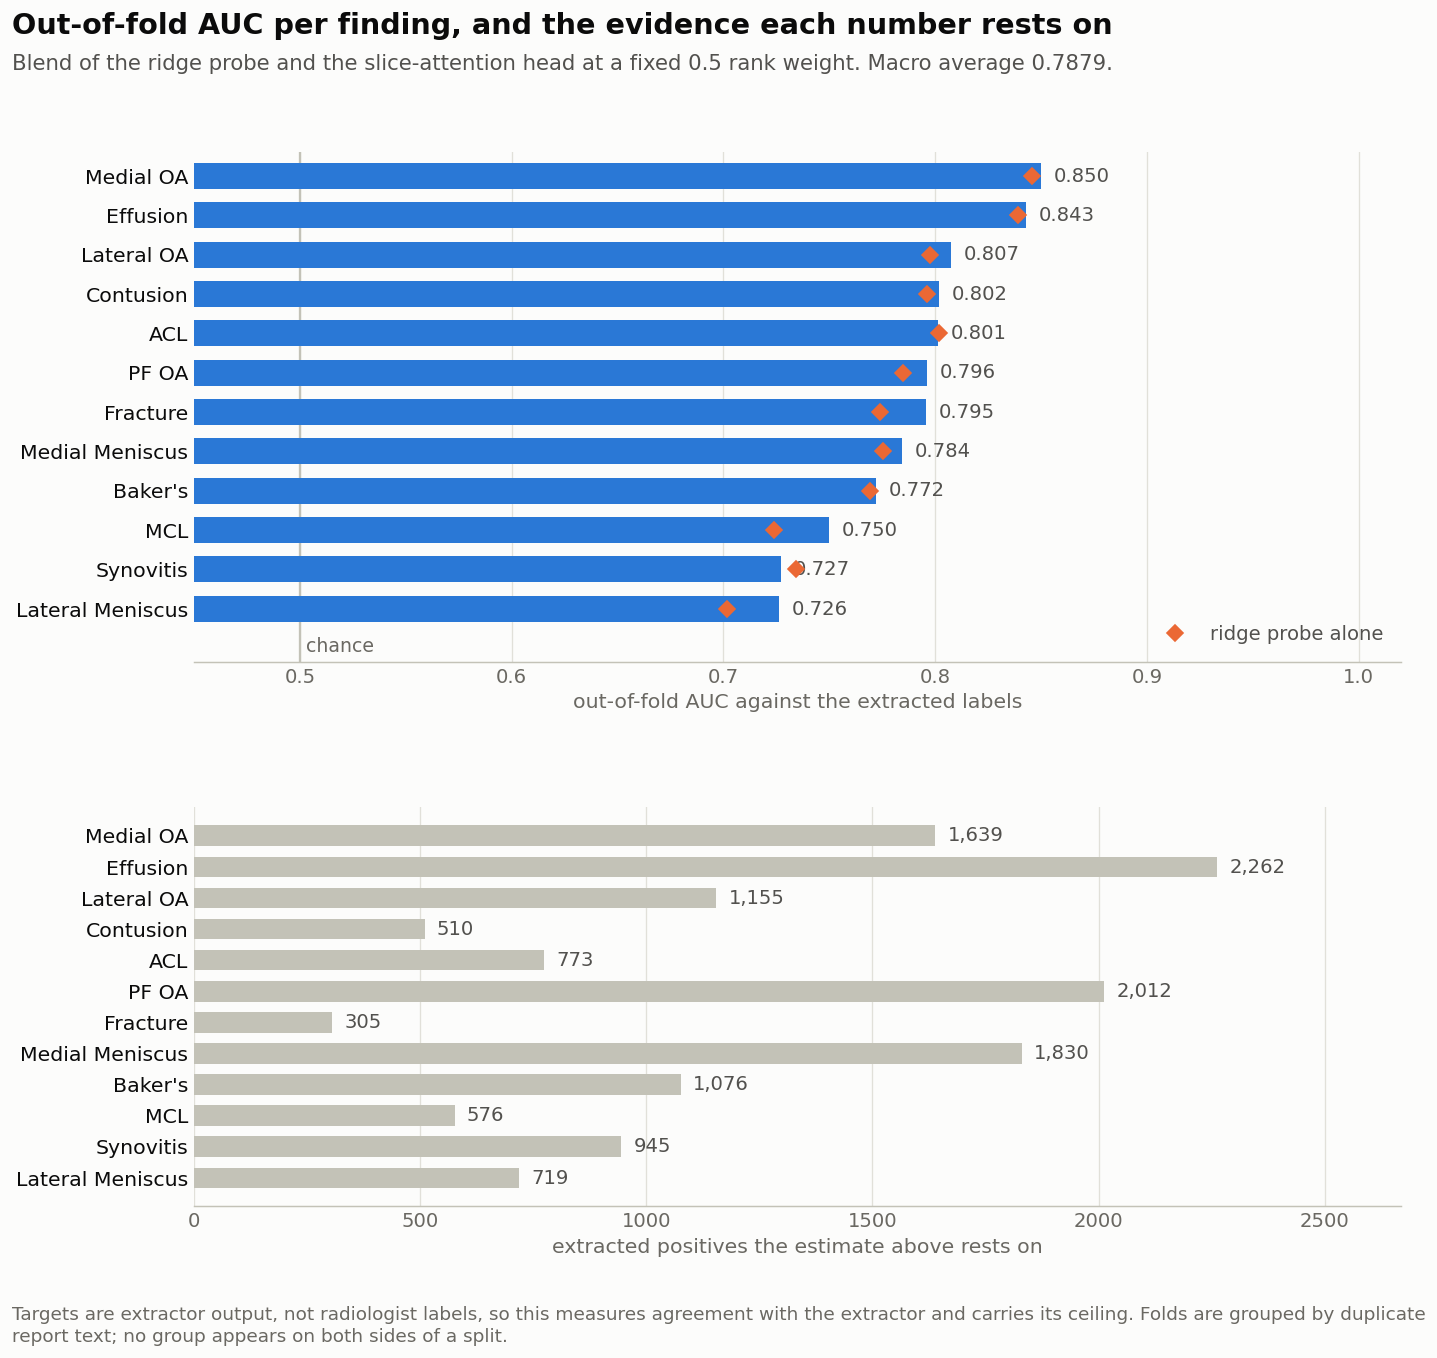

In [25]:
# Two panels, stacked, one label order shared so a finding can be tracked straight
# down the figure. Upper: where the model beats chance. Lower: how many positives
# each estimate rests on, because an AUC on 40 positives and an AUC on 2,000 are
# not the same measurement.
order = scores.sort_values("blend", ascending=True).reset_index(drop=True)
ypos = np.arange(len(order))

fig = plt.figure(figsize=(13.2, 11.6))
gs = fig.add_gridspec(2, 1, height_ratios=[1.15, 0.9], hspace=0.32)

ax0 = fig.add_subplot(gs[0, 0])
vals = order["blend"].values.astype(float)
ax0.barh(ypos, np.nan_to_num(vals, nan=0.5), height=0.66, color=PRIMARY, zorder=3)
label_bars(ax0, vals, ypos, fmt="{:.3f}", pad=0.006)
if HAVE_ATTN:
    ax0.plot(order["ridge"].values.astype(float), ypos, linestyle="none",
             marker="D", markersize=7, color=ACCENT, zorder=5, label="ridge probe alone")
    ax0.legend(loc="lower right", labelcolor=INK_2)
ax0.axvline(0.5, color=AXIS, linewidth=1.4, zorder=2)
# The chance rule is annotated below the lowest bar, not above the highest: at the
# top it lands on top of the leading bar and hides the number that matters most.
ax0.text(0.5, -0.95, " chance", ha="left", va="center", fontsize=11.5, color=MUTED)
ax0.set_ylim(-1.35, len(order) - 0.4)
ax0.set_yticks(ypos)
ax0.set_yticklabels(order["label"].tolist(), fontsize=12.5, color=INK)
lo = float(np.nanmin(np.append(vals, 0.5)))
ax0.set_xlim(min(0.45, lo - 0.03), 1.02)
ax0.set_xlabel("out-of-fold AUC against the extracted labels")
style(ax0, "x")
ax0.spines["left"].set_visible(False)

ax1 = fig.add_subplot(gs[1, 0])
pos = order["positives"].values.astype(float)
ax1.barh(ypos, pos, height=0.66, color=NEUTRAL, zorder=3)
label_bars(ax1, pos, ypos, fmt="{:,.0f}", pad=max(1.0, pos.max() * 0.012))
ax1.set_yticks(ypos)
ax1.set_yticklabels(order["label"].tolist(), fontsize=12.5, color=INK)
ax1.set_xlim(0, max(1.0, pos.max()) * 1.18)
ax1.set_xlabel("extracted positives the estimate above rests on")
style(ax1, "x")
ax1.spines["left"].set_visible(False)

finish(fig,
       "Out-of-fold AUC per finding, and the evidence each number rests on",
       detail="Blend of the ridge probe and the slice-attention head at a fixed "
              "0.5 rank weight. Macro average {:.4f}.".format(m_blend),
       caption="Targets are extractor output, not radiologist labels, so this "
               "measures agreement with the extractor and carries its ceiling. "
               "Folds are grouped by duplicate report text; no group appears on "
               "both sides of a split.")

<div style="background:#fcfcfb;border:1px solid #e1e0d9;border-left:6px solid #eb6834;border-radius:7px;padding:14px 18px;margin:26px 0 14px 0;"><h2 style="color:#0b0b0b;font-size:21px;margin:0;font-weight:700;letter-spacing:-.005em;"><span style="display:inline-block;min-width:26px;height:26px;line-height:26px;text-align:center;background:#256abf;color:#ffffff;border-radius:6px;font-size:14px;font-weight:700;margin-right:12px;vertical-align:middle;">9</span><span style="vertical-align:middle;">Submission</span></h2></div>

Column order comes from `sample_submission.csv` rather than being assumed. Row identity
comes from `test.csv`, so the file covers exactly the studies the grader expects in the
order it expects them. Row count, column set, finiteness and range are all asserted
before the file is written.

The degradation path matters more here than in a metadata notebook, because there are
many more ways for an imaging pipeline to come up empty. If the DINOv2 weights are not
mounted, if Torch is missing, if the DICOM directories are absent, or if the encode phase
runs out of budget, the notebook still writes a valid submission from the series manifest
alone. A weak submission is a score; an exception is not.

In [26]:
sub_cols = ["StudyInstanceUID"] + LABELS
if list(sample_sub.columns[:1]) == ["StudyInstanceUID"] and \
        set(LABELS).issubset(sample_sub.columns):
    sub_cols = list(sample_sub.columns)

pred = np.clip(np.asarray(blend_test, dtype=float), 0.0, 1.0)
if not np.isfinite(pred).all():
    print("non-finite predictions replaced by the per-label training prior")
    prior = Y.mean(axis=0)
    bad = ~np.isfinite(pred)
    pred[bad] = np.take(prior, np.where(bad)[1])

sub = pd.DataFrame(pred, columns=LABELS)
sub.insert(0, "StudyInstanceUID", test_ids)
sub = sub[sub_cols]

assert len(sub) == len(test), "row count does not match test.csv"
assert list(sub.columns) == sub_cols, "column order does not match the sample submission"
assert sub["StudyInstanceUID"].tolist() == test["StudyInstanceUID"].astype(str).tolist(), \
    "row identity or order drifted from test.csv"
assert np.isfinite(sub[LABELS].values).all(), "non-finite value in the submission"
assert (sub[LABELS].values >= 0).all() and (sub[LABELS].values <= 1).all(), \
    "probability out of range"

out_path = WORK / "submission.csv"
sub.to_csv(out_path, index=False)
print("wrote", out_path, "|", len(sub), "rows x", len(sub.columns), "columns")
print()
print(sub.head().to_string(index=False))
print()
print("per-label mean predicted probability")
print(sub[LABELS].mean().round(4).to_string())

# The train cache is 600 MB and slows every commit until it is actually wanted as a
# dataset. Delete it unless promotion is on.
if not SAVE_TRAIN_CACHE:
    removed = 0
    for p in cache_files("train").values():
        try:
            if p.is_file() and p.parent == WORK:
                p.unlink()
                removed += 1
        except Exception:
            pass
    if removed:
        print()
        print("removed {} train cache files from the output; set SAVE_TRAIN_CACHE=True"
              " to keep them for promotion to a dataset".format(removed))

wrote /kaggle/working/submission.csv | 3 rows x 13 columns

                                                StudyInstanceUID   ACL    MCL  Medial Meniscus  Lateral Meniscus  Medial OA  Lateral OA  PF OA  Effusion  Synovitis  Baker's  Contusion  Fracture
1.2.826.0.1.3680043.8.498.10047035057544427318018579121635276191 0.225 0.3625            0.725            0.3625      0.775       0.775  0.500     0.500      0.275    0.725        0.5       0.5
1.2.826.0.1.3680043.8.498.10062861783145312629332250977456991776 1.000 1.0000            0.000            1.0000      0.000       0.000  0.275     0.725      1.000    0.775        1.0       1.0
1.2.826.0.1.3680043.8.498.10067514707072572280263481548497591402 0.275 0.1375            0.775            0.1375      0.725       0.725  0.725     0.275      0.225    0.000        0.0       0.0

per-label mean predicted probability
ACL                 0.5
MCL                 0.5
Medial Meniscus     0.5
Lateral Meniscus    0.5
Medial OA           0.5
Latera

<div style="background:#fcfcfb;border:1px solid #e1e0d9;border-left:6px solid #eb6834;border-radius:7px;padding:14px 18px;margin:26px 0 14px 0;"><h2 style="color:#0b0b0b;font-size:21px;margin:0;font-weight:700;letter-spacing:-.005em;"><span style="display:inline-block;min-width:26px;height:26px;line-height:26px;text-align:center;background:#256abf;color:#ffffff;border-radius:6px;font-size:14px;font-weight:700;margin-right:12px;vertical-align:middle;">10</span><span style="vertical-align:middle;">What this is not</span></h2></div>

The backbone is frozen and was pretrained on natural images. DINOv2 features transfer
well to medical imaging but they are not a knee model, and nothing in this notebook
adapts them to MR. Fine-tuning is the obvious next lever and it is deliberately held back
until the label source is settled, because fine-tuning against noisy pseudo-labels
teaches the noise.

The training targets are extracted from reports. Whatever the extractor gets wrong is
baked into everything downstream, and the audit in section 3 puts the honest ceiling on
what a model trained on them can reach.

The resolution argument is arithmetic about sampling, and arithmetic is not a leaderboard
score. It says the frontier's input cannot represent the finding; it does not by itself
say that 336 px converts into AUC. That claim needs a submission, and this notebook has
not been scored at the time of writing.

The next three things worth doing, in the order they pay: replace the extracted labels
with the audited LLM extraction across all 4,349 unlabelled studies; build a
report-derived validation set large enough to rank two models; then split train and
inference so the nine-hour budget buys inference only. The recovered time should go into
a larger backbone or more slices, not into a larger input, because section 2 measured
that 448 px buys nothing over 336.

<div style="background:#fcfcfb;border:1px solid #e1e0d9;border-left:6px solid #eb6834;border-radius:7px;padding:14px 18px;margin:26px 0 14px 0;"><h2 style="color:#0b0b0b;font-size:21px;margin:0;font-weight:700;letter-spacing:-.005em;"><span style="vertical-align:middle;">How this notebook was made</span></h2></div>

This notebook was generated by an agentic system rather than typed by hand. The system is
Claude Code running a custom multi-agent LLM harness: one agent drafted the pipeline while
separate adversarial verifier agents tried to break it and sent each defect back to the
builder script instead of patching the notebook. The verifier agents are the part that
matters, because a notebook that has never been run is a draft.

The source of truth is a Python builder script, `notebooks/build_dino_notebook.py` in the
working repository, which emits this `.ipynb` through `nbformat`. Review happens on plain
Python, and the notebook is regenerated rather than edited. The rule label extractor is
not copied into this builder; it is imported from the baseline notebook's builder module,
so the two notebooks cannot drift apart. Publication uses `kaggle kernels push` and
submission uses the same CLI, as with the companion EDA and baseline notebooks.

The competition facts this notebook is built on were verified from the Kaggle API and
from the data itself on 2026-08-05, the day the competition opened: the 150 mm field of
view across four acquisition matrices, the identity of `Fluid_Sensitive` and
`Fat_Suppression` across all 24,371 series, the six-slot fill rates, the 49 report texts
shared by 183 studies, and the 1:1 patient-to-study mapping. The slot fill rates, the
duplicate-report blocks and the resolution arithmetic are all recomputed at run time in
the cells above rather than quoted from that check.

This notebook has no leaderboard score at the time of writing and claims none.

In [27]:
import platform

print("python      ", platform.python_version())
for mod in ["numpy", "pandas", "sklearn", "scipy", "matplotlib", "pydicom",
            "torch", "transformers", "cv2"]:
    try:
        print("{:12s}".format(mod), __import__(mod).__version__)
    except Exception as exc:
        print("{:12s} unavailable ({})".format(mod, type(exc).__name__))
print()
print("input root        ", ROOT)
print("seed              ", SEED)
print("input size        ", IMG_SIZE, "px ->",
      "{:.3f} mm/px, {:.2f} mm per token".format(
          FOV_MM / IMG_SIZE, FOV_MM * PATCH_PX / IMG_SIZE))
print("slots / budgets   ", ", ".join(
    "{}={}".format(n, k) for n, (_, _, k) in zip(SLOT_NAMES, SLOT_SPEC)))
print("label source      ", LABEL_SOURCE, "->", LABEL_PROVENANCE)
print("backbone          ", DINO_INFO)
print("cache tag         ", CACHE_TAG)
print("studies encoded   ", "train {} / test {}".format(
    int((mask_tr.sum(axis=(1, 2)) > 0).sum()), int((mask_te.sum(axis=(1, 2)) > 0).sum())))
print("slices decoded    ", STATS["slices_decoded"])
print("failures          ", ", ".join(
    "{} {}".format(k, v) for k, v in STATS.items() if k.endswith("fail")
    or k.endswith("missing") or k == "slots_empty"))

python       3.12.13
numpy        2.0.2
pandas       2.3.3
sklearn      1.6.1
scipy        1.16.3
matplotlib   3.10.0
pydicom      3.0.2
torch        2.10.0+cu128
transformers 5.0.0
cv2          4.13.0

input root         /kaggle/input/competitions/rsna-knee-abnormality-detection
seed               20260805
input size         336 px -> 0.446 mm/px, 6.25 mm per token
slots / budgets    Sagittal_Fluid=12, Sagittal_Structural=12, Coronal_Fluid=8, Coronal_Structural=6, Axial_Fluid=8
label source       auto -> llm
backbone           22,056,576 params, hidden 384, patch 14, configured at 518 px
cache tag          dinos336_slots12-12-8-6-8_1152_lat2
studies encoded    train 4407 / test 3
slices decoded     190849
failures           series_missing 0, header_fail 0, pixel_fail 0, slots_empty 1564
